<a href="https://colab.research.google.com/github/GUNAPILLCO/neural_profit/blob/main/stage_02_target_definition/stage_02_target_investigation_and_defintion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **stage_02_target_investigation**


## **Definición de targets a investigar (alineado con ML for Algorithmic Trading)**

El enfoque del libro establece que el objetivo del modelado no debe centrarse en predecir retornos o magnitudes exactas del precio, sino en construir **targets más estables, robustos y alineados con decisiones reales de trading**.

En este contexto, se define el siguiente conjunto de targets a investigar:

---

**T1. Dirección del movimiento (clasificación binaria)**

Se modela el problema como una clasificación simple:

* 1 → el precio sube en el horizonte H
* 0 → el precio no sube

Este enfoque reduce el ruido presente en los retornos y simplifica el problema a una decisión direccional.

---

**T2. Dirección con umbral (clasificación ternaria)**

Se introduce un umbral mínimo para filtrar movimientos poco relevantes:

* 1 → movimiento positivo significativo
* -1 → movimiento negativo significativo
* 0 → movimiento no significativo

Este target mejora la relación señal/ruido al ignorar variaciones pequeñas sin valor económico.

---

**T3. Outcome de trade (calidad de señal)**

El modelo no predice el mercado directamente, sino la calidad de una posible operación:

* 1 → trade exitoso
* 0 → trade no exitoso

Este enfoque permite evaluar si una señal tiene valor operativo, alineando el modelo con decisiones reales de trading.

---

**T4. Target basado en eventos (tipo barrera)**

Se define el target en función del resultado de un evento futuro:

* 1 → se alcanza take profit primero
* -1 → se alcanza stop loss primero
* 0 → no se alcanza ninguna condición dentro del horizonte

Este tipo de target está directamente alineado con la lógica de ejecución en trading.

---

**T5. Probabilidad de clase**

En todos los casos anteriores, el modelo puede formularse como un problema probabilístico:

* el modelo estima la probabilidad de cada clase
* las decisiones se toman en función de un umbral de confianza

Esto permite filtrar señales débiles y operar únicamente en escenarios de mayor certidumbre.



## **Conclusión**

El conjunto de targets definidos busca:

* reducir el ruido inherente a los retornos
* mejorar la estabilidad del problema de aprendizaje
* alinear el modelado con decisiones reales de trading

El orden de investigación propuesto es:

1. T1: Dirección binaria
2. T2: Dirección con umbral
3. T4: Target basado en eventos

Este orden permite avanzar desde formulaciones simples hacia estructuras más cercanas a la ejecución real.


## **Configuración del Entorno**


### 0.1. Acceso a Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')
drive_path = "/content/drive/MyDrive/neural_profit"

Mounted at /content/drive


### 0.2. Importación de librerías


In [2]:
import sys
import re
#Instalación de librería pandas_market_calendars
#!{sys.executable} -m pip install -q pandas_market_calendars
#print("Librería instalada: pandas_market_calendars")


from functools import reduce
# Utilidades generales
from datetime import datetime, timedelta
import os
import glob
import requests
import warnings
warnings.filterwarnings('ignore')

# Manejo y procesamiento de datos
#import ta
import pandas as pd
import numpy as np
from tabulate import tabulate
import matplotlib.pyplot as plt
# Calendario de mercados
#import pandas_market_calendars as mcal

#from ta.momentum import StochasticOscillator, ROCIndicator
#from ta.volatility import BollingerBands, AverageTrueRange

from scipy.stats import spearmanr
from __future__ import annotations  # permite type hints modernos (Python < 3.11)
import json                         # para guardar el summary como JSON
import os                           # para leer variables de entorno
from pathlib import Path            # manejo robusto de rutas
import pandas as pd

### 0.3. Definición de rutas

In [3]:
DRIVE_DIR =   Path(os.environ.get("DRIVE_DIR", "/content/drive/MyDrive/neural_profit/"))

In [4]:
IN_PARQUET = Path(os.environ.get("IN_PARQUET", "data/02_processed/mnq_intraday.parquet"))
OUT_SUMMARY = Path(os.environ.get("OUT_SUMMARY", "reports/state_02_target_investigation_summary.json"))

In [5]:
# PARA EL NOTEBOOK:
IN_PARQUET = DRIVE_DIR / IN_PARQUET
OUT_SUMMARY = DRIVE_DIR / OUT_SUMMARY

### 0.4. Función para ver información de dataset


In [6]:
from __future__ import annotations

from dataclasses import dataclass
from typing import Any, Dict, Optional, Tuple

import pandas as pd


def mnq_dataset_info(
    df: pd.DataFrame,
    *,
    name: str = "mnq_raw",
    tz_assume_if_naive: Optional[str] = None,  # ej: "UTC" o "America/New_York"
    day_def: str = "calendar",  # "calendar" (fecha calendario) o "trading" (días con datos)
) -> Dict[str, Any]:
    """
    Resume un dataset OHLCV con DatetimeIndex (ideal para mnq_raw).

    - Si el índice es tz-naive:
        - Si tz_assume_if_naive != None, lo localiza a esa tz.
        - Si no, reporta "tz-naive" (no se puede afirmar horario UTC).
    - Devuelve dict con métricas principales (y lo imprime bonito si se desea).
    """
    if not isinstance(df.index, pd.DatetimeIndex):
        raise TypeError(f"{name}: se requiere DatetimeIndex, recibido: {type(df.index)}")

    idx = df.index

    # --- timezone / UTC info ---
    tzinfo = idx.tz
    if tzinfo is None:
        tz_status = "tz-naive (sin zona horaria)"
        if tz_assume_if_naive:
            idx = idx.tz_localize(tz_assume_if_naive)
            tzinfo = idx.tz
            tz_status = f"localizado como {tzinfo}"
    else:
        tz_status = f"{tzinfo}"

    # --- rango temporal ---
    ts_min = idx.min()
    ts_max = idx.max()

    first_day = ts_min.date()
    last_day = ts_max.date()

    # --- días ---
    if day_def == "calendar":
        total_days = (pd.Timestamp(last_day) - pd.Timestamp(first_day)).days + 1
    elif day_def == "trading":
        total_days = idx.normalize().nunique()
    else:
        raise ValueError("day_def debe ser 'calendar' o 'trading'")

    # --- columnas ---
    columns = list(df.columns)

    # --- checks útiles ---
    n_rows = len(df)
    n_cols = df.shape[1]
    n_missing = int(df.isna().sum().sum())
    missing_by_col = df.isna().sum().to_dict()
    dup_index = int(idx.duplicated().sum())
    is_monotonic = bool(idx.is_monotonic_increasing)

    # Frecuencia estimada (puede fallar si hay huecos grandes)
    freq = pd.infer_freq(idx[: min(50000, len(idx))])  # muestra grande pero acotada

    # Cobertura por día (min/max de hora del día, en tz del índice)
    # (Útil para ver si es 24/7 o horario de sesión)
    tod = pd.Series(idx.time)
    # Convertimos time a minutos del día para resumen robusto
    tod_minutes = pd.Series([t.hour * 60 + t.minute for t in tod])
    typical_minute_min = int(tod_minutes.min())
    typical_minute_max = int(tod_minutes.max())

    # Rango promedio de filas por día (sólo días con datos)
    rows_per_day = df.groupby(idx.normalize()).size()
    rows_per_day_stats = {
        "days_with_data": int(rows_per_day.shape[0]),
        "rows_per_day_min": int(rows_per_day.min()),
        "rows_per_day_p50": float(rows_per_day.median()),
        "rows_per_day_max": int(rows_per_day.max()),
    }

    # Si hay tz, también mostramos rango en UTC
    if tzinfo is not None:
        ts_min_utc = ts_min.tz_convert("UTC")
        ts_max_utc = ts_max.tz_convert("UTC")
        utc_range = (str(ts_min_utc), str(ts_max_utc))
        utc_note = "El índice está tz-aware; el horario UTC es inequívoco."
    else:
        utc_range = None
        utc_note = "El índice es tz-naive; no se puede asegurar si está en UTC sin suposiciones."

    info: Dict[str, Any] = {
        "name": name,
        "shape": (n_rows, n_cols),
        "columns": columns,
        "index_type": type(df.index).__name__,
        "index_tz": tz_status,
        "utc_note": utc_note,
        "datetime_min": str(ts_min),
        "datetime_max": str(ts_max),
        "first_day": str(first_day),
        "last_day": str(last_day),
        "total_days": int(total_days),
        "day_definition": day_def,
        "utc_range_if_applicable": utc_range,
        "is_index_monotonic_increasing": is_monotonic,
        "duplicated_timestamps_in_index": dup_index,
        "inferred_freq_sample": freq,
        "missing_total_cells": n_missing,
        "missing_by_col": missing_by_col,
        "rows_per_day_stats": rows_per_day_stats,
        "time_of_day_minutes_range": {
            "min_minute_of_day": typical_minute_min,
            "max_minute_of_day": typical_minute_max,
        },
    }
    return info


def print_mnq_dataset_info(info: Dict[str, Any]) -> None:
    """Imprime el dict de mnq_dataset_info de forma ordenada."""
    print(f"Dataset: {info['name']}")
    print(f"Shape: {info['shape']}")
    print(f"Columns: {info['columns']}")
    print(f"Index: {info['index_type']} | TZ: {info['index_tz']}")
    print(f"Datetime min/max: {info['datetime_min']}  ->  {info['datetime_max']}")
    print(f"First/Last day: {info['first_day']}  ->  {info['last_day']}")
    print(f"Total days ({info['day_definition']}): {info['total_days']}")
    #print(f"Inferred freq (sample): {info['inferred_freq_sample']}")
    #print(f"Index monotonic increasing: {info['is_index_monotonic_increasing']}")
    #print(f"Duplicated timestamps in index: {info['duplicated_timestamps_in_index']}")
    #print(f"Missing total cells: {info['missing_total_cells']}")
    #print(f"Missing by col: {info['missing_by_col']}")
    #print(f"Rows/day stats: {info['rows_per_day_stats']}")
    print(f"Time-of-day range (minutes): {info['time_of_day_minutes_range']}")
    print(f"UTC note: {info['utc_note']}")
    if info["utc_range_if_applicable"] is not None:
        print(f"UTC range: {info['utc_range_if_applicable'][0]}  ->  {info['utc_range_if_applicable'][1]}")


### 0.5. Carga de dataset `intraday_mnq`


In [7]:
def load_mnq_parquet():
    os.path.exists(IN_PARQUET)
    print("Archivo encontrado en disco. Cargando dataset local...")
    mnq_parquet = pd.read_parquet(IN_PARQUET)
    return mnq_parquet

In [8]:
mnq_intraday = load_mnq_parquet()

Archivo encontrado en disco. Cargando dataset local...


In [9]:
info = mnq_dataset_info(mnq_intraday, name="mnq_intraday", tz_assume_if_naive=None, day_def="trading")
print_mnq_dataset_info(info)

Dataset: mnq_intraday
Shape: (1024062, 8)
Columns: ['date', 'open', 'high', 'low', 'close', 'volume', 'minute_of_day', 'regime_id']
Index: DatetimeIndex | TZ: America/New_York
Datetime min/max: 2020-01-02 04:30:00-05:00  ->  2026-04-17 16:00:00-04:00
First/Last day: 2020-01-02  ->  2026-04-17
Total days (trading): 1482
Time-of-day range (minutes): {'min_minute_of_day': 270, 'max_minute_of_day': 960}
UTC note: El índice está tz-aware; el horario UTC es inequívoco.
UTC range: 2020-01-02 09:30:00+00:00  ->  2026-04-17 20:00:00+00:00


### 0.6. Validación temporal de dataset `mnq_intraday`


Valida lo esencial para series temporales antes de construir targets: orden cronológico, duplicados, consistencia por día, monotonicidad de minute_of_day, gaps temporales y saltos sospechosos. Esto es importante porque en trading hay que validar cuidadosamente los timestamps para evitar look-ahead bias, y porque en series temporales el orden secuencial es parte central del problema.

In [10]:
import pandas as pd
import numpy as np

# ============================================================
# Validación temporal de mnq_intraday
# Ejecutar inmediatamente después de:
# mnq_intraday = load_mnq_parquet()
# ============================================================

def validate_mnq_intraday(df: pd.DataFrame, verbose: bool = True) -> dict:
    """
    Valida consistencia temporal básica para un dataset intradía.

    Chequeos:
    1) Índice datetime válido
    2) Orden cronológico global
    3) Duplicados de timestamp
    4) Consistencia de columna `date`
    5) Monotonía de `minute_of_day` dentro de cada día
    6) Duplicados de `minute_of_day` dentro de cada día
    7) Saltos temporales negativos o nulos
    8) Gaps intradía distintos de 1 minuto
    """

    result = {
        "ok": True,
        "checks": {},
        "summary": {},
        "artifacts": {}
    }

    df = df.copy()

    # ------------------------------------------------------------
    # 0) Verificaciones básicas de estructura
    # ------------------------------------------------------------
    required_cols = ["date", "minute_of_day", "open", "high", "low", "close", "volume"]
    missing_cols = [c for c in required_cols if c not in df.columns]
    if missing_cols:
        raise ValueError(f"Faltan columnas requeridas: {missing_cols}")

    if not isinstance(df.index, pd.DatetimeIndex):
        raise TypeError("El índice del DataFrame debe ser un pd.DatetimeIndex")

    if df.empty:
        raise ValueError("El DataFrame está vacío")

    # ------------------------------------------------------------
    # 1) Orden global del índice
    # ------------------------------------------------------------
    is_monotonic = df.index.is_monotonic_increasing
    has_unique_index = df.index.is_unique
    duplicated_index = df.index[df.index.duplicated()].unique()

    result["checks"]["index_is_monotonic_increasing"] = bool(is_monotonic)
    result["checks"]["index_is_unique"] = bool(has_unique_index)
    result["summary"]["n_duplicated_timestamps"] = int(len(duplicated_index))
    result["artifacts"]["duplicated_timestamps"] = duplicated_index

    # Si no está ordenado, mostramos evidencia pero no reordenamos silenciosamente
    if not is_monotonic:
        diffs_ns = pd.Series(df.index.view("i8")).diff()
        bad_order_pos = np.where(diffs_ns <= 0)[0]
        result["artifacts"]["bad_global_order_positions"] = bad_order_pos[:20]
        result["ok"] = False

    if not has_unique_index:
        result["ok"] = False

    # ------------------------------------------------------------
    # 2) Consistencia entre index.date y columna `date`
    # ------------------------------------------------------------
    # Normalizamos ambos a fecha sin hora
    index_dates = pd.Index(df.index.tz_localize(None).date if df.index.tz is not None else df.index.date)
    col_dates = pd.to_datetime(df["date"]).dt.date

    date_match = (index_dates == col_dates).all()
    result["checks"]["date_column_matches_index_date"] = bool(date_match)

    if not date_match:
        mismatch_mask = index_dates != col_dates
        mismatches = df.loc[mismatch_mask, ["date", "minute_of_day", "close"]].head(20)
        result["artifacts"]["date_mismatches_head"] = mismatches
        result["summary"]["n_date_mismatches"] = int(mismatch_mask.sum())
        result["ok"] = False
    else:
        result["summary"]["n_date_mismatches"] = 0

    # ------------------------------------------------------------
    # 3) Diferencias temporales globales
    # ------------------------------------------------------------
    # Trabajamos en segundos
    diffs_sec = pd.Series(df.index).diff().dt.total_seconds()

    n_non_positive_diffs = int((diffs_sec.iloc[1:] <= 0).sum())
    result["checks"]["all_global_time_diffs_positive"] = (n_non_positive_diffs == 0)
    result["summary"]["n_non_positive_global_diffs"] = n_non_positive_diffs

    if n_non_positive_diffs > 0:
        bad_diff_rows = df.iloc[np.where((diffs_sec <= 0).fillna(False))[0][:20]]
        result["artifacts"]["non_positive_global_diffs_head"] = bad_diff_rows
        result["ok"] = False

    # ------------------------------------------------------------
    # 4) Validación por día
    # ------------------------------------------------------------
    daily_stats = []
    bad_minute_order_days = []
    duplicate_minute_days = []
    intraday_gap_rows = []

    grouped = df.groupby("date", sort=False)

    for day, g in grouped:
        g = g.copy()

        # 4.1 orden del índice dentro del día
        idx_mono = g.index.is_monotonic_increasing

        # 4.2 minute_of_day creciente dentro del día
        mod_diff = g["minute_of_day"].diff()
        minute_order_ok = bool((mod_diff.iloc[1:] > 0).all())

        # 4.3 duplicados de minute_of_day dentro del día
        dup_mod = g["minute_of_day"].duplicated().sum()
        has_dup_mod = dup_mod > 0

        # 4.4 gaps intradía del índice
        idx_diff_sec = pd.Series(g.index).diff().dt.total_seconds()
        gap_mask = (~idx_diff_sec.isna()) & (idx_diff_sec != 60)

        n_intraday_gaps = int(gap_mask.sum())

        if not minute_order_ok:
            bad_minute_order_days.append(day)

        if has_dup_mod:
            duplicate_minute_days.append(day)

        if n_intraday_gaps > 0:
            gap_info = g.loc[gap_mask, ["date", "minute_of_day", "open", "high", "low", "close", "volume"]].copy()
            gap_info["gap_seconds"] = idx_diff_sec[gap_mask].values
            intraday_gap_rows.append(gap_info)

        daily_stats.append({
            "date": day,
            "n_rows": len(g),
            "index_monotonic": bool(idx_mono),
            "minute_of_day_monotonic": minute_order_ok,
            "n_duplicate_minute_of_day": int(dup_mod),
            "n_intraday_gaps_not_60s": n_intraday_gaps,
            "minute_min": int(g["minute_of_day"].min()),
            "minute_max": int(g["minute_of_day"].max()),
        })

        if not idx_mono or not minute_order_ok or has_dup_mod:
            result["ok"] = False

    daily_stats_df = pd.DataFrame(daily_stats)

    result["artifacts"]["daily_stats"] = daily_stats_df
    result["summary"]["n_days"] = int(daily_stats_df.shape[0])
    result["summary"]["days_with_bad_minute_order"] = int(len(bad_minute_order_days))
    result["summary"]["days_with_duplicate_minute_of_day"] = int(len(duplicate_minute_days))
    result["summary"]["days_with_intraday_gaps_not_60s"] = int((daily_stats_df["n_intraday_gaps_not_60s"] > 0).sum())

    result["checks"]["all_days_have_monotonic_minute_of_day"] = (len(bad_minute_order_days) == 0)
    result["checks"]["no_duplicate_minute_of_day_within_day"] = (len(duplicate_minute_days) == 0)
    result["checks"]["all_intraday_steps_are_60s_within_day"] = bool(
        (daily_stats_df["n_intraday_gaps_not_60s"] == 0).all()
    )

    result["artifacts"]["bad_minute_order_days"] = bad_minute_order_days
    result["artifacts"]["duplicate_minute_days"] = duplicate_minute_days

    if intraday_gap_rows:
        result["artifacts"]["intraday_gaps_head"] = pd.concat(intraday_gap_rows, axis=0).head(50)
    else:
        result["artifacts"]["intraday_gaps_head"] = pd.DataFrame()

    # ------------------------------------------------------------
    # 5) Resumen global
    # ------------------------------------------------------------
    result["summary"]["n_rows"] = int(len(df))
    result["summary"]["start"] = df.index.min()
    result["summary"]["end"] = df.index.max()

    # ------------------------------------------------------------
    # 6) Reporte por pantalla
    # ------------------------------------------------------------
    if verbose:
        print("=" * 70)
        print("VALIDACIÓN TEMPORAL DE mnq_intraday")
        print("=" * 70)
        print(f"Rows                     : {result['summary']['n_rows']}")
        print(f"Days                     : {result['summary']['n_days']}")
        print(f"Start                    : {result['summary']['start']}")
        print(f"End                      : {result['summary']['end']}")
        print("-" * 70)
        print(f"Index monotonic          : {result['checks']['index_is_monotonic_increasing']}")
        print(f"Index unique             : {result['checks']['index_is_unique']}")
        print(f"Date == index.date       : {result['checks']['date_column_matches_index_date']}")
        print(f"Global diffs > 0         : {result['checks']['all_global_time_diffs_positive']}")
        print(f"minute_of_day monotonic  : {result['checks']['all_days_have_monotonic_minute_of_day']}")
        print(f"No dup minute_of_day     : {result['checks']['no_duplicate_minute_of_day_within_day']}")
        print(f"Intraday steps = 60s     : {result['checks']['all_intraday_steps_are_60s_within_day']}")
        print("-" * 70)
        print(f"Duplicated timestamps    : {result['summary']['n_duplicated_timestamps']}")
        print(f"Date mismatches          : {result['summary']['n_date_mismatches']}")
        print(f"Non-positive global diffs: {result['summary']['n_non_positive_global_diffs']}")
        print(f"Bad minute order days    : {result['summary']['days_with_bad_minute_order']}")
        print(f"Dup minute_of_day days   : {result['summary']['days_with_duplicate_minute_of_day']}")
        print(f"Days with !=60s gaps     : {result['summary']['days_with_intraday_gaps_not_60s']}")
        print("-" * 70)
        print(f"DATASET OK               : {result['ok']}")
        print("=" * 70)

        if result["summary"]["n_duplicated_timestamps"] > 0:
            print("\nDuplicated timestamps (head):")
            print(pd.Index(result["artifacts"]["duplicated_timestamps"][:10]))

        if result["summary"]["n_date_mismatches"] > 0:
            print("\nDate mismatches (head):")
            print(result["artifacts"]["date_mismatches_head"])

        if result["summary"]["days_with_bad_minute_order"] > 0:
            print("\nDays with bad minute_of_day order (head):")
            print(result["artifacts"]["bad_minute_order_days"][:10])

        if result["summary"]["days_with_duplicate_minute_of_day"] > 0:
            print("\nDays with duplicate minute_of_day (head):")
            print(result["artifacts"]["duplicate_minute_days"][:10])

        if not result["artifacts"]["intraday_gaps_head"].empty:
            print("\nIntraday gaps != 60 seconds (head):")
            print(result["artifacts"]["intraday_gaps_head"])

    return result


# ============================================================
# Ejecución inmediata
# ============================================================
validation = validate_mnq_intraday(mnq_intraday, verbose=True)

# Si quiere abortar automáticamente cuando haya problemas críticos:
critical_checks = [
    "index_is_monotonic_increasing",
    "index_is_unique",
    "date_column_matches_index_date",
    "all_global_time_diffs_positive",
    "all_days_have_monotonic_minute_of_day",
    "no_duplicate_minute_of_day_within_day",
]

failed_critical = [k for k in critical_checks if not validation["checks"].get(k, False)]

if failed_critical:
    raise ValueError(
        "Validación temporal fallida. Checks críticos con error: "
        + ", ".join(failed_critical)
    )

VALIDACIÓN TEMPORAL DE mnq_intraday
Rows                     : 1024062
Days                     : 1482
Start                    : 2020-01-02 04:30:00-05:00
End                      : 2026-04-17 16:00:00-04:00
----------------------------------------------------------------------
Index monotonic          : True
Index unique             : True
Date == index.date       : True
Global diffs > 0         : True
minute_of_day monotonic  : True
No dup minute_of_day     : True
Intraday steps = 60s     : True
----------------------------------------------------------------------
Duplicated timestamps    : 0
Date mismatches          : 0
Non-positive global diffs: 0
Bad minute order days    : 0
Dup minute_of_day days   : 0
Days with !=60s gaps     : 0
----------------------------------------------------------------------
DATASET OK               : True


El dataset `mnq_intraday` se encuentra correctamente estructurado para la construcción de targets temporales.

En particular, se verificó que:

- el índice `datetime` está ordenado cronológicamente en forma ascendente,
- no existen timestamps duplicados,
- la columna `date` coincide con la fecha derivada del índice,
- no hay saltos temporales negativos ni diferencias no positivas,
- dentro de cada jornada, `minute_of_day` es estrictamente creciente,
- no existen duplicados de `minute_of_day` dentro de un mismo día,
- y todos los pasos intradía son consistentes con una frecuencia de 1 minuto.

Por lo tanto, el dataset queda validado como temporalmente consistente y apto para construir targets forward del tipo `delta_h` y `ret_h`, siempre que dichos horizontes se calculen respetando los límites de cada jornada y evitando cruces entre días.

# **Indicadores Técnicos**

In [11]:
!{sys.executable} -m pip install -q ta
print("Librería instalada: technical-analysis")

  Preparing metadata (setup.py) ... done
Librería instalada: technical-analysis


In [12]:
import ta
from ta.momentum import StochasticOscillator, ROCIndicator
from ta.volatility import BollingerBands, AverageTrueRange

Los indicadores técnicos calculados en cada jornada tienen como objetivo capturar dinámicas intradía relevantes del precio y el volumen, tales como momentum, sobrecompra/sobreventa, presión institucional o posibles reversiones. Cada uno aporta información complementaria sobre el comportamiento del mercado a corto plazo. En particular:

## **2.1. Indicadores técnicos individuales**

#### 1. **RSI (Relative Strength Index)**

Mide la fuerza relativa del precio en los últimos períodos (3, 5, 7, 14), oscilando entre 0 y 100.

  - Valores altos indican posibles condiciones de sobrecompra, mientras que valores bajos sugieren sobreventa.
  
  - Calculado sobre los precios de cierre intradía, el RSI es útil para identificar puntos de reversión potenciales en el corto plazo.

In [13]:
def calcular_rsi(df=mnq_intraday, target='close' ):
  rsi_columns = ['rsi_14', 'rsi_7', 'rsi_5', 'rsi_3']

  def aplicar_por_dia (grupo):
        grupo = grupo.copy()
        grupo['rsi_14'] = ta.momentum.RSIIndicator(grupo[target], window=14).rsi()
        grupo['rsi_7'] = ta.momentum.RSIIndicator(grupo[target], window=7).rsi()
        grupo['rsi_5'] = ta.momentum.RSIIndicator(grupo[target], window=5).rsi()
        grupo['rsi_3'] = ta.momentum.RSIIndicator(grupo[target], window=3).rsi()
        return grupo

  df = df.groupby('date', group_keys=False).apply(aplicar_por_dia)
  return df, rsi_columns

#### 2. **Momentum**

Mide la aceleración reciente del precio mediante la variación porcentual entre el precio actual y el de hace N minutos.

  - Un valor positivo indica una subida reciente, lo que podría sugerir una continuación alcista.

  - Un valor negativo señala presión bajista reciente, potencialmente anticipando una continuación a la baja.

In [14]:
def calcular_momentum(df=mnq_intraday, target='close' ):
  momentum_columns = ['mom_10', 'mom_5','mom_3']

  def aplicar_por_dia (grupo):
        grupo = grupo.copy()
        grupo['mom_10'] = grupo[target].pct_change(10)
        grupo['mom_5'] = grupo[target].pct_change(5)
        grupo['mom_3'] = grupo[target].pct_change(3)
        return grupo

  df = df.groupby('date', group_keys=False).apply(aplicar_por_dia)
  return df, momentum_columns

#### 3. **Relación de volumen actual vs. su promedio reciente**

Compara el volumen actual con su media móvil en distintas ventanas de tiempo: 15, 20 y 30 minutos.

  - Un valor mayor a 1 indica un volumen superior al promedio de la ventana correspondiente, lo que puede reflejar interés creciente o actividad institucional.

  - Un valor menor a 1 sugiere baja actividad o consolidación del precio.

Esta métrica permite detectar aumentos de volumen ("spikes") sin depender del volumen en crudo, y las diferentes ventanas permiten capturar variaciones en la dinámica de corto plazo con distinta sensibilidad.


In [15]:
def calcular_volumen_ratio(df=mnq_intraday, target='close'):
  volume_ratio_columns = ['volume_ratio_15', 'volume_ratio_20', 'volume_ratio_30', 'volume_ratio_60', 'volume_ratio_90']

  def aplicar_por_dia (grupo):
        grupo = grupo.copy()
        grupo['volume_ratio_15'] = grupo['volume'] / grupo['volume'].rolling(15).mean()
        grupo['volume_ratio_20'] = grupo['volume'] / grupo['volume'].rolling(20).mean()
        grupo['volume_ratio_30'] = grupo['volume'] / grupo['volume'].rolling(30).mean()
        grupo['volume_ratio_60'] = grupo['volume'] / grupo['volume'].rolling(60).mean()
        grupo['volume_ratio_90'] = grupo['volume'] / grupo['volume'].rolling(90).mean()
        return grupo

  df = df.groupby('date', group_keys=False).apply(aplicar_por_dia)

  return df, volume_ratio_columns

#### 4. **MACD diferencial (señal de cruce)**

Representa la diferencia entre la línea MACD y su línea de señal (una media exponencial de sí misma).

  - Un valor positivo y creciente indica momentum alcista.

  - Un valor negativo sugiere presión bajista.
  
Es ampliamente utilizado para detectar giros de tendencia y cambios en la dinámica del mercado.


In [16]:
def calcular_macd(df=mnq_intraday, target='close'):
    macd_columns = ['macd']

    def aplicar_por_dia(grupo):
        grupo = grupo.copy()
        grupo['macd'] = ta.trend.MACD(grupo[target]).macd_diff()
        return grupo

    df = df.groupby('date', group_keys=False).apply(aplicar_por_dia)

    return df, macd_columns

#### 5. **Distancia del precio actual a su EMA (15, 20 y 30 minutos)**

Mide el desvío porcentual del precio respecto a su media exponencial en diferentes ventanas, y actúa como indicador de sobreextensión o retorno a la media.

  - Si el precio está muy por encima de la EMA, puede anticipar una reversión bajista o una posible aceleración alcista.

  - Si está por debajo, podría indicar agotamiento o presión vendedora.<br>

Esta métrica se expresa como un porcentaje relativo, lo que facilita la comparación entre distintas ventanas temporales y condiciones de mercado.

Usar varias ventanas (15, 20 y 30 minutos) permite capturar diferentes horizontes de reacción del precio frente a su media móvil.


In [17]:
def calcular_ema(df=mnq_intraday, target='close'):
    ema_columns = ['ema_15', 'ema_20', 'ema_30',  'ema_60']

    def aplicar_por_dia(grupo):
        grupo = grupo.copy()
        grupo['ema_15'] = grupo[target] / grupo[target].ewm(span=15).mean() - 1
        grupo['ema_20'] = grupo[target] / grupo[target].ewm(span=20).mean() - 1
        grupo['ema_30'] = grupo[target] / grupo[target].ewm(span=30).mean() - 1
        grupo['ema_60'] = grupo[target] / grupo[target].ewm(span=60).mean() - 1
        return grupo

    df = df.groupby('date', group_keys=False).apply(aplicar_por_dia)

    return df, ema_columns

#### 6. **%K Estocástico**

Mide la posición relativa del precio actual dentro del rango alto-bajo de los últimos n periodos (generalmente 14).

  - Se utiliza para identificar condiciones extremas de sobrecompra o sobreventa.

  - Un valor cercano a 100 indica que el precio está cerca del máximo reciente (potencial sobrecompra), mientras que un valor cercano a 0 indica proximidad al mínimo reciente (posible sobreventa).

Es útil para detectar momentos en los que el precio puede estar excesivamente extendido y susceptible a una reversión.


In [18]:
def calcular_stochastic(df=mnq_intraday, target='close'):
    stoch_columns = ['stoch_k_14', 'stoch_k_20', 'stoch_k_30']

    def aplicar_por_dia(grupo):
        grupo = grupo.copy()

        stoch_14 = StochasticOscillator(
            high=grupo['high'], low=grupo['low'], close=grupo[target], window=14, smooth_window=3
        )
        grupo['stoch_k_14'] = stoch_14.stoch()

        stoch_20 = StochasticOscillator(
            high=grupo['high'], low=grupo['low'], close=grupo[target], window=20, smooth_window=3
        )
        grupo['stoch_k_20'] = stoch_20.stoch()

        stoch_30 = StochasticOscillator(
            high=grupo['high'], low=grupo['low'], close=grupo[target], window=30, smooth_window=3
        )
        grupo['stoch_k_30'] = stoch_30.stoch()

        return grupo

    df = df.groupby('date', group_keys=False).apply(aplicar_por_dia)

    return df, stoch_columns


#### 7.**%B de Bollinger (Bollinger Band Percent)**

Indica la posición del precio actual en relación con las bandas de Bollinger, que están construidas alrededor de una media móvil usando desviaciones estándar.

  - Un valor de %B > 1 sugiere que el precio está por encima de la banda superior, lo que podría implicar exceso de optimismo o momentum fuerte.

  - Un valor < 0 indica que está por debajo de la banda inferior, posible señal de pánico o sobreventa extrema.

Este indicador es eficaz para identificar zonas de congestión, breakout o reversiones basadas en la volatilidad reciente.


In [19]:
from ta.volatility import BollingerBands

def calcular_bollinger(df=mnq_intraday, target='close'):
    '''bollinger_columns = [
        'bb_percent_15_15', 'bb_percent_20_15', 'bb_percent_30_15',
        'bb_percent_15_20', 'bb_percent_20_20', 'bb_percent_30_20',
        'bb_percent_15_25', 'bb_percent_20_25', 'bb_percent_30_25',
    ]'''

    bollinger_columns = [
        'bb_15_15', 'bb_20_15', 'bb_30_15', 'bb_60_15',
        'bb_15_20', 'bb_20_20', 'bb_30_20', 'bb_60_20',
        'bb_15_25', 'bb_20_25', 'bb_30_25', 'bb_60_25',
    ]

    def aplicar_por_dia(grupo):
        grupo = grupo.copy()

        # std: 1.5
        grupo['bb_15_15'] = BollingerBands(grupo[target], window=15, window_dev=1.5).bollinger_pband()
        grupo['bb_20_15'] = BollingerBands(grupo[target], window=20, window_dev=1.5).bollinger_pband()
        grupo['bb_30_15'] = BollingerBands(grupo[target], window=30, window_dev=1.5).bollinger_pband()
        grupo['bb_60_15'] = BollingerBands(grupo[target], window=60, window_dev=1.5).bollinger_pband()

        # std: 2
        grupo['bb_15_20'] = BollingerBands(grupo[target], window=15, window_dev=2).bollinger_pband()
        grupo['bb_20_20'] = BollingerBands(grupo[target], window=20, window_dev=2).bollinger_pband()
        grupo['bb_30_20'] = BollingerBands(grupo[target], window=30, window_dev=2).bollinger_pband()
        grupo['bb_60_20'] = BollingerBands(grupo[target], window=60, window_dev=2).bollinger_pband()

        # std: 2.5
        grupo['bb_15_25'] = BollingerBands(grupo[target], window=15, window_dev=2.5).bollinger_pband()
        grupo['bb_20_25'] = BollingerBands(grupo[target], window=20, window_dev=2.5).bollinger_pband()
        grupo['bb_30_25'] = BollingerBands(grupo[target], window=30, window_dev=2.5).bollinger_pband()
        grupo['bb_60_25'] = BollingerBands(grupo[target], window=60, window_dev=2.5).bollinger_pband()



        return grupo

    df = df.groupby('date', group_keys=False).apply(aplicar_por_dia)

    return df, bollinger_columns


In [20]:
def calcular_bollinger_resume(df=mnq_intraday, target='close'):

    bollinger_columns = [
        'bb_15', 'bb_20', 'bb_30', 'bb_60',
    ]

    def aplicar_por_dia(grupo):
        grupo = grupo.copy()

        # std: 2
        grupo['bb_15'] = BollingerBands(grupo[target], window=15, window_dev=2).bollinger_pband()
        grupo['bb_20'] = BollingerBands(grupo[target], window=20, window_dev=2).bollinger_pband()
        grupo['bb_30'] = BollingerBands(grupo[target], window=30, window_dev=2).bollinger_pband()
        grupo['bb_60'] = BollingerBands(grupo[target], window=60, window_dev=2).bollinger_pband()
        return grupo

    df = df.groupby('date', group_keys=False).apply(aplicar_por_dia)

    return df, bollinger_columns

#### 8. **ATR normalizado (Average True Range / precio)**

Representa la volatilidad absoluta reciente ajustada al nivel del precio.

  - El ATR mide el rango promedio de oscilación de un activo en los últimos n periodos, capturando tanto movimientos bruscos como gaps.

  - Al normalizarlo dividiéndolo por el precio, se obtiene una medida relativa, comparable entre distintos niveles de mercado.

Este indicador es útil para detectar momentos de alta o baja volatilidad intradía, que pueden influir en la confiabilidad de otras señales técnicas.


In [21]:
def calcular_atr(df=mnq_intraday, target='close', windows=[5, 10, 14, 20, 30]):
    atr_columns = []

    def aplicar_por_dia(grupo):
        grupo = grupo.copy()
        for w in windows:
            col_name = f'atr_norm_{w}'
            atr = AverageTrueRange(high=grupo['high'], low=grupo['low'], close=grupo[target], window=w)
            grupo[col_name] = atr.average_true_range() / grupo[target]
            atr_columns.append(col_name)
        return grupo

    df = df.groupby('date', group_keys=False).apply(aplicar_por_dia)

    return df, list(set(atr_columns))

####  9. **ROC (Rate of Change)**

Calcula la tasa de cambio porcentual del precio con respecto a su valor n minutos atrás.

- Es un indicador de momentum que capta aceleraciones o desaceleraciones recientes del precio.

- Valores positivos indican presión alcista; negativos, presión bajista.

A diferencia del momentum tradicional, el ROC expresa el cambio de forma normalizada y en porcentaje, lo que facilita su interpretación comparativa entre distintos activos o marcos temporales.


In [22]:
def calcular_roc(df=mnq_intraday, target='close'):
    roc_columns = ['roc_5', 'roc_10', 'roc_20','roc_30','roc_60']

    def aplicar_por_dia(grupo):
        grupo = grupo.copy()
        grupo['roc_5'] = ROCIndicator(close=grupo[target], window=5).roc()
        grupo['roc_10'] = ROCIndicator(close=grupo[target], window=10).roc()
        grupo['roc_20'] = ROCIndicator(close=grupo[target], window=20).roc()
        grupo['roc_30'] = ROCIndicator(close=grupo[target], window=30).roc()
        grupo['roc_60'] = ROCIndicator(close=grupo[target], window=60).roc()

        return grupo

    df = df.groupby('date', group_keys=False).apply(aplicar_por_dia)

    return df, roc_columns

## **2.2. Cálculo de indicadores técnicos**

Calculamos los indicadores técnicos

In [23]:
mnq_intraday

,date,open,high,low,close,volume,minute_of_day,regime_id
datetime,,,,,,,,
2020-01-02 04:30:00-05:00,2020-01-02,8813.25,8813.25,8812.50,8813.25,13,270,0
2020-01-02 04:31:00-05:00,2020-01-02,8812.50,8812.50,8811.00,8812.50,121,271,0
2020-01-02 04:32:00-05:00,2020-01-02,8812.50,8813.25,8811.75,8811.75,53,272,0
2020-01-02 04:33:00-05:00,2020-01-02,8812.00,8812.25,8810.50,8810.50,37,273,0
2020-01-02 04:34:00-05:00,2020-01-02,8810.75,8812.25,8810.50,8812.00,36,274,0
...,...,...,...,...,...,...,...,...
2026-04-17 15:56:00-04:00,2026-04-17,26815.50,26829.00,26814.25,26820.00,4185,956,4
2026-04-17 15:57:00-04:00,2026-04-17,26819.75,26830.00,26815.00,26817.50,2536,957,4
2026-04-17 15:58:00-04:00,2026-04-17,26818.00,26824.50,26809.00,26823.75,2518,958,4


In [24]:
import os
import glob
import numpy as np
import pandas as pd


def load_or_build_mnq_intraday_with_indicators(
    mnq_intraday: pd.DataFrame,
    *,
    processed_dir: str = "/content/drive/MyDrive/neural_profit/data/02_processed",
    parquet_name: str = "mnq_intraday_tech_indicators.parquet",
    date_col: str = "date",
    minute_col: str = "minute_of_day",
    regime_col: str = "regime_id",
    valid_regime_ids: tuple[int, ...] = (0, 1, 2, 3, 4),
    dropna_after_indicators: bool = True,
    print_report: bool = True,
):
    """
    Carga un parquet existente con indicadores o los calcula desde mnq_intraday.

    Además:
    - elimina NaNs al final del cálculo
    - reconstruye indicator_columns
    - valida orden cronológico
    - valida NaNs remanentes en indicadores
    - valida consistencia básica por día para indicadores rolling
    - imprime un reporte final del dataset
    """

    processed_dir = os.path.abspath(processed_dir)
    parquet_path = os.path.join(processed_dir, parquet_name)
    os.makedirs(processed_dir, exist_ok=True)

    # ============================================================
    # 1) Cargar o calcular
    # ============================================================
    loaded_from = None

    if os.path.exists(parquet_path):
        df = pd.read_parquet(parquet_path)
        loaded_from = parquet_path
        if print_report:
            print(f"[OK] Cargado: {parquet_path}")

    else:
        candidates = sorted(glob.glob(os.path.join(processed_dir, "*with_indicators*.parquet")))
        if candidates:
            df = pd.read_parquet(candidates[-1])
            loaded_from = candidates[-1]
            if print_report:
                print(f"[OK] Cargado (fallback): {candidates[-1]}")
        else:
            df = mnq_intraday.copy()
            loaded_from = "computed"

            if print_report:
                print("[OK] Calculando indicadores técnicos...")

            df, rsi_columns = calcular_rsi(df)
            df, momentum_columns = calcular_momentum(df)
            df, volume_ratio_columns = calcular_volumen_ratio(df)
            df, macd_columns = calcular_macd(df)
            df, ema_columns = calcular_ema(df)
            df, stoch_columns = calcular_stochastic(df)
            df, bollinger_columns = calcular_bollinger(df)
            df, atr_columns = calcular_atr(df)
            df, roc_columns = calcular_roc(df)

            indicator_columns = (
                rsi_columns
                + momentum_columns
                + volume_ratio_columns
                + macd_columns
                + ema_columns
                + stoch_columns
                + bollinger_columns
                + atr_columns
                + roc_columns
            )

            indicator_columns = list(dict.fromkeys(indicator_columns))

            # ============================================================
            # 2) Eliminar NaNs SOLO al final
            # ============================================================
            if dropna_after_indicators:
                n_before_dropna = len(df)
                df = df.dropna(subset=indicator_columns).copy()
                n_after_dropna = len(df)
            else:
                n_before_dropna = len(df)
                n_after_dropna = len(df)

            df.to_parquet(parquet_path, index=True)
            if print_report:
                print(f"[OK] Calculado y guardado: {parquet_path}")

    # ============================================================
    # 3) Normalización temporal
    # ============================================================
    if not isinstance(df.index, pd.DatetimeIndex):
        df.index = pd.to_datetime(df.index)

    if date_col in df.columns:
        df[date_col] = pd.to_datetime(df[date_col])

    df = df.sort_index().copy()

    # ============================================================
    # 4) Reconstruir indicator_columns desde el dataset final
    # ============================================================
    columns_to_remove = {
        date_col,
        minute_col,
        regime_col,
        "open", "high", "low", "close", "volume",
    }

    indicator_columns = [col for col in df.columns if col not in columns_to_remove]

    # ============================================================
    # 5) Validaciones
    # ============================================================
    # 5.1 Orden cronológico
    is_sorted = df.index.is_monotonic_increasing

    # 5.2 NaNs en indicadores
    nan_counts_indicators = df[indicator_columns].isna().sum().sort_values(ascending=False)
    indicators_with_nan = nan_counts_indicators[nan_counts_indicators > 0]

    # 5.3 Filas por regime_id
    if regime_col in df.columns:
        regime_summary = (
            df[regime_col]
            .value_counts(dropna=False)
            .sort_index()
            .rename_axis(regime_col)
            .reset_index(name="n_rows")
        )
    else:
        regime_summary = pd.DataFrame(columns=[regime_col, "n_rows"])

    # 5.4 Validación básica: regime_id válido por fila
    if regime_col in df.columns:
        invalid_regime_rows = int(~df[regime_col].isin(valid_regime_ids).sum())  # no usar
        invalid_regime_rows = int((~df[regime_col].isin(valid_regime_ids)).sum())
    else:
        invalid_regime_rows = np.nan

    # 5.5 Validación básica: no cruce de días en indicadores
    day_minute_summary = (
        df.groupby(date_col)[minute_col]
        .agg(first_minute="min", last_minute="max", n_rows="count")
        .reset_index()
        if date_col in df.columns and minute_col in df.columns
        else pd.DataFrame()
    )

    suspicious_cross_day_days = pd.DataFrame()
    if not day_minute_summary.empty:
        suspicious_cross_day_days = day_minute_summary[
            day_minute_summary["first_minute"] < 60
        ].copy()

    # 5.6 Duplicados temporales
    duplicated_timestamps = int(df.index.duplicated().sum())

    # ============================================================
    # 6) Reporte
    # ============================================================
    report = {
        "loaded_from": loaded_from,
        "n_rows_final": int(len(df)),
        "n_cols_final": int(df.shape[1]),
        "n_indicator_columns": int(len(indicator_columns)),
        "is_sorted_chronologically": bool(is_sorted),
        "duplicated_timestamps": duplicated_timestamps,
        "n_indicators_with_nan": int(len(indicators_with_nan)),
        "invalid_regime_rows": invalid_regime_rows,
        "n_suspicious_cross_day_days": int(len(suspicious_cross_day_days)),
    }

    if loaded_from == "computed":
        report["n_rows_before_dropna"] = int(n_before_dropna)
        report["n_rows_after_dropna"] = int(n_after_dropna)
        report["rows_removed_by_dropna"] = int(n_before_dropna - n_after_dropna)

    if print_report:
        print("=" * 100)
        print("DATASET FINAL CON INDICADORES TÉCNICOS")
        print("=" * 100)
        print(f"Origen: {report['loaded_from']}")
        print(f"Filas finales: {report['n_rows_final']}")
        print(f"Columnas finales: {report['n_cols_final']}")
        print(f"Cantidad de indicadores técnicos: {report['n_indicator_columns']}")
        if "n_rows_before_dropna" in report:
            print(f"Filas antes de dropna final: {report['n_rows_before_dropna']}")
            print(f"Filas después de dropna final: {report['n_rows_after_dropna']}")
            print(f"Filas eliminadas por NaNs: {report['rows_removed_by_dropna']}")
        print(f"Orden cronológico correcto: {report['is_sorted_chronologically']}")
        print(f"Timestamps duplicados: {report['duplicated_timestamps']}")
        print(f"Indicadores con NaNs remanentes: {report['n_indicators_with_nan']}")
        print(f"Filas con regime_id inválido: {report['invalid_regime_rows']}")
        print(f"Días sospechosos de cruce entre días: {report['n_suspicious_cross_day_days']}")
        print()

        print("-" * 100)
        print("FILAS POR REGIME_ID")
        print("-" * 100)
        print(regime_summary.to_string(index=False))
        print()

        print("-" * 100)
        print("LISTADO TOTAL DE INDICADORES TÉCNICOS")
        print("-" * 100)
        print(indicator_columns)
        print()

        if len(indicators_with_nan) == 0:
            print("[OK] No quedan NaNs en los indicadores técnicos.")
        else:
            print("[WARN] Quedan NaNs en algunos indicadores:")
            print(indicators_with_nan.to_string())
            print()

        if is_sorted:
            print("[OK] El dataset final está en orden cronológico.")
        else:
            print("[WARN] El dataset final NO está en orden cronológico.")

        if duplicated_timestamps == 0:
            print("[OK] No hay timestamps duplicados.")
        else:
            print(f"[WARN] Hay {duplicated_timestamps} timestamps duplicados.")

        if invalid_regime_rows == 0:
            print("[OK] Todos los valores de regime_id son válidos.")
        else:
            print(f"[WARN] Hay {invalid_regime_rows} filas con regime_id inválido.")

        if len(suspicious_cross_day_days) == 0:
            print("[OK] No se detectaron señales evidentes de cruce entre días en indicadores.")
        else:
            print("[WARN] Hay días potencialmente sospechosos respecto al arranque de indicadores:")
            print(suspicious_cross_day_days.head(20).to_string(index=False))

    return df, indicator_columns, {
        "report": report,
        "regime_summary": regime_summary,
        "indicator_columns": indicator_columns,
        "nan_counts_indicators": indicators_with_nan,
        "suspicious_cross_day_days": suspicious_cross_day_days,
        "day_minute_summary": day_minute_summary,
    }

In [25]:
mnq_intraday_tech_indicators, indicator_columns, indicators_report = load_or_build_mnq_intraday_with_indicators(
    mnq_intraday,
    print_report=True,
)

[OK] Cargado: /content/drive/MyDrive/neural_profit/data/02_processed/mnq_intraday_tech_indicators.parquet
DATASET FINAL CON INDICADORES TÉCNICOS
Origen: /content/drive/MyDrive/neural_profit/data/02_processed/mnq_intraday_tech_indicators.parquet
Filas finales: 892164
Columnas finales: 50
Cantidad de indicadores técnicos: 42
Orden cronológico correcto: True
Timestamps duplicados: 0
Indicadores con NaNs remanentes: 0
Filas con regime_id inválido: 0
Días sospechosos de cruce entre días: 0

----------------------------------------------------------------------------------------------------
FILAS POR REGIME_ID
----------------------------------------------------------------------------------------------------
 regime_id  n_rows
         0  225264
         1   88920
         2   88920
         3  444600
         4   44460

----------------------------------------------------------------------------------------------------
LISTADO TOTAL DE INDICADORES TÉCNICOS
---------------------------------

# **T1: Dirección binaria**


Como primer target de investigación, comenzaremos con la formulación más simple de clasificación: **predecir la dirección futura del precio**. Esta elección está alineada con el enfoque del libro, que plantea que en trading los modelos supervisados pueden formularse tanto como problemas de regresión como de clasificación, y que las tareas de clasificación incluyen explícitamente los **pronósticos direccionales del precio**.

Empezar por T1 tiene una justificación metodológica clara. Antes de introducir umbrales, reglas de trading o targets dependientes de trayectoria, conviene responder una pregunta más básica: **¿existe alguna señal direccional en los features?**. Desde la perspectiva del proceso de machine learning, primero se debe definir con claridad el problema, el target y el criterio de éxito, y luego evaluar si el modelo logra generalizar fuera de muestra.

Además, este target funciona como un **baseline limpio y de baja complejidad**. El libro destaca que los modelos lineales y de clasificación suelen ser un punto de partida útil porque son robustos, interpretables y permiten construir una primera referencia antes de pasar a formulaciones más complejas. También señala que, en clasificación, el modelo no solo puede asignar una clase, sino también estimar probabilidades para cada categoría, lo cual más adelante será útil para filtrar señales por nivel de confianza.

En nuestro caso, T1 buscará responder si, dada una ventana de información intradía del MNQ, es posible anticipar si el movimiento futuro será **positivo o no positivo** en un horizonte determinado. Si este target no muestra señal fuera de muestra, entonces targets más complejos difícilmente aportarán valor. Si, en cambio, aquí aparece una señal incipiente, tendrá sentido avanzar luego hacia targets con umbral y targets basados en eventos.

## **Construcción de T1**

In [26]:
import numpy as np
import pandas as pd


def create_t1_binary_direction_target(
    df: pd.DataFrame,
    *,
    close_col: str = "close",
    date_col: str = "date",
    minute_col: str = "minute_of_day",
    horizons: tuple[int, ...] = (60, 90),
    drop_na_targets: bool = False,
    validate_order: bool = True,
    verbose: bool = True,
) -> pd.DataFrame:
    """
    Crea targets T1 de clasificación binaria para dirección futura.

    Definición:
        y_t1_h = 1 si close_{t+h} > close_t
                 0 en caso contrario

    Características:
    - Calcula el target por día de trading
    - Evita mezclar información entre jornadas
    - Respeta el orden temporal intradía
    - Permite generar múltiples horizontes

    Parámetros
    ----------
    df : pd.DataFrame
        Dataset intradía.
    close_col : str
        Nombre de la columna de precio de cierre.
    date_col : str
        Nombre de la columna de fecha de sesión.
    minute_col : str
        Nombre de la columna de orden intradía.
    horizons : tuple[int, ...]
        Horizontes futuros en minutos.
    drop_na_targets : bool
        Si True, elimina filas donde no pueda definirse el target.
    validate_order : bool
        Si True, verifica orden temporal por día.
    verbose : bool
        Si True, imprime resumen.

    Retorna
    -------
    pd.DataFrame
        Copia del dataframe con columnas nuevas:
        - close_fwd_{h}
        - delta_{h}
        - t1_dir_bin_{h}
    """
    required_cols = [close_col, date_col, minute_col]
    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        raise ValueError(f"Faltan columnas requeridas: {missing}")

    out = df.copy()

    if validate_order:
        sorted_view = out.sort_values([date_col, minute_col]).index
        if not out.index.equals(sorted_view):
            raise ValueError(
                f"El DataFrame no está ordenado por [{date_col}, {minute_col}]. "
                "Ordénalo antes de crear los targets."
            )

        dupes = out.duplicated(subset=[date_col, minute_col]).sum()
        if dupes > 0:
            raise ValueError(
                f"Se encontraron {dupes} combinaciones duplicadas de "
                f"[{date_col}, {minute_col}]."
            )

    grouped_close = out.groupby(date_col, sort=False)[close_col]

    for h in horizons:
        fwd_col = f"close_fwd_{h}"
        delta_col = f"delta_{h}"
        target_col = f"t1_dir_bin_{h}"

        out[fwd_col] = grouped_close.shift(-h)
        out[delta_col] = out[fwd_col] - out[close_col]

        out[target_col] = np.where(
            out[fwd_col].notna(),
            (out[delta_col] > 0).astype("int8"),
            np.nan
        )

    if drop_na_targets:
        target_cols = [f"t1_dir_bin_{h}" for h in horizons]
        out = out.dropna(subset=target_cols).copy()

    if verbose:
        print("=" * 80)
        print("RESUMEN | T1 Binary Direction Target")
        print("=" * 80)
        print(f"Filas de entrada : {len(df):,}")
        print(f"Filas de salida  : {len(out):,}")
        print(f"Horizontes       : {horizons}")

        for h in horizons:
            target_col = f"t1_dir_bin_{h}"
            valid = out[target_col].notna().sum()
            pos = (out[target_col] == 1).sum()
            neg = (out[target_col] == 0).sum()

            if valid > 0:
                pos_rate = pos / valid
                neg_rate = neg / valid
            else:
                pos_rate = np.nan
                neg_rate = np.nan

            print("-" * 80)
            print(f"Target           : {target_col}")
            print(f"Observaciones    : {valid:,}")
            print(f"Clase 1 (sube)   : {pos:,} ({pos_rate:.2%})")
            print(f"Clase 0 (no sube): {neg:,} ({neg_rate:.2%})")

    return out

In [27]:
#SIN INDICADORES TÉCNICOS
mnq_intraday_t1 = create_t1_binary_direction_target(
    mnq_intraday,
    close_col="close",
    date_col="date",
    minute_col="minute_of_day",
    horizons=(30, 60, 90, 120),
    drop_na_targets=False,
    validate_order=True,
    verbose=True,
)

RESUMEN | T1 Binary Direction Target
Filas de entrada : 1,024,062
Filas de salida  : 1,024,062
Horizontes       : (30, 60, 90, 120)
--------------------------------------------------------------------------------
Target           : t1_dir_bin_30
Observaciones    : 979,602
Clase 1 (sube)   : 509,526 (52.01%)
Clase 0 (no sube): 470,076 (47.99%)
--------------------------------------------------------------------------------
Target           : t1_dir_bin_60
Observaciones    : 935,142
Clase 1 (sube)   : 493,270 (52.75%)
Clase 0 (no sube): 441,872 (47.25%)
--------------------------------------------------------------------------------
Target           : t1_dir_bin_90
Observaciones    : 890,682
Clase 1 (sube)   : 473,938 (53.21%)
Clase 0 (no sube): 416,744 (46.79%)
--------------------------------------------------------------------------------
Target           : t1_dir_bin_120
Observaciones    : 846,222
Clase 1 (sube)   : 453,791 (53.63%)
Clase 0 (no sube): 392,431 (46.37%)


In [28]:
#CON INDICADORES TÉCNICOS
mnq_intraday_t1_ti= create_t1_binary_direction_target(
    mnq_intraday_tech_indicators,
    close_col="close",
    date_col="date",
    minute_col="minute_of_day",
    horizons=(30, 60, 90, 120),
    drop_na_targets=False,
    validate_order=True,
    verbose=True,
)

RESUMEN | T1 Binary Direction Target
Filas de entrada : 892,164
Filas de salida  : 892,164
Horizontes       : (30, 60, 90, 120)
--------------------------------------------------------------------------------
Target           : t1_dir_bin_30
Observaciones    : 847,704
Clase 1 (sube)   : 441,970 (52.14%)
Clase 0 (no sube): 405,734 (47.86%)
--------------------------------------------------------------------------------
Target           : t1_dir_bin_60
Observaciones    : 803,244
Clase 1 (sube)   : 425,229 (52.94%)
Clase 0 (no sube): 378,015 (47.06%)
--------------------------------------------------------------------------------
Target           : t1_dir_bin_90
Observaciones    : 758,784
Clase 1 (sube)   : 403,942 (53.24%)
Clase 0 (no sube): 354,842 (46.76%)
--------------------------------------------------------------------------------
Target           : t1_dir_bin_120
Observaciones    : 714,324
Clase 1 (sube)   : 381,928 (53.47%)
Clase 0 (no sube): 332,396 (46.53%)


### **Validación de targets T1**

In [29]:
import numpy as np
import pandas as pd


def validate_t1_targets_quick(
    df: pd.DataFrame,
    *,
    date_col: str = "date",
    minute_col: str = "minute_of_day",
    horizons: tuple[int, ...] = (30, 60, 90, 120),
    verbose: bool = True,
) -> None:
    """
    Validación rápida de targets T1.

    Chequea:
    - Orden temporal
    - Cruce de días (close vs close_fwd)
    - Consistencia delta vs target
    """

    print("=" * 80)
    print("VALIDACIÓN RÁPIDA | T1 Targets")
    print("=" * 80)

    # 1. Orden temporal
    is_sorted = df.index.equals(df.sort_values([date_col, minute_col]).index)
    print(f"[Orden temporal]        : {'OK' if is_sorted else 'ERROR'}")

    # 2. Duplicados por día/minuto
    dupes = df.duplicated(subset=[date_col, minute_col]).sum()
    print(f"[Duplicados]            : {'OK' if dupes == 0 else f'ERROR ({dupes})'}")

    for h in horizons:
        print("-" * 80)
        print(f"Horizonte {h}")

        fwd_col = f"close_fwd_{h}"
        delta_col = f"delta_{h}"
        target_col = f"t1_dir_bin_{h}"

        # 3. Cruce de días
        date_fwd = df.groupby(date_col)[date_col].shift(-h)
        cross_day = (date_fwd != df[date_col]) & df[fwd_col].notna()
        n_cross = cross_day.sum()

        print(f"[Cruce de días]        : {'OK' if n_cross == 0 else f'ERROR ({n_cross})'}")

        # 4. Consistencia delta
        delta_recalc = df[fwd_col] - df["close"]
        delta_diff = np.abs(delta_recalc - df[delta_col])
        bad_delta = (delta_diff > 1e-6).sum()

        print(f"[Delta consistente]    : {'OK' if bad_delta == 0 else f'ERROR ({bad_delta})'}")

        # 5. Consistencia target
        expected_target = (df[delta_col] > 0).astype(float)
        mismatch = (
            (df[target_col].notna()) &
            (df[target_col] != expected_target)
        ).sum()

        print(f"[Target consistente]   : {'OK' if mismatch == 0 else f'ERROR ({mismatch})'}")

    print("=" * 80)

In [30]:
validate_t1_targets_quick(
    mnq_intraday_t1,
    horizons=(30, 60, 90, 120),
)

VALIDACIÓN RÁPIDA | T1 Targets
[Orden temporal]        : OK
[Duplicados]            : OK
--------------------------------------------------------------------------------
Horizonte 30
[Cruce de días]        : OK
[Delta consistente]    : OK
[Target consistente]   : OK
--------------------------------------------------------------------------------
Horizonte 60
[Cruce de días]        : OK
[Delta consistente]    : OK
[Target consistente]   : OK
--------------------------------------------------------------------------------
Horizonte 90
[Cruce de días]        : OK
[Delta consistente]    : OK
[Target consistente]   : OK
--------------------------------------------------------------------------------
Horizonte 120
[Cruce de días]        : OK
[Delta consistente]    : OK
[Target consistente]   : OK


In [31]:
validate_t1_targets_quick(
    mnq_intraday_t1_ti,
    horizons=(30, 60, 90, 120),
)

VALIDACIÓN RÁPIDA | T1 Targets
[Orden temporal]        : OK
[Duplicados]            : OK
--------------------------------------------------------------------------------
Horizonte 30
[Cruce de días]        : OK
[Delta consistente]    : OK
[Target consistente]   : OK
--------------------------------------------------------------------------------
Horizonte 60
[Cruce de días]        : OK
[Delta consistente]    : OK
[Target consistente]   : OK
--------------------------------------------------------------------------------
Horizonte 90
[Cruce de días]        : OK
[Delta consistente]    : OK
[Target consistente]   : OK
--------------------------------------------------------------------------------
Horizonte 120
[Cruce de días]        : OK
[Delta consistente]    : OK
[Target consistente]   : OK


## **Creación de split temporales**

Aunque el target T1 ya fue definido y validado correctamente, todavía no es posible entrenar modelos ni evaluar señal predictiva de forma rigurosa, porque aún no se han generado los splits temporales del dataset.

En problemas de series temporales, la partición de los datos no debe hacerse de forma aleatoria, sino respetando el orden cronológico. De lo contrario, se introduce leakage temporal y la evaluación deja de ser válida.

Por lo tanto, el siguiente paso metodológico es construir los conjuntos de:

- train
- validation
- test

La partición debe realizarse por fecha de sesión, de modo que:

- train contenga las fechas más antiguas
- validation contenga un bloque posterior
- test contenga las fechas más recientes

Solo después de esta partición será posible entrenar un baseline de clasificación y comparar su desempeño contra el modelo naive.

In [32]:
import pandas as pd


def time_based_split_by_date(
    df: pd.DataFrame,
    *,
    date_col: str = "date",
    train_ratio: float = 0.70,
    valid_ratio: float = 0.15,
    test_ratio: float = 0.15,
    verbose: bool = True,
):
    """
    Realiza un split temporal (train/valid/test) basado en fechas.

    - No mezcla días
    - Respeta orden cronológico
    - Evita leakage

    Retorna
    -------
    train_df, valid_df, test_df
    """

    if abs(train_ratio + valid_ratio + test_ratio - 1.0) > 1e-6:
        raise ValueError("Los ratios deben sumar 1.0")

    # Ordenar por fecha y minuto (por seguridad)
    df_sorted = df.sort_values([date_col, "minute_of_day"]).copy()

    # Fechas únicas ordenadas
    unique_dates = df_sorted[date_col].drop_duplicates().sort_values().values
    n_dates = len(unique_dates)

    # Índices de corte
    train_end = int(n_dates * train_ratio)
    valid_end = train_end + int(n_dates * valid_ratio)

    # Fechas por split
    train_dates = unique_dates[:train_end]
    valid_dates = unique_dates[train_end:valid_end]
    test_dates  = unique_dates[valid_end:]

    # Crear splits
    train_df = df_sorted[df_sorted[date_col].isin(train_dates)].copy()
    valid_df = df_sorted[df_sorted[date_col].isin(valid_dates)].copy()
    test_df  = df_sorted[df_sorted[date_col].isin(test_dates)].copy()

    if verbose:
        print("=" * 80)
        print("TIME SPLIT SUMMARY")
        print("=" * 80)

        print(f"Total días        : {n_dates}")
        print(f"Train días        : {len(train_dates)} ({len(train_dates)/n_dates:.2%})")
        print(f"Valid días        : {len(valid_dates)} ({len(valid_dates)/n_dates:.2%})")
        print(f"Test días         : {len(test_dates)} ({len(test_dates)/n_dates:.2%})")

        print("-" * 80)

        print(f"Train fechas      : {train_dates[0]} → {train_dates[-1]}")
        print(f"Valid fechas      : {valid_dates[0]} → {valid_dates[-1]}")
        print(f"Test fechas       : {test_dates[0]} → {test_dates[-1]}")

        print("-" * 80)

        print(f"Train filas       : {len(train_df):,}")
        print(f"Valid filas       : {len(valid_df):,}")
        print(f"Test filas        : {len(test_df):,}")

        print("=" * 80)

    return train_df, valid_df, test_df

In [33]:
mnq_train, mnq_valid, mnq_test = time_based_split_by_date(
    mnq_intraday_t1,
    date_col="date",
    train_ratio=0.70,
    valid_ratio=0.15,
    test_ratio=0.15,
    verbose=True,
)

TIME SPLIT SUMMARY
Total días        : 1482
Train días        : 1037 (69.97%)
Valid días        : 222 (14.98%)
Test días         : 223 (15.05%)
--------------------------------------------------------------------------------
Train fechas      : 2020-01-02 → 2024-05-13
Valid fechas      : 2024-05-14 → 2025-05-06
Test fechas       : 2025-05-07 → 2026-04-17
--------------------------------------------------------------------------------
Train filas       : 716,567
Valid filas       : 153,402
Test filas        : 154,093


In [34]:
mnq_train_ti, mnq_valid_ti, mnq_test_ti = time_based_split_by_date(
    mnq_intraday_t1_ti,
    date_col="date",
    train_ratio=0.70,
    valid_ratio=0.15,
    test_ratio=0.15,
    verbose=True,
)

TIME SPLIT SUMMARY
Total días        : 1482
Train días        : 1037 (69.97%)
Valid días        : 222 (14.98%)
Test días         : 223 (15.05%)
--------------------------------------------------------------------------------
Train fechas      : 2020-01-02T00:00:00.000000000 → 2024-05-13T00:00:00.000000000
Valid fechas      : 2024-05-14T00:00:00.000000000 → 2025-05-06T00:00:00.000000000
Test fechas       : 2025-05-07T00:00:00.000000000 → 2026-04-17T00:00:00.000000000
--------------------------------------------------------------------------------
Train filas       : 624,274
Valid filas       : 133,644
Test filas        : 134,246


##**Validación de señal — T1 (Dirección binaria)**

Una vez definidos y validados los targets T1, el siguiente paso es evaluar si **existe señal predictiva** en este problema.

---

**Definición del benchmark**

A partir del análisis de la distribución del target, se observa un leve sesgo:

- ~53% de los casos → el precio sube  
- ~47% → el precio no sube  

Esto implica que un modelo trivial puede lograr:

- predecir siempre "sube" → accuracy ≈ 53%

Este modelo se denomina **modelo naive** y constituye el benchmark real.

---

**Interpretación del benchmark**

El benchmark no es 50% (azar), sino aproximadamente 53%, debido al sesgo del dataset.

Por lo tanto:

- 50% → azar  
- 53% → baseline real (naive)  
- >53% → posible señal  

---

**Paso siguiente: modelo baseline**

Se debe entrenar un modelo simple de clasificación, por ejemplo:

- Logistic Regression  
- Ridge Classifier  

El objetivo no es maximizar performance, sino detectar si existe señal.

---

**Métrica de evaluación**

La métrica principal es:

- **Directional Accuracy (accuracy)**

Comparando:

- accuracy del modelo  
- vs  
- accuracy del modelo naive (~53%)

---

**Interpretación de resultados**

- Accuracy ≤ 53%  
  → no hay señal en T1  

- 53% – 55%  
  → señal débil  

- >55%  
  → señal interesante  

- >57%  
  → señal fuerte (poco común en mercados financieros)

---

**Conclusión**

El objetivo de esta etapa no es optimizar modelos, sino responder:

> ¿Existe señal direccional en los features?

Solo si la respuesta es positiva, tiene sentido avanzar hacia targets más complejos como T2 (con umbral) o T4 (event-based).

In [35]:
from pathlib import Path
import joblib
import pandas as pd
import numpy as np

# (mantienes todos tus imports originales)

def evaluate_binary_classifier_vs_naive(
    *,
    train_df: pd.DataFrame,
    valid_df: pd.DataFrame,
    test_df: pd.DataFrame,
    feature_cols: list[str],
    target_cols: list[str],
    model_name: str = "logistic",
    impute_strategy: str = "median",
    scale_features: bool = True,
    dropna_target: bool = True,
    verbose: bool = True,
    output_dir: str | Path | None = None,   # <-- NUEVO
    force_retrain: bool = False,            # <-- NUEVO
) -> tuple[pd.DataFrame, dict]:

    # =========================================
    # 0. Chequeo de archivos existentes
    # =========================================
    if output_dir is not None:
        output_dir = Path(output_dir)
        results_path = output_dir / f"results_{model_name}.parquet"
        models_path = output_dir / f"models_{model_name}.pkl"

        if (
            not force_retrain
            and results_path.exists()
            and models_path.exists()
        ):
            if verbose:
                print(f"[INFO] Cargando resultados existentes desde: {output_dir}")

            results_df = pd.read_parquet(results_path)
            fitted_models = joblib.load(models_path)

            return results_df, fitted_models

    # =========================================
    # (RESTO DE TU FUNCIÓN ORIGINAL)
    # =========================================

    missing_features = [c for c in feature_cols if c not in train_df.columns]
    if missing_features:
        raise ValueError(f"Faltan features en train_df: {missing_features}")

    for tgt in target_cols:
        for split_name, split_df in {
            "train": train_df,
            "valid": valid_df,
            "test": test_df,
        }.items():
            if tgt not in split_df.columns:
                raise ValueError(f"Falta target '{tgt}' en split '{split_name}'")

    if model_name == "logistic":
        clf = LogisticRegression(
            max_iter=2000,
            random_state=42,
            class_weight=None,
            n_jobs=None,
        )
    elif model_name == "ridge":
        clf = RidgeClassifier(random_state=42)
    else:
        raise ValueError("model_name debe ser 'logistic' o 'ridge'")

    steps = [("imputer", SimpleImputer(strategy=impute_strategy))]
    if scale_features:
        steps.append(("scaler", StandardScaler()))
    steps.append(("model", clf))
    pipeline = Pipeline(steps)

    results = []
    fitted_models = {}

    split_map = {
        "train": train_df,
        "valid": valid_df,
        "test": test_df,
    }

    for target_col in target_cols:
        train_work = train_df[feature_cols + [target_col]].copy()
        if dropna_target:
            train_work = train_work[train_work[target_col].notna()].copy()

        X_train = train_work[feature_cols]
        y_train = train_work[target_col].astype(int)

        if y_train.nunique() < 2:
            raise ValueError(
                f"El target '{target_col}' en train no tiene ambas clases."
            )

        model = pipeline.fit(X_train, y_train)
        fitted_models[target_col] = model

        for split_name, split_df in split_map.items():
            work = split_df[feature_cols + [target_col]].copy()
            if dropna_target:
                work = work[work[target_col].notna()].copy()

            X = work[feature_cols]
            y = work[target_col].astype(int)

            y_pred = model.predict(X)
            y_pred_naive = np.ones(len(y), dtype=int)

            results.append(
                {
                    "model": model_name,
                    "target": target_col,
                    "split": split_name,
                    "n_samples": len(y),
                    "positive_rate": y.mean(),

                    "acc_model": accuracy_score(y, y_pred),
                    "bal_acc_model": balanced_accuracy_score(y, y_pred),
                    "precision_model": precision_score(y, y_pred, zero_division=0),
                    "recall_model": recall_score(y, y_pred, zero_division=0),
                    "f1_model": f1_score(y, y_pred, zero_division=0),

                    "acc_naive": accuracy_score(y, y_pred_naive),
                    "bal_acc_naive": balanced_accuracy_score(y, y_pred_naive),

                    "acc_gain_vs_naive": accuracy_score(y, y_pred) - accuracy_score(y, y_pred_naive),
                    "bal_acc_gain_vs_naive": balanced_accuracy_score(y, y_pred) - balanced_accuracy_score(y, y_pred_naive),
                }
            )

    results_df = pd.DataFrame(results)

    # =========================================
    # Guardado automático
    # =========================================
    if output_dir is not None:
        output_dir.mkdir(parents=True, exist_ok=True)

        results_path = output_dir / f"results_{model_name}.parquet"
        models_path = output_dir / f"models_{model_name}.pkl"

        results_df.to_parquet(results_path, index=False)
        joblib.dump(fitted_models, models_path)

        if verbose:
            print(f"[INFO] Resultados guardados en: {results_path}")
            print(f"[INFO] Modelos guardados en: {models_path}")

    return results_df, fitted_models

In [36]:
DRIVE_DIR

PosixPath('/content/drive/MyDrive/neural_profit')

### **Sin indicadores técnicos**

In [37]:
feature_cols = [
    c for c in mnq_train.columns
    if c not in [
        "date",
        "open",
        "high",
        "low",
        "close",
        "volume",
        "close_fwd_30",
        "close_fwd_60",
        "close_fwd_90",
        "close_fwd_120",
        "delta_30",
        "delta_60",
        "delta_90",
        "delta_120",
        "t1_dir_bin_30",
        "t1_dir_bin_60",
        "t1_dir_bin_90",
        "t1_dir_bin_120",
    ]
]

target_cols = [
    "t1_dir_bin_30",
    "t1_dir_bin_60",
    "t1_dir_bin_90",
    "t1_dir_bin_120",
]

results_logistic, models_logistic = evaluate_binary_classifier_vs_naive(
    train_df=mnq_train,
    valid_df=mnq_valid,
    test_df=mnq_test,
    feature_cols=feature_cols,
    target_cols=target_cols,
    model_name="logistic",
    output_dir=DRIVE_DIR / "results/T1_target_evalution_simple/simple",
)

[INFO] Cargando resultados existentes desde: /content/drive/MyDrive/neural_profit/results/T1_target_evalution_simple/simple


### **Con indicadores técnicos**

In [38]:
feature_cols_ti = [
    c for c in mnq_train_ti.columns
    if c not in [
        "date",
        "open",
        "high",
        "low",
        "close",
        "volume",
        "close_fwd_30",
        "delta_30",
        "t1_dir_bin_30",
        "close_fwd_60",
        "delta_60",
        "t1_dir_bin_60",
        "close_fwd_90",
        "delta_90",
        "t1_dir_bin_90",
        "close_fwd_120",
        "delta_120",
        "t1_dir_bin_120",
    ]
]

target_cols_ti = [
    "t1_dir_bin_30",
    "t1_dir_bin_60",
    "t1_dir_bin_90",
    "t1_dir_bin_120",
]


#print(feature_cols_ti)
#print(f"Número de features: {len(feature_cols_ti)}")

results_logistic_ti, models_logistic_ti = evaluate_binary_classifier_vs_naive(
    train_df=mnq_train_ti,
    valid_df=mnq_valid_ti,
    test_df=mnq_test_ti,
    feature_cols=feature_cols_ti,
    target_cols=target_cols_ti,
    model_name="logistic",
    output_dir=DRIVE_DIR / "results/T1_target_evalution_simple/technical_indicators",
)

[INFO] Cargando resultados existentes desde: /content/drive/MyDrive/neural_profit/results/T1_target_evalution_simple/technical_indicators


## **Conclusión — T1 (Dirección binaria)**

Los resultados del baseline (Logistic Regression) muestran que el modelo no logra superar al benchmark naive en ninguno de los horizontes evaluados.

En múltiples casos, el modelo reproduce exactamente el comportamiento del naive (predecir siempre la clase mayoritaria), y en otros casos incluso presenta un desempeño inferior.

Adicionalmente, la balanced accuracy se mantiene en torno a 0.5 en todos los escenarios, lo que indica ausencia de capacidad discriminativa entre clases.

En consecuencia, no se encuentra evidencia de señal predictiva en el target T1 bajo la formulación de dirección binaria.

Esto sugiere que la señal, en caso de existir, no se encuentra en la dirección simple del movimiento, sino posiblemente en formulaciones más robustas del target, como aquellas que incorporan umbrales o eventos de trading.

---

**Conclusión — T1 con indicadores técnicos**

La incorporación de indicadores técnicos (RSI, ROC, EMA, MACD, ATR, Bandas de Bollinger, entre otros) no produce mejoras en el desempeño del modelo respecto al benchmark naive.

En todos los horizontes evaluados, el modelo presenta una accuracy inferior o igual al naive en el conjunto de test, lo que indica ausencia de señal predictiva.

Asimismo, la balanced accuracy se mantiene cercana a 0.5, lo que confirma la falta de capacidad discriminativa.

Estos resultados son consistentes tanto con features simples como con features técnicas, lo que sugiere que la ausencia de señal no se debe a la calidad de los features, sino a la definición del target.

En consecuencia, se concluye que la formulación T1 (dirección binaria del movimiento) no es adecuada para capturar señal en este problema.

# **T2: Dirección con umbral (clasificación ternaria)**

Luego de evaluar T1 (dirección binaria) y no encontrar señal predictiva, se introduce una formulación más robusta del target: la **dirección con umbral**.

La idea central es que no todos los movimientos del precio son relevantes desde el punto de vista del trading. Variaciones pequeñas suelen estar dominadas por ruido y costos de transacción, por lo que intentar predecirlas no aporta valor.

En este contexto, T2 redefine el problema como una clasificación ternaria:

- 1 → movimiento positivo significativo  
- -1 → movimiento negativo significativo  
- 0 → movimiento no significativo  

El uso de un umbral permite **filtrar movimientos pequeños** y concentrar el modelado en escenarios donde existe potencial económico real.

Este enfoque está alineado con el principio de mejorar la relación señal/ruido: en lugar de modelar todo el comportamiento del mercado, el modelo se enfoca únicamente en los movimientos que podrían ser explotables.

El objetivo de T2 es responder:

> ¿Existe señal predictiva en movimientos suficientemente grandes, ignorando el ruido de baja magnitud?

Si T2 muestra señal donde T1 no lo hizo, esto indicaría que la información útil no está en la dirección general del mercado, sino en eventos más definidos y relevantes.

## **Cálculo de thresholds para la definición del target T2**

Como punto de partida para la construcción del target T2, primero es necesario definir de manera objetiva qué se considera un “movimiento significativo” del precio. En lugar de utilizar umbrales arbitrarios, se adopta un enfoque basado en la distribución empírica de los retornos futuros.

Para cada horizonte temporal $h$, el threshold se calcula como un percentil del valor absoluto de $Delta_h$, es decir, de la magnitud del movimiento futuro. De esta manera, el umbral queda definido como:

$$
\text{threshold}_{h,p} = \text{percentil}_p(|\Delta_h|)
$$

El uso del valor absoluto es importante porque en esta etapa interesa medir la intensidad del movimiento, independientemente de su dirección. La dirección se incorporará posteriormente al construir el target ternario:

- $+1$: movimiento positivo significativo  
- $0$: movimiento no significativo  
- $-1$: movimiento negativo significativo  

Este enfoque tiene dos ventajas principales. En primer lugar, permite que el threshold se adapte a la escala real del mercado en cada horizonte. En segundo lugar, permite controlar explícitamente el nivel de ruido que se desea filtrar mediante la elección del percentil.

En una etapa previa ya se había trabajado con el percentil 70, que resultó útil como referencia inicial para explorar movimientos más exigentes. Sin embargo, como no produjo un target suficientemente operable, en esta nueva etapa se amplía el análisis a varios percentiles, con el objetivo de identificar configuraciones más frecuentes y operativas. Ese análisis previo se conserva como referencia para mantener consistencia en la comparación y reutilizar la mejor configuración de XGBoost obtenida anteriormente.

El resultado de este paso es una grilla de thresholds por horizonte y percentil, que servirá como base para construir y comparar distintas variantes del target T2.

In [39]:
import numpy as np
import pandas as pd


def compute_thresholds_grid(
    df: pd.DataFrame,
    *,
    horizons: tuple[int, ...] = (30, 60, 90, 120),
    percentiles: tuple[int, ...] = (30, 40, 50, 55, 60, 65, 70),
    verbose: bool = True,
) -> pd.DataFrame:
    """
    Calcula thresholds para múltiples percentiles y horizontes.

    threshold_h,p = percentile_p(|delta_h|)

    Retorna
    -------
    pd.DataFrame con columnas:
        percentile, horizon, threshold_pts, threshold_usd
    """

    rows = []

    print("=" * 80)
    print("GRID DE THRESHOLDS")
    print("=" * 80)

    for p in percentiles:

        if verbose:
            print(f"\nPercentil: {p}")
            print("-" * 80)

        for h in horizons:
            delta_col = f"delta_{h}"

            if delta_col not in df.columns:
                raise ValueError(f"No existe {delta_col} en el DataFrame")

            abs_delta = df[delta_col].abs().dropna()
            thr = np.percentile(abs_delta, p)

            rows.append({
                "percentile": p,
                "horizon": h,
                "threshold_pts": float(thr),
                "threshold_usd": float(thr * 2),
            })

            if verbose:
                print(f"h={h} | thr={thr:.2f} pts | ≈ {thr*2:.2f} USD")

    print("=" * 80)

    df_thr = pd.DataFrame(rows).sort_values(
        ["percentile", "horizon"]
    ).reset_index(drop=True)

    return df_thr

**Los thresholds siempre se calculan sobre el dataset base limpio
(sin pérdidas de filas)**

In [40]:
df_thresholds = compute_thresholds_grid(
    mnq_intraday_t1,
    percentiles=(30, 40, 50, 55, 60, 65, 70),
)

GRID DE THRESHOLDS

Percentil: 30
--------------------------------------------------------------------------------
h=30 | thr=8.75 pts | ≈ 17.50 USD
h=60 | thr=12.50 pts | ≈ 25.00 USD
h=90 | thr=15.75 pts | ≈ 31.50 USD
h=120 | thr=19.00 pts | ≈ 38.00 USD

Percentil: 40
--------------------------------------------------------------------------------
h=30 | thr=12.00 pts | ≈ 24.00 USD
h=60 | thr=17.75 pts | ≈ 35.50 USD
h=90 | thr=22.25 pts | ≈ 44.50 USD
h=120 | thr=26.75 pts | ≈ 53.50 USD

Percentil: 50
--------------------------------------------------------------------------------
h=30 | thr=16.25 pts | ≈ 32.50 USD
h=60 | thr=23.75 pts | ≈ 47.50 USD
h=90 | thr=30.00 pts | ≈ 60.00 USD
h=120 | thr=36.00 pts | ≈ 72.00 USD

Percentil: 55
--------------------------------------------------------------------------------
h=30 | thr=18.75 pts | ≈ 37.50 USD
h=60 | thr=27.25 pts | ≈ 54.50 USD
h=90 | thr=34.50 pts | ≈ 69.00 USD
h=120 | thr=41.50 pts | ≈ 83.00 USD

Percentil: 60
-------------------

In [41]:
df_thresholds

,percentile,horizon,threshold_pts,threshold_usd
0,30,30,8.75,17.5
1,30,60,12.50,25.0
2,30,90,15.75,31.5
3,30,120,19.00,38.0
4,40,30,12.00,24.0
5,40,60,17.75,35.5
6,40,90,22.25,44.5
7,40,120,26.75,53.5
8,50,30,16.25,32.5
9,50,60,23.75,47.5


### **Observaciones sobre la grilla de thresholds**

**1. Relación directa entre horizonte y magnitud del threshold**

Para todos los percentiles, se observa un incremento consistente del threshold a medida que aumenta el horizonte temporal:

- h=30 → movimientos más pequeños
- h=120 → movimientos significativamente mayores

Esto es esperable, ya que a mayor horizonte, mayor acumulación potencial de movimiento del precio.

---

**2. Crecimiento suave y monotónico por percentil**

Para un mismo horizonte, el threshold crece de manera progresiva al aumentar el percentil:

- p30 → thresholds bajos (movimientos frecuentes)
- p70 → thresholds altos (movimientos más extremos)

No se observan saltos abruptos, lo cual indica una distribución relativamente estable de los retornos.

---

**3. Interpretación económica clara**

Los thresholds tienen una interpretación directa en términos monetarios:

Ejemplo:

- p40, h=90 → ~22.25 pts ≈ 44.5 USD
- p70, h=90 → ~52.75 pts ≈ 105.5 USD

Esto permite entender fácilmente qué tan exigente es cada configuración en términos reales de trading.

---

**4. Separación clara entre percentiles “operables” y “extremos”**

Se observa una diferencia marcada:

- p30–p40 → thresholds bajos → eventos frecuentes
- p50–p60 → zona intermedia
- p65–p70 → thresholds altos → eventos poco frecuentes

Esto sugiere que:

- percentiles bajos capturan dinámica diaria del mercado
- percentiles altos capturan eventos más excepcionales

---

**5. Consistencia estructural en todos los horizontes**

La forma de la grilla es coherente en todos los horizontes:

- el ratio entre percentiles se mantiene estable
- no hay distorsiones entre h=30, 60, 90, 120

Esto refuerza que el cálculo es robusto y no depende de artefactos del dataset.

---

**6. Implicación para la construcción del target T2**

Estos thresholds permiten definir múltiples versiones del target:

- targets más “reactivos” (p30–p40)
- targets más “selectivos” (p60–p70)

Esto habilita un análisis comparativo controlado para evaluar:

- frecuencia de señales
- balance de clases
- operabilidad real

---

**7. Validación del enfoque basado en percentiles**

El resultado confirma que:

- el uso de percentiles produce thresholds coherentes
- los valores son estables y económicamente interpretables
- el método es adecuado como base para construir T2

---

**8. Insight clave**

La grilla muestra que:

- pequeños cambios en el percentil implican cambios relevantes en el threshold
- esto impactará directamente en:
  - la cantidad de señales
  - la dificultad del problema
  - la capacidad del modelo para aprender

Por lo tanto, la elección del percentil será un factor crítico en la definición final del target.

## **Construcción del target T2 a partir de la grilla de thresholds**

Una vez calculada la grilla de thresholds por percentil y horizonte, el siguiente paso consiste en transformar esos umbrales en targets T2 concretos.

La idea es construir, de forma sistemática, múltiples versiones del target ternario a partir de la misma lógica base:

- $+1$: el movimiento futuro supera positivamente el threshold  
- $0$: el movimiento futuro queda dentro del rango neutral  
- $-1$: el movimiento futuro supera negativamente el threshold  

Como ahora se dispone de una grilla completa de thresholds, ya no resulta conveniente pasar los umbrales manualmente como un diccionario. En su lugar, se utiliza directamente el DataFrame `df_thresholds`, que contiene todas las combinaciones de percentil y horizonte.

Esto permite generar automáticamente una familia completa de targets T2, con nombres consistentes del tipo:

- `t2_p30_h30`
- `t2_p30_h60`
- `t2_p40_h30`
- `t2_p50_h90`

De esta manera, cada columna representa una definición distinta del problema, lo que permite comparar más adelante cómo cambia la distribución de clases, la operabilidad y la capacidad predictiva del modelo según el nivel de threshold utilizado.

El objetivo de este paso no es todavía seleccionar el target final, sino construir de forma ordenada y reproducible el conjunto de candidatos que serán evaluados en las siguientes etapas.

In [42]:
import numpy as np
import pandas as pd


def create_t2_targets_from_thresholds_df(
    df: pd.DataFrame,
    df_thresholds: pd.DataFrame,
    *,
    close_col: str = "close",
    date_col: str = "date",
    minute_col: str = "minute_of_day",
    percentiles: tuple[int, ...] | None = None,
    horizons: tuple[int, ...] | None = None,
    threshold_col: str = "threshold_pts",
    drop_na_targets: bool = False,
    validate_order: bool = True,
    verbose: bool = True,
) -> pd.DataFrame:
    """
    Crea targets T2 de clasificación ternaria para múltiples percentiles y horizontes,
    usando un DataFrame de thresholds.

    Definición:
        delta_h = close_{t+h} - close_t

        t2_p{p}_h{h} =
             1  si delta_h > +threshold_{p,h}
             0  si -threshold_{p,h} <= delta_h <= +threshold_{p,h}
            -1  si delta_h < -threshold_{p,h}

    Parámetros
    ----------
    df : pd.DataFrame
        Dataset intradía.
    df_thresholds : pd.DataFrame
        DataFrame con columnas:
        - percentile
        - horizon
        - threshold_pts (o la columna indicada en threshold_col)
    close_col : str
        Columna de precio de cierre actual.
    date_col : str
        Columna de fecha de sesión.
    minute_col : str
        Columna de orden intradía.
    percentiles : tuple[int, ...] | None
        Percentiles a construir. Si None, usa todos los disponibles en df_thresholds.
    horizons : tuple[int, ...] | None
        Horizontes a construir. Si None, usa todos los disponibles en df_thresholds.
    threshold_col : str
        Nombre de la columna de thresholds a usar.
    drop_na_targets : bool
        Si True, elimina filas con NaN en todos los targets generados.
    validate_order : bool
        Si True, valida orden temporal y duplicados por día/minuto.
    verbose : bool
        Si True, imprime resumen.

    Retorna
    -------
    pd.DataFrame
        Copia del dataframe con columnas nuevas:
        - close_fwd_{h}    (si no existe)
        - delta_{h}        (si no existe)
        - t2_p{p}_h{h}
    """

    # =========================
    # Validaciones básicas
    # =========================
    required_cols_df = [close_col, date_col, minute_col]
    missing_df = [c for c in required_cols_df if c not in df.columns]
    if missing_df:
        raise ValueError(f"Faltan columnas requeridas en df: {missing_df}")

    required_cols_thr = ["percentile", "horizon", threshold_col]
    missing_thr = [c for c in required_cols_thr if c not in df_thresholds.columns]
    if missing_thr:
        raise ValueError(f"Faltan columnas requeridas en df_thresholds: {missing_thr}")

    out = df.copy()
    thr_df = df_thresholds.copy()

    if validate_order:
        sorted_index = out.sort_values([date_col, minute_col]).index
        if not out.index.equals(sorted_index):
            raise ValueError(
                f"El DataFrame no está ordenado por [{date_col}, {minute_col}]."
            )

        n_dupes = out.duplicated(subset=[date_col, minute_col]).sum()
        if n_dupes > 0:
            raise ValueError(
                f"Se encontraron {n_dupes} combinaciones duplicadas de "
                f"[{date_col}, {minute_col}]."
            )

    # =========================
    # Resolver percentiles/horizontes
    # =========================
    if percentiles is None:
        percentiles = tuple(sorted(thr_df["percentile"].unique()))

    if horizons is None:
        horizons = tuple(sorted(thr_df["horizon"].unique()))

    thr_df = thr_df[
        thr_df["percentile"].isin(percentiles) & thr_df["horizon"].isin(horizons)
    ].copy()

    if thr_df.empty:
        raise ValueError("No quedaron filas en df_thresholds luego de filtrar percentiles/horizontes.")

    # Validar unicidad percentile-horizon
    n_dupes_thr = thr_df.duplicated(subset=["percentile", "horizon"]).sum()
    if n_dupes_thr > 0:
        raise ValueError(
            f"df_thresholds tiene {n_dupes_thr} filas duplicadas para [percentile, horizon]."
        )

    # Mapa: (percentile, horizon) -> threshold
    threshold_map = {
        (int(row["percentile"]), int(row["horizon"])): float(row[threshold_col])
        for _, row in thr_df.iterrows()
    }

    # Validar cobertura completa
    missing_pairs = [
        (p, h) for p in percentiles for h in horizons
        if (p, h) not in threshold_map
    ]
    if missing_pairs:
        raise ValueError(
            f"Faltan thresholds para las combinaciones percentile-horizon: {missing_pairs}"
        )

    # =========================
    # Crear close_fwd y delta por horizonte
    # =========================
    grouped_close = out.groupby(date_col, sort=False)[close_col]

    for h in horizons:
        fwd_col = f"close_fwd_{h}"
        delta_col = f"delta_{h}"

        if fwd_col not in out.columns:
            out[fwd_col] = grouped_close.shift(-h)

        if delta_col not in out.columns:
            out[delta_col] = out[fwd_col] - out[close_col]

    # =========================
    # Crear targets T2
    # =========================
    created_target_cols = []

    for p in percentiles:
        for h in horizons:
            thr = threshold_map[(p, h)]
            fwd_col = f"close_fwd_{h}"
            delta_col = f"delta_{h}"
            target_col = f"t2_p{p}_h{h}"

            delta = out[delta_col]

            out[target_col] = np.where(
                out[fwd_col].isna(),
                np.nan,
                np.where(
                    delta > thr, 1,
                    np.where(delta < -thr, -1, 0)
                )
            ).astype("float")

            created_target_cols.append(target_col)

    # =========================
    # Drop NaN targets
    # =========================
    if drop_na_targets:
        out = out.dropna(subset=created_target_cols).copy()

    # =========================
    # Resumen
    # =========================
    if verbose:
        print("=" * 100)
        print("RESUMEN | T2 Targets desde df_thresholds")
        print("=" * 100)
        print(f"Filas de entrada : {len(df):,}")
        print(f"Filas de salida  : {len(out):,}")
        print(f"Percentiles      : {percentiles}")
        print(f"Horizontes       : {horizons}")
        print(f"Targets creados  : {len(created_target_cols)}")

        for p in percentiles:
            print("-" * 100)
            print(f"PERCENTIL = {p}")

            for h in horizons:
                target_col = f"t2_p{p}_h{h}"
                thr = threshold_map[(p, h)]

                valid = out[target_col].notna().sum()
                n_up = (out[target_col] == 1).sum()
                n_mid = (out[target_col] == 0).sum()
                n_down = (out[target_col] == -1).sum()

                print(f"  {target_col} | thr={thr:.2f} pts")
                if valid > 0:
                    print(f"     clase  1 : {n_up:,} ({n_up/valid:.2%})")
                    print(f"     clase  0 : {n_mid:,} ({n_mid/valid:.2%})")
                    print(f"     clase -1 : {n_down:,} ({n_down/valid:.2%})")
                else:
                    print("     sin observaciones válidas")

    return out

In [43]:
df_t2_grid = create_t2_targets_from_thresholds_df(
    df=mnq_intraday_t1,
    df_thresholds=df_thresholds,
    threshold_col="threshold_pts",
    verbose=True,
)

RESUMEN | T2 Targets desde df_thresholds
Filas de entrada : 1,024,062
Filas de salida  : 1,024,062
Percentiles      : (np.int64(30), np.int64(40), np.int64(50), np.int64(55), np.int64(60), np.int64(65), np.int64(70))
Horizontes       : (np.int64(30), np.int64(60), np.int64(90), np.int64(120))
Targets creados  : 28
----------------------------------------------------------------------------------------------------
PERCENTIL = 30
  t2_p30_h30 | thr=8.75 pts
     clase  1 : 356,040 (36.35%)
     clase  0 : 301,238 (30.75%)
     clase -1 : 322,324 (32.90%)
  t2_p30_h60 | thr=12.50 pts
     clase  1 : 348,033 (37.22%)
     clase  0 : 281,050 (30.05%)
     clase -1 : 306,059 (32.73%)
  t2_p30_h90 | thr=15.75 pts
     clase  1 : 333,102 (37.40%)
     clase  0 : 268,669 (30.16%)
     clase -1 : 288,911 (32.44%)
  t2_p30_h120 | thr=19.00 pts
     clase  1 : 316,606 (37.41%)
     clase  0 : 256,411 (30.30%)
     clase -1 : 273,205 (32.29%)
--------------------------------------------------------

In [44]:
df_t2_grid

,date,open,high,low,close,volume,minute_of_day,regime_id,close_fwd_30,delta_30,...,t2_p60_h90,t2_p60_h120,t2_p65_h30,t2_p65_h60,t2_p65_h90,t2_p65_h120,t2_p70_h30,t2_p70_h60,t2_p70_h90,t2_p70_h120
datetime,,,,,,,,,,,,,,,,,,,,,
2020-01-02 04:30:00-05:00,2020-01-02,8813.25,8813.25,8812.50,8813.25,13,270,0,8815.75,2.50,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2020-01-02 04:31:00-05:00,2020-01-02,8812.50,8812.50,8811.00,8812.50,121,271,0,8815.75,3.25,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2020-01-02 04:32:00-05:00,2020-01-02,8812.50,8813.25,8811.75,8811.75,53,272,0,8817.50,5.75,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2020-01-02 04:33:00-05:00,2020-01-02,8812.00,8812.25,8810.50,8810.50,37,273,0,8816.00,5.50,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2020-01-02 04:34:00-05:00,2020-01-02,8810.75,8812.25,8810.50,8812.00,36,274,0,8816.00,4.00,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-04-17 15:56:00-04:00,2026-04-17,26815.50,26829.00,26814.25,26820.00,4185,956,4,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-04-17 15:57:00-04:00,2026-04-17,26819.75,26830.00,26815.00,26817.50,2536,957,4,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-04-17 15:58:00-04:00,2026-04-17,26818.00,26824.50,26809.00,26823.75,2518,958,4,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## **Análisis de la distribución de clases de los targets T2**



Una vez construidas las distintas variantes del target T2, el siguiente paso consiste en analizar cómo se distribuyen sus clases para cada combinación de percentil y horizonte.

Este análisis es importante porque la definición del threshold impacta directamente en la estructura del problema de clasificación. En particular:

- thresholds bajos tienden a generar más observaciones en las clases \(-1\) y \(+1\)
- thresholds altos tienden a concentrar una mayor proporción de observaciones en la clase \(0\)

Por lo tanto, estudiar la distribución de clases permite evaluar si un target queda demasiado cargado hacia la clase neutral, o si por el contrario produce una estructura más balanceada y potencialmente más operable.

El objetivo de este paso es comparar de manera sistemática todas las variantes generadas y entender cómo cambia la dificultad del problema según el percentil elegido.

In [45]:
import pandas as pd


def summarize_t2_class_distribution(
    df: pd.DataFrame,
    *,
    percentiles: tuple[int, ...] = (30, 40, 50, 55, 60, 65, 70),
    horizons: tuple[int, ...] = (30, 60, 90, 120),
    prefix: str = "t2_p",
    verbose: bool = True,
) -> pd.DataFrame:
    """
    Resume la distribución de clases de todos los targets T2 generados.

    Espera columnas con formato:
        t2_p{percentile}_h{horizon}

    Retorna
    -------
    pd.DataFrame con columnas:
        percentile
        horizon
        target
        n_valid
        n_down
        n_mid
        n_up
        pct_down
        pct_mid
        pct_up
    """

    rows = []

    for p in percentiles:
        for h in horizons:
            target_col = f"{prefix}{p}_h{h}"

            if target_col not in df.columns:
                raise ValueError(f"No existe la columna target: {target_col}")

            s = df[target_col].dropna()
            n_valid = len(s)

            n_down = (s == -1).sum()
            n_mid = (s == 0).sum()
            n_up = (s == 1).sum()

            rows.append({
                "percentile": p,
                "horizon": h,
                "target": target_col,
                "n_valid": int(n_valid),
                "n_down": int(n_down),
                "n_mid": int(n_mid),
                "n_up": int(n_up),
                "pct_down": float(n_down / n_valid) if n_valid > 0 else 0.0,
                "pct_mid": float(n_mid / n_valid) if n_valid > 0 else 0.0,
                "pct_up": float(n_up / n_valid) if n_valid > 0 else 0.0,
            })

    summary = pd.DataFrame(rows).sort_values(
        ["percentile", "horizon"]
    ).reset_index(drop=True)

    if verbose:
        print("=" * 100)
        print("RESUMEN | DISTRIBUCIÓN DE CLASES T2")
        print("=" * 100)
        print(summary)

    return summary

In [46]:
df_t2_summary = summarize_t2_class_distribution(
    df_t2_grid,
    percentiles=(30, 40, 50, 55, 60, 65, 70),
    horizons=(30, 60, 90, 120),
    verbose=True,
)

RESUMEN | DISTRIBUCIÓN DE CLASES T2
    percentile  horizon       target  n_valid  n_down   n_mid    n_up  \
0           30       30   t2_p30_h30   979602  322324  301238  356040   
1           30       60   t2_p30_h60   935142  306059  281050  348033   
2           30       90   t2_p30_h90   890682  288911  268669  333102   
3           30      120  t2_p30_h120   846222  273205  256411  316606   
4           40       30   t2_p40_h30   979602  280178  392024  307400   
5           40       60   t2_p40_h60   935142  262830  376361  295951   
6           40       90   t2_p40_h90   890682  249402  356951  284329   
7           40      120  t2_p40_h120   846222  237090  339143  269989   
8           50       30   t2_p50_h30   979602  234228  491992  253382   
9           50       60   t2_p50_h60   935142  221659  468503  244980   
10          50       90   t2_p50_h90   890682  210197  446123  234362   
11          50      120  t2_p50_h120   846222  200211  423351  222660   
12          55 

### **Observaciones sobre la distribución de clases del target T2**


**1. Relación directa entre percentil y proporción de clase neutral**

Se observa un patrón muy claro: a medida que aumenta el percentil, aumenta la proporción de la clase 0 (neutral).

- p30 → ~30% neutral
- p40 → ~40% neutral
- p50 → ~50% neutral
- p60 → ~60% neutral
- p70 → ~70% neutral

Esto confirma que el percentil controla directamente el nivel de “filtro” aplicado al movimiento del precio.

---

**2. Transición progresiva de un problema balanceado a uno desbalanceado**

En percentiles bajos (p30–p40):

- las tres clases están relativamente balanceadas
- clases ±1 tienen alta presencia (~60–70% combinado)

En percentiles altos (p60–p70):

- la clase 0 domina claramente
- clases ±1 se reducen a ~30% combinado

Esto implica que el problema pasa de ser más informativo a más conservador.

---

**3. Simetría entre clases +1 y -1**

En todos los casos, se mantiene una distribución bastante simétrica entre:

- clase +1 (sube)
- clase -1 (baja)

Esto es importante porque:

- no hay sesgo direccional fuerte en el target
- el problema está bien planteado desde el punto de vista estadístico

---

**4. Independencia respecto al horizonte**

Para un mismo percentil, la distribución de clases se mantiene muy estable entre distintos horizontes:

Ejemplo:

- p40 → ~40% clase 0 en h=30, 60, 90, 120
- p70 → ~70% clase 0 en todos los horizontes

Esto indica que:

- el percentil domina la estructura del target
- el horizonte tiene un impacto menor en la distribución de clases

---

**5. Implicación sobre la dificultad del problema**

- percentiles bajos (p30–p40):
  - más eventos → más señal potencial
  - pero también más ruido

- percentiles altos (p60–p70):
  - menos eventos → menor frecuencia de señal
  - mayor dificultad para el modelo

---

**6. Relación con operabilidad**

Esta distribución anticipa lo que ocurrirá más adelante en el pipeline:

- targets con alta proporción de clase 0 (p60–p70):
  → tenderán a producir pocos trades

- targets más balanceados (p30–p40):
  → permitirán mayor frecuencia operativa

---

**7. Insight clave**

El percentil actúa como un “control de granularidad” del problema:

- percentiles bajos → modelo más activo
- percentiles altos → modelo más selectivo

Esto convierte la elección del percentil en una decisión central del diseño del target.

---

**8. Conclusión**

El análisis confirma que:

- la construcción del target es consistente
- la distribución de clases responde exactamente al diseño esperado
- existen diferencias estructurales claras entre percentiles

Esto justifica continuar con la evaluación comparativa de los distintos targets en términos de capacidad predictiva y operabilidad.

---

**9. Nota sobre percentiles altos**

Se observa que en percentiles elevados (como p70) la clase 0 domina ampliamente (~70%). Esto implica una menor frecuencia de eventos operables, lo que anticipa dificultades para generar señales de trading consistentes, como se evidenció en evaluaciones posteriores.

## **Señales por día para cada percentil**

Luego de analizar la distribución global de clases, el siguiente paso es evaluar la operabilidad real de cada target a lo largo del tiempo. Para ello, no es suficiente observar proporciones agregadas; es necesario medir cuántas señales se generan por día para cada combinación de percentil y horizonte.

Este análisis permite determinar si un target produce oportunidades de trading de forma regular o si, por el contrario, la actividad se concentra en pocas jornadas específicas.

En otras palabras, se pasa de una visión puramente estadística del target a una evaluación de su comportamiento operativo diario.

### **Cálculo de señales por día para cada target T2**

Para evaluar la operabilidad diaria de los distintos targets T2, se calcula cuántas señales aparecen por día para cada combinación de percentil y horizonte.

En este contexto, se considera señal operativa a cualquier observación cuya clase sea distinta de 0, es decir, clases \(+1\) o \(-1\). A partir de esta definición, se resume la actividad diaria de cada target mediante métricas como:

- cantidad de señales por día  
- proporción de días con al menos una señal  
- tasa media de señal diaria  
- estabilidad temporal de la actividad  

Este análisis permite comparar no solo cuántas señales existen en total, sino también si esas oportunidades aparecen de forma regular en el tiempo, que es un aspecto central para evaluar la utilidad práctica del target.

In [47]:
import numpy as np
import pandas as pd


def summarize_t2_signals_by_day(
    df: pd.DataFrame,
    *,
    date_col: str = "date",
    percentiles: tuple[int, ...] = (30, 40, 50, 55, 60, 65, 70),
    horizons: tuple[int, ...] = (30, 60, 90, 120),
    prefix: str = "t2_p",
    verbose: bool = True,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Resume la operabilidad diaria de los targets T2 para múltiples percentiles y horizontes.

    Para cada target:
    - calcula señales por día (n_up, n_down, n_signals, signal_rate)
    - genera un resumen agregado de estabilidad/operabilidad diaria

    Señal operativa:
    - cualquier observación con clase != 0
    - equivale a clases +1 o -1

    Retorna
    -------
    daily_summary : pd.DataFrame
        Resumen por día para cada target.

    agg_summary : pd.DataFrame
        Resumen agregado por target con métricas de operabilidad diaria.
    """

    if date_col not in df.columns:
        raise ValueError(f"No existe la columna {date_col} en el DataFrame")

    daily_rows = []
    agg_rows = []

    for p in percentiles:
        for h in horizons:
            target_col = f"{prefix}{p}_h{h}"

            if target_col not in df.columns:
                raise ValueError(f"No existe la columna target: {target_col}")

            tmp = df[[date_col, target_col]].copy()
            tmp = tmp[tmp[target_col].notna()].copy()

            if tmp.empty:
                continue

            daily = (
                tmp.groupby(date_col)[target_col]
                .agg(
                    n_total="size",
                    n_up=lambda s: (s == 1).sum(),
                    n_down=lambda s: (s == -1).sum(),
                    n_neutral=lambda s: (s == 0).sum(),
                )
                .reset_index()
            )

            daily["n_signals"] = daily["n_up"] + daily["n_down"]
            daily["signal_rate"] = daily["n_signals"] / daily["n_total"]
            daily["pct_up_among_signals"] = np.where(
                daily["n_signals"] > 0,
                daily["n_up"] / daily["n_signals"],
                np.nan,
            )
            daily["pct_down_among_signals"] = np.where(
                daily["n_signals"] > 0,
                daily["n_down"] / daily["n_signals"],
                np.nan,
            )

            daily["percentile"] = p
            daily["horizon"] = h
            daily["target"] = target_col

            daily_rows.append(daily)

            # Resumen agregado
            n_days = len(daily)
            days_with_signals = (daily["n_signals"] > 0).sum()
            pct_days_with_signals = days_with_signals / n_days if n_days > 0 else np.nan

            agg_rows.append({
                "percentile": p,
                "horizon": h,
                "target": target_col,
                "n_days": int(n_days),
                "days_with_signals": int(days_with_signals),
                "pct_days_with_signals": float(pct_days_with_signals) if pd.notna(pct_days_with_signals) else np.nan,
                "signals_per_day_mean": float(daily["n_signals"].mean()),
                "signals_per_day_median": float(daily["n_signals"].median()),
                "signals_per_day_std": float(daily["n_signals"].std()),
                "signals_per_day_min": int(daily["n_signals"].min()),
                "signals_per_day_p25": float(daily["n_signals"].quantile(0.25)),
                "signals_per_day_p75": float(daily["n_signals"].quantile(0.75)),
                "signals_per_day_max": int(daily["n_signals"].max()),
                "signal_rate_mean": float(daily["signal_rate"].mean()),
                "signal_rate_median": float(daily["signal_rate"].median()),
            })

    if not daily_rows:
        raise ValueError("No se pudo construir ningún resumen diario. Revisa columnas y targets.")

    daily_summary = pd.concat(daily_rows, ignore_index=True)
    agg_summary = pd.DataFrame(agg_rows).sort_values(
        ["percentile", "horizon"]
    ).reset_index(drop=True)

    if verbose:
        print("=" * 100)
        print("RESUMEN | OPERABILIDAD DIARIA T2")
        print("=" * 100)
        print(agg_summary)

    return daily_summary, agg_summary

In [48]:
df_t2_daily, df_t2_operability = summarize_t2_signals_by_day(
    df_t2_grid,
    date_col="date",
    percentiles=(30, 40, 50, 55, 60, 65, 70),
    horizons=(30, 60, 90, 120),
    verbose=True,
)

RESUMEN | OPERABILIDAD DIARIA T2
    percentile  horizon       target  n_days  days_with_signals  \
0           30       30   t2_p30_h30    1482               1482   
1           30       60   t2_p30_h60    1482               1482   
2           30       90   t2_p30_h90    1482               1482   
3           30      120  t2_p30_h120    1482               1482   
4           40       30   t2_p40_h30    1482               1482   
5           40       60   t2_p40_h60    1482               1482   
6           40       90   t2_p40_h90    1482               1482   
7           40      120  t2_p40_h120    1482               1482   
8           50       30   t2_p50_h30    1482               1482   
9           50       60   t2_p50_h60    1482               1482   
10          50       90   t2_p50_h90    1482               1482   
11          50      120  t2_p50_h120    1482               1481   
12          55       30   t2_p55_h30    1482               1482   
13          55       60   t2_

In [49]:
cols_view = [
    "percentile", "horizon", "target",
    "pct_days_with_signals",
    "signals_per_day_mean", "signals_per_day_median",
    "signals_per_day_p25", "signals_per_day_p75",
    "signals_per_day_max",
    "signal_rate_mean"
]

df_t2_operability[cols_view].sort_values(
    ["horizon", "percentile"]
).reset_index(drop=True)

,percentile,horizon,target,pct_days_with_signals,signals_per_day_mean,signals_per_day_median,signals_per_day_p25,signals_per_day_p75,signals_per_day_max,signal_rate_mean
0,30,30,t2_p30_h30,1.000000,457.735493,467.0,406.00,517.00,636,0.692489
1,40,30,t2_p40_h30,1.000000,396.476383,404.0,332.25,468.00,627,0.599813
2,50,30,t2_p50_h30,1.000000,329.021592,330.0,255.25,409.00,615,0.497763
3,55,30,t2_p55_h30,1.000000,295.242915,295.0,216.25,375.75,606,0.446661
4,60,30,t2_p60_h30,1.000000,262.709852,259.0,182.00,338.00,600,0.397443
5,65,30,t2_p65_h30,0.999325,229.695007,221.0,149.25,303.00,595,0.347496
6,70,30,t2_p70_h30,0.997301,197.156545,185.5,118.00,266.75,581,0.298270
7,30,60,t2_p30_h60,1.000000,441.357625,453.0,391.00,503.00,612,0.699457
8,40,60,t2_p40_h60,1.000000,377.045209,386.0,311.25,452.00,607,0.597536
9,50,60,t2_p50_h60,1.000000,314.871120,318.0,240.00,397.00,595,0.499003


### **Observaciones sobre la operabilidad diaria de los targets T2**


**1. Alta presencia de señales en prácticamente todos los días**

Para la mayoría de los targets, el porcentaje de días con señales es muy alto, e incluso igual a 1.0 en numerosos casos. Esto indica que, desde el punto de vista teórico, casi todas las configuraciones generan oportunidades de operación de forma regular y no solo en jornadas aisladas.

---

**2. El percentil controla directamente la frecuencia operativa**

Se observa un patrón muy claro:

- percentiles bajos (p30–p40) generan una gran cantidad de señales por día
- percentiles intermedios (p50–p55) reducen esa frecuencia
- percentiles altos (p60–p70) disminuyen aún más la actividad operativa

Por ejemplo, para horizonte 90:

- p30 → ~420 señales por día
- p40 → ~360 señales por día
- p50 → ~300 señales por día
- p70 → ~180 señales por día

Esto confirma que el percentil actúa como un control directo sobre la intensidad de trading.

---

**3. Los percentiles bajos producen targets muy activos**

En p30 y p40, la tasa media de señal diaria se ubica aproximadamente entre 0.60 y 0.70. Esto significa que una proporción muy alta de las observaciones termina siendo operativa ($+1$ o $-1$).

Esto puede ser favorable en términos de frecuencia, aunque también sugiere mayor exposición al ruido.

---

**4. Los percentiles altos siguen siendo operables, pero con menor frecuencia**

Incluso en percentiles altos como p70, la cantidad media de señales diarias sigue siendo elevada:

- ~170 a ~200 señales por día según el horizonte

Sin embargo, el porcentaje de días con señales ya no es exactamente 1.0 y comienza a caer ligeramente, especialmente en horizontes más largos.

Esto sugiere que los percentiles altos no eliminan totalmente la operabilidad, pero sí vuelven el target más selectivo.

---

**5. El horizonte tiene un impacto menor que el percentil**

Para un mismo percentil, los resultados son bastante similares entre horizontes. Las variaciones existen, pero son mucho más pequeñas que las producidas por el cambio de percentil.

Esto refuerza la idea de que:

- el percentil domina la frecuencia operativa
- el horizonte afecta, pero en menor medida

---

**6. Estabilidad razonable de la actividad diaria**

La mediana de señales por día es, en general, cercana a la media. Esto indica que la actividad no está completamente distorsionada por unos pocos días extremos.

Aunque la dispersión aumenta en algunos casos, la estructura general sugiere una frecuencia relativamente estable a lo largo del tiempo.

---

**7. Aparición de días con muy pocas o cero señales en configuraciones más exigentes**

A medida que se incrementa el percentil y el horizonte, aparecen casos con:

- mínimo diario igual a 0
- menor porcentaje de días con señales

Esto anticipa una posible pérdida de regularidad operativa en las configuraciones más exigentes, especialmente en p65–p70 con horizontes largos.

---

**8. Insight operativo**

Este análisis muestra que, desde la perspectiva del target puro, no existe un problema de “ausencia de oportunidades”. Incluso los targets más selectivos generan señales con alta frecuencia.

Por lo tanto, si posteriormente el modelo no produce operaciones suficientes, el problema ya no estaría en la construcción del target, sino en la capacidad del modelo para aprenderlo y traducirlo en decisiones operativas.

---

**9. Conclusión**

El análisis diario confirma que todos los targets T2 construidos son operables en distinto grado, pero con diferencias claras en intensidad:

- p30–p40 → targets muy activos
- p50–p55 → targets intermedios
- p60–p70 → targets más selectivos

Esto justifica continuar con una etapa posterior de comparación con modelo, para evaluar no solo la frecuencia teórica de señales, sino también su capacidad predictiva y su utilidad real en trading.

## **Criterios para selección de target final**


La selección debe hacerse en **3 niveles**, en este orden:


### **1. Filtro estructural**


Objetivo: eliminar targets mal definidos antes de entrenar modelos.

---

**1.1 Balance de clases**

Se busca evitar extremos en la distribución del target:

- p30 → exceso de eventos (ruido)
- p70 → exceso de clase neutral

Criterio práctico:

- clase 0 entre **40% y 60%**
- clases ±1 no menores a **20%**

✔ Candidatos que cumplen:

- p40, p50, p55, p60

---

**1.2 Frecuencia de señales (teórica)**

Se evalúa la proporción de observaciones operativas (clases ±1).

Criterio:

- signal_rate entre **0.35 y 0.60**

Interpretación:

- menor de 0.30 → demasiado selectivo (baja operabilidad, como p70)
- mayor de 0.65 → exceso de ruido (como p30)

✔ Nuevamente sobreviven:

- p40–p60

---

**1.3 Selección de horizontes**

Objetivo: evitar redundancia y reducir la complejidad del análisis.

Observación:

- los distintos horizontes presentan comportamientos muy similares
- el percentil domina la estructura del target

Criterio práctico:

- no utilizar todos los horizontes
- seleccionar un subconjunto representativo

Recomendación:

- h = 30 → dinámica intradía rápida
- h = 60 → equilibrio entre ruido y estabilidad
- h = 90 → horizonte más lento (opcional para contraste)

---

Resultado del filtro estructural

- percentiles: p40, p50, p55, p60
- horizontes: 30, 60 y 90

Total de targets candidatos:

- **4 × 3 = 12 targets**

### **2. Filtro de operabilidad (con modelo)**


Objetivo: evaluar qué targets no solo son estadísticamente válidos, sino también utilizables en un contexto de trading.

En esta etapa se introduce un modelo base para medir cómo cada target se traduce en señales operativas reales.

#### **2.0. Fijar el protocolo de comparación**

Para garantizar una comparación justa entre targets, se fija un protocolo único.

**a) Features fijas**

```python
features = [
    "regime_id",
    "roc_30",
    "roc_60",
    "stoch_k_30",
    "atr_norm_10",
]
```

**b) Targets candidatos**

* percentiles: p40, p50, p55, p60
* horizontes: 30, 60, 90

→ total: **12 targets**

**c) Mismo modelo base para todos**

* mismo XGBoost
* mismos hiperparámetros
* mismo split
* mismo filtro de confidence

**d) Métricas a comparar**

Se evalúan dos dimensiones:

  - Calidad predictiva (aprendibilidad)
    
    - balanced_accuracy  
    - f1_macro  
    - accuracy  
    - balanced_accuracy_naive  
    - bal_acc_gain_vs_naive  

  - Operabilidad real
    - pct_days_with_signals_model  
    - useful_signals_per_day_mean  
    - useful_signals_per_day_median  
    - useful_signals_per_day_p25  
    - useful_signals_per_day_p75  
    - useful_signals_per_day_max  


#### **2.1. Definición de señal útil**

Se define como señal útil aquella que cumple simultáneamente:


1. El modelo decide operar: `y_pred ∈ {-1, +1}`

2. La predicción es correcta: `y_pred = y_true`

3. La confianza es suficiente: `confidence ≥ 0.50`

---

**Definición formal**

```python
is_trade = y_pred != 0
is_correct = y_pred == y_true
is_confident = confidence >= 0.50

is_useful_signal = is_trade & is_correct & is_confident
```

---

**Métricas derivadas**

A partir de esta definición se calculan:

- número de señales útiles por día  
- porcentaje de días con señales útiles  
- distribución diaria (media, mediana, p25, p75, máximo)  

---

**Interpretación clave**

Esta definición busca aproximar una decisión real de trading:

- no considera todas las predicciones  
- no considera solo aciertos  
- solo considera aciertos accionables con suficiente confianza  

---

**Nota importante**

El umbral de confianza (0.50):

- no es óptimo  
- se utiliza como baseline  
- permite comparar targets en igualdad de condiciones  

Su optimización se realizará en etapas posteriores.

#### **2.2 Definiciones para modelo base**

Para comparar los distintos targets de forma justa, todos deben evaluarse bajo exactamente las mismas condiciones. El objetivo de esta etapa no es maximizar performance, sino aislar el efecto del target sobre el comportamiento del modelo.

**Criterios del modelo base**

Se fija un único esquema de entrenamiento para todas las combinaciones evaluadas:

1. **Mismas features**

    ```python
    features = [
        "regime_id",
        "roc_30",
        "roc_60",
        "stoch_k_30",
        "atr_norm_10",
    ]
    ```

2. **Mismo modelo**

    * `XGBoostClassifier`

3. **Mismos hiperparámetros**

    Se reutiliza la mejor configuración obtenida previamente con XGBoost, manteniéndola fija para todos los targets:

      ```python
      xgb_params_base = {
          "n_estimators": 200,
          "max_depth": 3,
          "learning_rate": 0.03,
          "subsample": 0.8,
          "colsample_bytree": 0.8,
          "reg_lambda": 10.0,
          "reg_alpha": 0.0,
          "min_child_weight": 1,
          "gamma": 0.0,
          "objective": "multi:softprob",
          "num_class": 3,
          "eval_metric": "mlogloss",
          "random_state": 42,
          "n_jobs": -1,
      }
      ```

    Esta configuración se utiliza como baseline porque:

    - ya mostró un comportamiento razonable en evaluaciones anteriores
    - evita introducir ruido adicional por tuning
    - permite que la comparación dependa del target y no del modelo

4. **Mismo split**

    Se utiliza el mismo esquema `train / valid / test`, respetando siempre el orden temporal.

5. **Mismo pipeline**

    Para cada target se aplica exactamente el mismo proceso:

      * extraer `X`
      * seleccionar target `y`
      * entrenar el modelo
      * obtener predicciones de clase
      * predecir probabilidades
      * calcular `confidence`

6. **Targets a evaluar**

    Quedan definidos así:

      * `t2_p40_h30`
      * `t2_p40_h60`
      * `t2_p40_h90`
      * `t2_p50_h30`
      * `t2_p50_h60`
      * `t2_p50_h90`
      * `t2_p55_h30`
      * `t2_p55_h60`
      * `t2_p55_h90`
      * `t2_p60_h30`
      * `t2_p60_h60`
      * `t2_p60_h90`

    Total: **12 targets**

7. **Salida esperada**

    Para cada combinación evaluada, el pipeline debe producir:

    * `y_true`
    * `y_pred`
    * `y_proba`
    * `confidence`

    y además un conjunto de métricas globales:

      * `balanced_accuracy`
      * `f1_macro`
      * `accuracy`
      * `balanced_accuracy_naive`
      * `bal_acc_gain_vs_naive`

**Objetivo de esta etapa**

Esta etapa permite construir una primera comparación homogénea entre targets, midiendo:

- capacidad predictiva básica
- distribución de predicciones
- primera señal de utilidad operativa

Todavía no se realiza aquí el análisis diario detallado ni el análisis económico, sino una evaluación base para identificar qué configuraciones merecen seguir avanzando en el pipeline.

#### **2.3. Entrenamiento de modelo base**

##### Definición de hiperparametros

In [50]:
xgb_params_base = {
    "n_estimators": 200,
    "max_depth": 3,
    "learning_rate": 0.03,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "reg_lambda": 10.0,
    "reg_alpha": 0.0,
    "min_child_weight": 1,
    "gamma": 0.0,
    "objective": "multi:softprob",
    "num_class": 3,
    "eval_metric": "mlogloss",
    "tree_method": "hist",
    "device": "cuda",
    "random_state": 42,
    "n_jobs": -1,
}

##### Calculo de indicadores técnicos

In [51]:
tech_indicators = [
    #"regime_id",
    "roc_30",
    "roc_60",
    "stoch_k_30",
    "atr_norm_10",
]

In [52]:
import os
import glob
import numpy as np
import pandas as pd

def load_or_build_mnq_intraday_selected_indicators(
    df_t2_grid: pd.DataFrame,
    *,
    tech_indicators: list[str],
    processed_dir: str = "/content/drive/MyDrive/neural_profit/T2_v1_investigation",
    parquet_name: str = "mnq_intraday_T2_selected_indicators.parquet",
    date_col: str = "date",
    minute_col: str = "minute_of_day",
    regime_col: str = "regime_id",
    valid_regime_ids: tuple[int, ...] = (0, 1, 2, 3, 4),
    dropna_after_indicators: bool = True,
    print_report: bool = True,
):
    """
    Carga un parquet existente con indicadores seleccionados o los calcula desde df_t2_grid.

    Parámetros
    ----------
    df_t2_grid : pd.DataFrame
        Dataset base.
    tech_indicators : list[str]
        Lista de indicadores a calcular, por ejemplo:
        ["roc_30", "roc_60", "stoch_k_30", "atr_norm_10"]

    Retorna
    -------
    df : pd.DataFrame
        Dataset con los indicadores seleccionados.
    indicator_columns : list[str]
        Indicadores efectivamente calculados.
    meta : dict
        Reportes y validaciones.
    """

    processed_dir = os.path.abspath(processed_dir)
    parquet_path = os.path.join(processed_dir, parquet_name)
    os.makedirs(processed_dir, exist_ok=True)

    tech_indicators = list(dict.fromkeys(tech_indicators))  # quitar duplicados preservando orden

    # ============================================================
    # 1) Helpers
    # ============================================================
    def _ensure_datetime_and_sort(df: pd.DataFrame) -> pd.DataFrame:
        df = df.copy()
        if not isinstance(df.index, pd.DatetimeIndex):
            df.index = pd.to_datetime(df.index)
        if date_col in df.columns:
            df[date_col] = pd.to_datetime(df[date_col])
        return df.sort_index()

    def _validate_required_columns(df: pd.DataFrame):
        required = {"close", "high", "low"}
        missing = [c for c in required if c not in df.columns]
        if missing:
            raise ValueError(f"Faltan columnas necesarias para calcular indicadores: {missing}")

    def _calc_selected_indicators(df: pd.DataFrame, selected: list[str]):
        """
        Calcula solo los indicadores solicitados.
        Requiere que ya existan las funciones:
        - calcular_roc
        - calcular_stochastic
        - calcular_atr
        """
        df = df.copy()
        calculated_cols = []

        # ---- ROC ----
        roc_requested = [x for x in selected if x.startswith("roc_")]
        if roc_requested:
            df, roc_columns = calcular_roc(df)
            keep = [c for c in roc_columns if c in roc_requested]
            calculated_cols.extend(keep)

        # ---- STOCHASTIC ----
        stoch_requested = [x for x in selected if x.startswith("stoch_k_") or x.startswith("stoch_d_")]
        if stoch_requested:
            df, stoch_columns = calcular_stochastic(df)
            keep = [c for c in stoch_columns if c in stoch_requested]
            calculated_cols.extend(keep)

        # ---- ATR ----
        atr_requested = [x for x in selected if x.startswith("atr_") or x.startswith("atr_norm_")]
        if atr_requested:
            df, atr_columns = calcular_atr(df)
            keep = [c for c in atr_columns if c in atr_requested]
            calculated_cols.extend(keep)

        # validar que todos los solicitados hayan quedado presentes
        missing_after_calc = [c for c in selected if c not in df.columns]
        if missing_after_calc:
            raise ValueError(
                "No se pudieron calcular estos indicadores solicitados: "
                f"{missing_after_calc}. "
                "Revisa si los nombres coinciden exactamente con las columnas que generan "
                "calcular_roc / calcular_stochastic / calcular_atr."
            )

        return df, calculated_cols

    # ============================================================
    # 2) Cargar o calcular
    # ============================================================
    loaded_from = None

    if os.path.exists(parquet_path):
        df = pd.read_parquet(parquet_path)
        loaded_from = parquet_path
        if print_report:
            print(f"[OK] Cargado: {parquet_path}")

    else:
        df = df_t2_grid.copy()
        loaded_from = "computed"

        _validate_required_columns(df)

        if print_report:
            print("[OK] Calculando solo indicadores seleccionados...")

        df = _ensure_datetime_and_sort(df)

        df, indicator_columns = _calc_selected_indicators(df, tech_indicators)
        indicator_columns = list(dict.fromkeys(indicator_columns))

        # dejar solo las columnas realmente solicitadas
        indicator_columns = [c for c in tech_indicators if c in df.columns]

        # ============================================================
        # 3) Eliminar NaNs solo al final
        # ============================================================
        n_before_dropna = len(df)

        if dropna_after_indicators:
            df = df.dropna(subset=indicator_columns).copy()

        n_after_dropna = len(df)

        df.to_parquet(parquet_path, index=True)

        if print_report:
            print(f"[OK] Calculado y guardado: {parquet_path}")

    # ============================================================
    # 4) Normalización temporal
    # ============================================================
    df = _ensure_datetime_and_sort(df)

    # ============================================================
    # 5) Reconstruir indicator_columns
    # ============================================================
    indicator_columns = [c for c in tech_indicators if c in df.columns]

    # ============================================================
    # 6) Validaciones
    # ============================================================
    is_sorted = df.index.is_monotonic_increasing

    nan_counts_indicators = df[indicator_columns].isna().sum().sort_values(ascending=False)
    indicators_with_nan = nan_counts_indicators[nan_counts_indicators > 0]

    if regime_col in df.columns:
        regime_summary = (
            df[regime_col]
            .value_counts(dropna=False)
            .sort_index()
            .rename_axis(regime_col)
            .reset_index(name="n_rows")
        )
        invalid_regime_rows = int((~df[regime_col].isin(valid_regime_ids)).sum())
    else:
        regime_summary = pd.DataFrame(columns=[regime_col, "n_rows"])
        invalid_regime_rows = np.nan

    day_minute_summary = (
        df.groupby(date_col)[minute_col]
        .agg(first_minute="min", last_minute="max", n_rows="count")
        .reset_index()
        if date_col in df.columns and minute_col in df.columns
        else pd.DataFrame()
    )

    suspicious_cross_day_days = pd.DataFrame()
    if not day_minute_summary.empty:
        suspicious_cross_day_days = day_minute_summary[
            day_minute_summary["first_minute"] < 60
        ].copy()

    duplicated_timestamps = int(df.index.duplicated().sum())

    # ============================================================
    # 7) Reporte
    # ============================================================
    report = {
        "loaded_from": loaded_from,
        "n_rows_final": int(len(df)),
        "n_cols_final": int(df.shape[1]),
        "n_indicator_columns": int(len(indicator_columns)),
        "indicator_columns": indicator_columns,
        "is_sorted_chronologically": bool(is_sorted),
        "duplicated_timestamps": duplicated_timestamps,
        "n_indicators_with_nan": int(len(indicators_with_nan)),
        "invalid_regime_rows": invalid_regime_rows,
        "n_suspicious_cross_day_days": int(len(suspicious_cross_day_days)),
    }

    if loaded_from == "computed":
        report["n_rows_before_dropna"] = int(n_before_dropna)
        report["n_rows_after_dropna"] = int(n_after_dropna)
        report["rows_removed_by_dropna"] = int(n_before_dropna - n_after_dropna)

    if print_report:
        print("=" * 100)
        print("DATASET FINAL CON INDICADORES SELECCIONADOS")
        print("=" * 100)
        print(f"Origen: {report['loaded_from']}")
        print(f"Filas finales: {report['n_rows_final']}")
        print(f"Columnas finales: {report['n_cols_final']}")
        print(f"Cantidad de indicadores calculados: {report['n_indicator_columns']}")
        print(f"Indicadores calculados: {report['indicator_columns']}")
        if "n_rows_before_dropna" in report:
            print(f"Filas antes de dropna final: {report['n_rows_before_dropna']}")
            print(f"Filas después de dropna final: {report['n_rows_after_dropna']}")
            print(f"Filas eliminadas por NaNs: {report['rows_removed_by_dropna']}")
        print(f"Orden cronológico correcto: {report['is_sorted_chronologically']}")
        print(f"Timestamps duplicados: {report['duplicated_timestamps']}")
        print(f"Indicadores con NaNs remanentes: {report['n_indicators_with_nan']}")
        print(f"Filas con regime_id inválido: {report['invalid_regime_rows']}")
        print(f"Días sospechosos de cruce entre días: {report['n_suspicious_cross_day_days']}")
        print()

        if len(indicators_with_nan) == 0:
            print("[OK] No quedan NaNs en los indicadores seleccionados.")
        else:
            print("[WARN] Quedan NaNs en algunos indicadores:")
            print(indicators_with_nan.to_string())
            print()

    return df, indicator_columns, {
        "report": report,
        "regime_summary": regime_summary,
        "indicator_columns": indicator_columns,
        "nan_counts_indicators": indicators_with_nan,
        "suspicious_cross_day_days": suspicious_cross_day_days,
        "day_minute_summary": day_minute_summary,
    }

In [53]:
tech_indicators = [
    "roc_30",
    "roc_60",
    "stoch_k_30",
    "atr_norm_10",
]

df_t2_grid_ind, indicator_columns, meta = load_or_build_mnq_intraday_selected_indicators(
    df_t2_grid=df_t2_grid,
    tech_indicators=tech_indicators,
    parquet_name="df_t2_grid_selected_indicators.parquet",
    print_report=True,
)

[OK] Cargado: /content/drive/MyDrive/neural_profit/T2_v1_investigation/df_t2_grid_selected_indicators.parquet
DATASET FINAL CON INDICADORES SELECCIONADOS
Origen: /content/drive/MyDrive/neural_profit/T2_v1_investigation/df_t2_grid_selected_indicators.parquet
Filas finales: 935142
Columnas finales: 61
Cantidad de indicadores calculados: 4
Indicadores calculados: ['roc_30', 'roc_60', 'stoch_k_30', 'atr_norm_10']
Orden cronológico correcto: True
Timestamps duplicados: 0
Indicadores con NaNs remanentes: 0
Filas con regime_id inválido: 0
Días sospechosos de cruce entre días: 0

[OK] No quedan NaNs en los indicadores seleccionados.


##### Dividir dataset train, valid, test

In [54]:
import pandas as pd


def split_intraday_by_day(
    df: pd.DataFrame,
    *,
    date_col: str = "date",
    minute_col: str = "minute_of_day",
    train_frac: float = 0.70,
    valid_frac: float = 0.15,
    test_frac: float = 0.15,
    validate_order: bool = True,
    verbose: bool = True,
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """
    Divide un dataset intradía en train / valid / test por días completos,
    respetando el orden temporal.

    La partición se hace sobre fechas únicas, no sobre filas.

    Parámetros
    ----------
    df : pd.DataFrame
        Dataset intradía completo.
    date_col : str
        Columna de fecha de sesión.
    minute_col : str
        Columna de orden intradía.
    train_frac : float
        Fracción de días para train.
    valid_frac : float
        Fracción de días para valid.
    test_frac : float
        Fracción de días para test.
    validate_order : bool
        Si True, valida orden temporal y duplicados por día/minuto.
    verbose : bool
        Si True, imprime resumen.

    Retorna
    -------
    df_train, df_valid, df_test : tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]
    """

    # =========================
    # Validaciones básicas
    # =========================
    required_cols = [date_col, minute_col]
    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        raise ValueError(f"Faltan columnas requeridas: {missing}")

    total_frac = train_frac + valid_frac + test_frac
    if abs(total_frac - 1.0) > 1e-9:
        raise ValueError(
            f"Las fracciones deben sumar 1.0 y actualmente suman {total_frac:.6f}"
        )

    out = df.copy()

    # Asegurar tipo datetime en date si se puede
    if not pd.api.types.is_datetime64_any_dtype(out[date_col]):
        try:
            out[date_col] = pd.to_datetime(out[date_col])
        except Exception as e:
            raise ValueError(
                f"No se pudo convertir {date_col} a datetime. Error: {e}"
            )

    # =========================
    # Validar orden temporal
    # =========================
    if validate_order:
        sorted_df = out.sort_values([date_col, minute_col], kind="mergesort")
        if not out.index.equals(sorted_df.index):
            raise ValueError(
                f"El DataFrame no está ordenado por [{date_col}, {minute_col}]. "
                f"Ordénalo antes de hacer el split."
            )

        n_dupes = out.duplicated(subset=[date_col, minute_col]).sum()
        if n_dupes > 0:
            raise ValueError(
                f"Se encontraron {n_dupes} combinaciones duplicadas de "
                f"[{date_col}, {minute_col}]."
            )

    # =========================
    # Fechas únicas en orden
    # =========================
    unique_dates = pd.Index(out[date_col].drop_duplicates())
    n_days = len(unique_dates)

    if n_days < 3:
        raise ValueError(
            f"Se requieren al menos 3 días únicos para hacer train/valid/test. "
            f"Se encontraron {n_days}."
        )

    # =========================
    # Cortes por día
    # =========================
    n_train_days = int(n_days * train_frac)
    n_valid_days = int(n_days * valid_frac)
    n_test_days = n_days - n_train_days - n_valid_days

    # Asegurar que no quede vacío ningún split
    if n_train_days == 0 or n_valid_days == 0 or n_test_days == 0:
        raise ValueError(
            "Uno de los splits quedó vacío. Revisa las fracciones o la cantidad de días."
        )

    train_dates = unique_dates[:n_train_days]
    valid_dates = unique_dates[n_train_days:n_train_days + n_valid_days]
    test_dates = unique_dates[n_train_days + n_valid_days:]

    df_train = out[out[date_col].isin(train_dates)].copy()
    df_valid = out[out[date_col].isin(valid_dates)].copy()
    df_test = out[out[date_col].isin(test_dates)].copy()

    # =========================
    # Validaciones post-split
    # =========================
    if df_train[date_col].max() >= df_valid[date_col].min():
        raise ValueError("Se rompió el orden temporal entre train y valid.")

    if df_valid[date_col].max() >= df_test[date_col].min():
        raise ValueError("Se rompió el orden temporal entre valid y test.")

    # =========================
    # Resumen
    # =========================
    if verbose:
        print("=" * 100)
        print("SPLIT TEMPORAL POR DÍA")
        print("=" * 100)
        print(f"Filas totales : {len(out):,}")
        print(f"Días totales  : {n_days:,}")
        print("-" * 100)
        print(f"TRAIN | filas: {len(df_train):,} | días: {df_train[date_col].nunique():,} "
              f"| desde: {df_train[date_col].min().date()} | hasta: {df_train[date_col].max().date()}")
        print(f"VALID | filas: {len(df_valid):,} | días: {df_valid[date_col].nunique():,} "
              f"| desde: {df_valid[date_col].min().date()} | hasta: {df_valid[date_col].max().date()}")
        print(f"TEST  | filas: {len(df_test):,} | días: {df_test[date_col].nunique():,} "
              f"| desde: {df_test[date_col].min().date()} | hasta: {df_test[date_col].max().date()}")
        print("=" * 100)

    return df_train, df_valid, df_test

In [55]:
df_train, df_valid, df_test = split_intraday_by_day(
    df_t2_grid_ind,
    date_col="date",
    minute_col="minute_of_day",
    train_frac=0.70,
    valid_frac=0.15,
    test_frac=0.15,
    validate_order=True,
    verbose=True,
)

SPLIT TEMPORAL POR DÍA
Filas totales : 935,142
Días totales  : 1,482
----------------------------------------------------------------------------------------------------
TRAIN | filas: 654,347 | días: 1,037 | desde: 2020-01-02 | hasta: 2024-05-13
VALID | filas: 140,082 | días: 222 | desde: 2024-05-14 | hasta: 2025-05-06
TEST  | filas: 140,713 | días: 223 | desde: 2025-05-07 | hasta: 2026-04-17


##### Generación de ventanas

In [56]:
import numpy as np
import pandas as pd


def build_seq2one_windows_with_metadata(
    df: pd.DataFrame,
    *,
    features: list[str],
    window_size: int,
    date_col: str = "date",
    minute_col: str = "minute_of_day",
    keep_3d: bool = False,
    dtype_X: str = "float32",
    verbose: bool = True,
) -> dict:
    """
    Construye ventanas seq2one por día, respetando el orden temporal y sin cruzar sesiones.

    Cada muestra usa:
    - X: una ventana de longitud `window_size` sobre `features`
    - metadata: información de la fila final de la ventana

    Importante:
    - NO asigna target todavía
    - devuelve end_pos para luego alinear cualquier target
    - por defecto aplana X a 2D para usar con XGBoost

    Parámetros
    ----------
    df : pd.DataFrame
        DataFrame ya filtrado y ordenado por [date, minute_of_day].
    features : list[str]
        Lista de features base.
    window_size : int
        Longitud de la ventana.
    date_col : str
        Columna de fecha.
    minute_col : str
        Columna de minuto intradía.
    keep_3d : bool
        Si True, devuelve X con shape [n, L, n_features].
        Si False, devuelve X aplanado con shape [n, L*n_features].
    dtype_X : str
        dtype de salida para X.
    verbose : bool
        Si True, imprime resumen.

    Retorna
    -------
    dict con claves:
        - X
        - end_pos
        - end_index
        - date
        - minute_of_day
        - window_size
        - features
    """

    # =========================
    # Validaciones
    # =========================
    required_cols = [date_col, minute_col] + features
    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        raise ValueError(f"Faltan columnas requeridas: {missing}")

    if window_size <= 0:
        raise ValueError("window_size debe ser > 0")

    out = df.copy()

    # validar orden temporal
    sorted_df = out.sort_values([date_col, minute_col], kind="mergesort")
    if not out.index.equals(sorted_df.index):
        raise ValueError(
            f"El DataFrame no está ordenado por [{date_col}, {minute_col}]."
        )

    n_dupes = out.duplicated(subset=[date_col, minute_col]).sum()
    if n_dupes > 0:
        raise ValueError(
            f"Se encontraron {n_dupes} combinaciones duplicadas de [{date_col}, {minute_col}]."
        )

    # =========================
    # Construcción por día
    # =========================
    X_list = []
    end_pos_list = []
    end_index_list = []
    end_date_list = []
    end_minute_list = []

    # posiciones absolutas para luego alinear targets por iloc
    abs_pos = np.arange(len(out))

    for session_date, g in out.groupby(date_col, sort=False):
        n = len(g)

        if n < window_size:
            continue

        feat_values = g[features].to_numpy(dtype=dtype_X)
        group_pos = abs_pos[g.index.get_indexer(g.index)]  # posiciones absolutas
        # más robusto:
        group_pos = out.index.get_indexer(g.index)

        group_index = g.index.to_numpy()
        group_minute = g[minute_col].to_numpy()

        for end_i in range(window_size - 1, n):
            start_i = end_i - window_size + 1

            Xw = feat_values[start_i:end_i + 1]

            X_list.append(Xw)
            end_pos_list.append(group_pos[end_i])
            end_index_list.append(group_index[end_i])
            end_date_list.append(session_date)
            end_minute_list.append(group_minute[end_i])

    if not X_list:
        raise ValueError(
            "No se pudieron construir ventanas. Revisa window_size o el dataset."
        )

    X = np.stack(X_list).astype(dtype_X)

    if not keep_3d:
        X = X.reshape(X.shape[0], -1)

    end_pos = np.array(end_pos_list, dtype=np.int64)
    end_index = np.array(end_index_list)
    end_date = np.array(end_date_list)
    end_minute = np.array(end_minute_list)

    bundle = {
        "X": X,
        "end_pos": end_pos,
        "end_index": end_index,
        "date": end_date,
        "minute_of_day": end_minute,
        "window_size": window_size,
        "features": features,
    }

    if verbose:
        print("=" * 100)
        print("VENTANAS SEQ2ONE CON METADATA")
        print("=" * 100)
        print(f"window_size      : {window_size}")
        print(f"n_features       : {len(features)}")
        print(f"n_samples        : {len(end_pos):,}")
        print(f"X shape          : {X.shape}")
        print(f"primer end_date  : {pd.to_datetime(end_date.min()).date() if len(end_date) else 'N/A'}")
        print(f"último end_date  : {pd.to_datetime(end_date.max()).date() if len(end_date) else 'N/A'}")
        print("=" * 100)

    return bundle

In [85]:
features = [
    "regime_id",
    "roc_30",
    "roc_60",
    "stoch_k_30",
    "atr_norm_10",
]

bundle_train_L30 = build_seq2one_windows_with_metadata(
    df_train,
    features=features,
    window_size=30,
    keep_3d=False,   # XGBoost -> 2D
    verbose=True,
)

bundle_valid_L30 = build_seq2one_windows_with_metadata(
    df_valid,
    features=features,
    window_size=30,
    keep_3d=False,
    verbose=True,
)

bundle_test_L30 = build_seq2one_windows_with_metadata(
    df_test,
    features=features,
    window_size=30,
    keep_3d=False,
    verbose=True,
)

VENTANAS SEQ2ONE CON METADATA
window_size      : 30
n_features       : 5
n_samples        : 624,274
X shape          : (624274, 150)
primer end_date  : 2020-01-02
último end_date  : 2024-05-13
VENTANAS SEQ2ONE CON METADATA
window_size      : 30
n_features       : 5
n_samples        : 133,644
X shape          : (133644, 150)
primer end_date  : 2024-05-14
último end_date  : 2025-05-06
VENTANAS SEQ2ONE CON METADATA
window_size      : 30
n_features       : 5
n_samples        : 134,246
X shape          : (134246, 150)
primer end_date  : 2025-05-07
último end_date  : 2026-04-17


In [86]:
bundle_train_L60 = build_seq2one_windows_with_metadata(
    df_train,
    features=features,
    window_size=60,
    keep_3d=False,
    verbose=True,
)

bundle_valid_L60 = build_seq2one_windows_with_metadata(
    df_valid,
    features=features,
    window_size=60,
    keep_3d=False,
    verbose=True,
)

bundle_test_L60 = build_seq2one_windows_with_metadata(
    df_test,
    features=features,
    window_size=60,
    keep_3d=False,
    verbose=True,
)

VENTANAS SEQ2ONE CON METADATA
window_size      : 60
n_features       : 5
n_samples        : 593,164
X shape          : (593164, 300)
primer end_date  : 2020-01-02
último end_date  : 2024-05-13
VENTANAS SEQ2ONE CON METADATA
window_size      : 60
n_features       : 5
n_samples        : 126,984
X shape          : (126984, 300)
primer end_date  : 2024-05-14
último end_date  : 2025-05-06
VENTANAS SEQ2ONE CON METADATA
window_size      : 60
n_features       : 5
n_samples        : 127,556
X shape          : (127556, 300)
primer end_date  : 2025-05-07
último end_date  : 2026-04-17


In [87]:
bundle_train_L90 = build_seq2one_windows_with_metadata(
    df_train,
    features=features,
    window_size=90,
    keep_3d=False,
    verbose=True,
)

bundle_valid_L90 = build_seq2one_windows_with_metadata(
    df_valid,
    features=features,
    window_size=90,
    keep_3d=False,
    verbose=True,
)

bundle_test_L90 = build_seq2one_windows_with_metadata(
    df_test,
    features=features,
    window_size=90,
    keep_3d=False,
    verbose=True,
)


VENTANAS SEQ2ONE CON METADATA
window_size      : 90
n_features       : 5
n_samples        : 562,054
X shape          : (562054, 450)
primer end_date  : 2020-01-02
último end_date  : 2024-05-13
VENTANAS SEQ2ONE CON METADATA
window_size      : 90
n_features       : 5
n_samples        : 120,324
X shape          : (120324, 450)
primer end_date  : 2024-05-14
último end_date  : 2025-05-06
VENTANAS SEQ2ONE CON METADATA
window_size      : 90
n_features       : 5
n_samples        : 120,866
X shape          : (120866, 450)
primer end_date  : 2025-05-07
último end_date  : 2026-04-17


In [88]:
train_bundles = {
    30: bundle_train_L30,
    60: bundle_train_L60,
    90: bundle_train_L90,
}

valid_bundles = {
    30: bundle_valid_L30,
    60: bundle_valid_L60,
    90: bundle_valid_L90,
}

test_bundles = {
    30: bundle_test_L30,
    60: bundle_test_L60,
    90: bundle_test_L90,
}

In [61]:
'''
target_col = "t2_p50_h60"

y_train = df_train_f.iloc[train_bundles[30]["end_pos"]][target_col].to_numpy()
y_valid = df_valid_f.iloc[valid_bundles[30]["end_pos"]][target_col].to_numpy()
'''

'\ntarget_col = "t2_p50_h60"\n\ny_train = df_train_f.iloc[train_bundles[30]["end_pos"]][target_col].to_numpy()\ny_valid = df_valid_f.iloc[valid_bundles[30]["end_pos"]][target_col].to_numpy()\n'

##### Preparación de datos para entrenamiento

Ya contamos con:

* `X_train` y `X_valid` en los bundles
* `end_pos` para alinear etiquetas
* múltiples targets en `df_train_f` y `df_valid_f`

Ahora el objetivo es crear una función que, dado:

* `bundle`
* `df`
* `target_col`

devuelva:

* `X`
* `y` (alineado con `end_pos`)
* `metadata`

Este es el paso inmediato previo al entrenamiento y asegura consistencia en todo el pipeline.


In [62]:
import numpy as np
import pandas as pd


def extract_xy_from_bundle(
    df: pd.DataFrame,
    bundle: dict,
    *,
    target_col: str,
    date_col: str = "date",
    minute_col: str = "minute_of_day",
    drop_na_target: bool = True,
    verbose: bool = True,
) -> dict:
    """
    Extrae X, y y metadata alineados a partir de un bundle de ventanas y un target.

    Parámetros
    ----------
    df : pd.DataFrame
        DataFrame base del split correspondiente (train o valid).
    bundle : dict
        Bundle generado por build_seq2one_windows_with_metadata.
    target_col : str
        Columna target a extraer.
    date_col : str
        Columna de fecha.
    minute_col : str
        Columna de minuto intradía.
    drop_na_target : bool
        Si True, elimina muestras con y = NaN.
    verbose : bool
        Si True, imprime resumen.

    Retorna
    -------
    dict con claves:
        - X
        - y
        - end_pos
        - end_index
        - date
        - minute_of_day
        - target_col
        - window_size
    """

    if target_col not in df.columns:
        raise ValueError(f"No existe la columna target: {target_col}")

    end_pos = bundle["end_pos"]
    X = bundle["X"]

    y = df.iloc[end_pos][target_col].to_numpy()
    end_index = df.iloc[end_pos].index.to_numpy()
    dates = df.iloc[end_pos][date_col].to_numpy()
    minutes = df.iloc[end_pos][minute_col].to_numpy()

    if drop_na_target:
        mask = pd.notna(y)

        X = X[mask]
        y = y[mask]
        end_pos = end_pos[mask]
        end_index = end_index[mask]
        dates = dates[mask]
        minutes = minutes[mask]

    y = y.astype(np.int64)

    out = {
        "X": X,
        "y": y,
        "end_pos": end_pos,
        "end_index": end_index,
        "date": dates,
        "minute_of_day": minutes,
        "target_col": target_col,
        "window_size": bundle["window_size"],
    }

    if verbose:
        n = len(y)
        n_down = int((y == -1).sum())
        n_mid = int((y == 0).sum())
        n_up = int((y == 1).sum())

        print("=" * 100)
        print("EXTRACCIÓN X / Y DESDE BUNDLE")
        print("=" * 100)
        print(f"target_col        : {target_col}")
        print(f"window_size       : {bundle['window_size']}")
        print(f"n_samples         : {n:,}")
        print(f"X shape           : {X.shape}")
        print(f"Clase -1          : {n_down:,} ({n_down/n:.2%})" if n else "Clase -1          : 0")
        print(f"Clase  0          : {n_mid:,} ({n_mid/n:.2%})" if n else "Clase  0          : 0")
        print(f"Clase  1          : {n_up:,} ({n_up/n:.2%})" if n else "Clase  1          : 0")
        print("=" * 100)

    return out

In [63]:
target_col = "t2_p50_h60"
window_size = 30

train_xy = extract_xy_from_bundle(
    df_train,
    train_bundles[window_size],
    target_col=target_col,
    verbose=True,
)

valid_xy = extract_xy_from_bundle(
    df_valid,
    valid_bundles[window_size],
    target_col=target_col,
    verbose=True,
)

EXTRACCIÓN X / Y DESDE BUNDLE
target_col        : t2_p50_h60
window_size       : 30
n_samples         : 562,054
X shape           : (562054, 150)
Clase -1          : 135,532 (24.11%)
Clase  0          : 275,519 (49.02%)
Clase  1          : 151,003 (26.87%)
EXTRACCIÓN X / Y DESDE BUNDLE
target_col        : t2_p50_h60
window_size       : 30
n_samples         : 120,324
X shape           : (120324, 150)
Clase -1          : 34,348 (28.55%)
Clase  0          : 48,077 (39.96%)
Clase  1          : 37,899 (31.50%)


##### Entrenamiento sistemático con XGBoost

En esta etapa se ejecuta el entrenamiento del modelo **XGBoost** de forma sistemática sobre todas las combinaciones de:

* distintos `targets`
* distintos `window_size`

Para cada combinación, se utiliza la función `run_xgb_one_target` , que:

* extrae `X` e `y` correctamente alineados
* entrena el modelo
* genera predicciones y probabilidades
* calcula métricas de desempeño y operatividad




In [64]:
import numpy as np
import pandas as pd

from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score


def run_xgb_one_target(
    *,
    target_col: str,
    window_size: int,
    df_train_f: pd.DataFrame,
    df_valid_f: pd.DataFrame,
    train_bundles: dict,
    valid_bundles: dict,
    confidence_threshold: float = 0.50,
    use_gpu: bool = True,
    xgb_params_base: dict | None = None,
    verbose: bool = True,
):
    """
    Entrena XGBoost para una combinación (target, window_size) y devuelve:
    - df_pred_valid
    - metrics_row
    """

    if xgb_params_base is None:
        xgb_params_base = {
            "n_estimators": 200,
            "max_depth": 3,
            "learning_rate": 0.03,
            "subsample": 0.8,
            "colsample_bytree": 0.8,
            "reg_lambda": 10.0,
            "reg_alpha": 0.0,
            "min_child_weight": 1,
            "gamma": 0.0,
            "objective": "multi:softprob",
            "num_class": 3,
            "eval_metric": "mlogloss",
            "tree_method": "hist",
            "random_state": 42,
            "n_jobs": -1,
        }

    # Copia local para no mutar el dict original
    xgb_params = xgb_params_base.copy()

    if use_gpu:
        xgb_params["device"] = "cuda"
    else:
        xgb_params["device"] = "cpu"

    # ============================================================
    # 1) Extraer X / y
    # ============================================================
    train_xy = extract_xy_from_bundle(
        df_train_f,
        train_bundles[window_size],
        target_col=target_col,
        verbose=False,
    )

    valid_xy = extract_xy_from_bundle(
        df_valid_f,
        valid_bundles[window_size],
        target_col=target_col,
        verbose=False,
    )

    X_train = train_xy["X"]
    y_train_raw = train_xy["y"]

    X_valid = valid_xy["X"]
    y_valid_raw = valid_xy["y"]

    # ============================================================
    # 2) Mapear clases {-1, 0, 1} -> {0, 1, 2}
    # ============================================================
    class_to_int = {-1: 0, 0: 1, 1: 2}
    int_to_class = {0: -1, 1: 0, 2: 1}

    y_train = np.vectorize(class_to_int.get)(y_train_raw)
    y_valid = np.vectorize(class_to_int.get)(y_valid_raw)

    # ============================================================
    # 3) Entrenamiento
    # ============================================================
    model = XGBClassifier(**xgb_params)
    model.fit(X_train, y_train)

    # ============================================================
    # 4) Predicciones y probabilidades
    # ============================================================
    y_pred_int = model.predict(X_valid)
    y_proba = model.predict_proba(X_valid)

    y_pred = np.vectorize(int_to_class.get)(y_pred_int)
    y_true = y_valid_raw.copy()

    confidence = y_proba.max(axis=1)

    # ============================================================
    # 5) Baseline naive
    # ============================================================
    majority_class_int = pd.Series(y_valid).value_counts().idxmax()
    y_naive_int = np.full_like(y_valid, fill_value=majority_class_int)

    balanced_accuracy_naive = balanced_accuracy_score(y_valid, y_naive_int)

    # ============================================================
    # 6) Métricas globales
    # ============================================================
    balanced_accuracy = balanced_accuracy_score(y_valid, y_pred_int)
    f1_macro = f1_score(y_valid, y_pred_int, average="macro")
    f1_weighted = f1_score(y_valid, y_pred_int, average="weighted")
    accuracy = accuracy_score(y_valid, y_pred_int)

    bal_acc_gain_vs_naive = balanced_accuracy - balanced_accuracy_naive

    # ============================================================
    # 7) Dataset fila a fila
    # ============================================================
    df_pred_valid = pd.DataFrame({
        "date": valid_xy["date"],
        "minute_of_day": valid_xy["minute_of_day"],
        "target": target_col,
        "window_size": window_size,
        "y_true": y_true,
        "y_pred": y_pred,
        "confidence": confidence,
        "proba_-1": y_proba[:, 0],
        "proba_0": y_proba[:, 1],
        "proba_1": y_proba[:, 2],
    })

    df_pred_valid["is_trade"] = df_pred_valid["y_pred"] != 0
    df_pred_valid["is_correct"] = df_pred_valid["y_pred"] == df_pred_valid["y_true"]
    df_pred_valid["is_confident"] = df_pred_valid["confidence"] >= confidence_threshold
    df_pred_valid["is_useful_signal"] = (
        df_pred_valid["is_trade"]
        & df_pred_valid["is_correct"]
        & df_pred_valid["is_confident"]
    )

    # ============================================================
    # 8) Operatividad básica
    # ============================================================
    trade_rate = df_pred_valid["is_trade"].mean()
    n_trades = int(df_pred_valid["is_trade"].sum())

    n_useful = int(df_pred_valid["is_useful_signal"].sum())
    useful_rate_total = df_pred_valid["is_useful_signal"].mean()

    pred_dist = pd.Series(y_pred).value_counts(normalize=True).to_dict()

    # ============================================================
    # 9) Resumen de métricas
    # ============================================================
    metrics_row = {
        "target": target_col,
        "window_size": window_size,
        "device": xgb_params["device"],
        "n_train": len(y_train),
        "n_valid": len(y_valid),
        "balanced_accuracy": balanced_accuracy,
        "f1_macro": f1_macro,
        "f1_weighted": f1_weighted,
        "accuracy": accuracy,
        "balanced_accuracy_naive": balanced_accuracy_naive,
        "bal_acc_gain_vs_naive": bal_acc_gain_vs_naive,
        "trade_rate": trade_rate,
        "n_trades": n_trades,
        "n_useful": n_useful,
        "useful_rate_total": useful_rate_total,
        "pred_pct_-1": pred_dist.get(-1, 0.0),
        "pred_pct_0": pred_dist.get(0, 0.0),
        "pred_pct_1": pred_dist.get(1, 0.0),
    }

    if verbose:
        print("=" * 100)
        print(f"XGBOOST | target={target_col} | L={window_size} | device={xgb_params['device']}")
        print("=" * 100)
        print(pd.DataFrame([metrics_row]).round(6))

    return df_pred_valid, metrics_row

###### **Estrategia de ejecución**


El proceso se organiza como un loop completo que:

* recorre todas las combinaciones posibles
* ejecuta el entrenamiento de forma independiente
* almacena:

  * predicciones (`df_pred`)
  * métricas (`metrics`)
  * errores (si ocurren)

Al finalizar, se consolidan los resultados en datasets globales para su posterior análisis comparativo.

Este enfoque permite evaluar de forma consistente qué combinaciones de target y ventana capturan mejor la señal del mercado.

In [65]:
import time
import pandas as pd

targets = [
    "t2_p40_h30", "t2_p40_h60", "t2_p40_h90",
    "t2_p50_h30", "t2_p50_h60", "t2_p50_h90",
    "t2_p55_h30", "t2_p55_h60", "t2_p55_h90",
    "t2_p60_h30", "t2_p60_h60", "t2_p60_h90",
]

window_sizes = [30, 60, 90]

all_preds = []
all_metrics = []
errors = []

total_runs = len(targets) * len(window_sizes)
run_id = 0

t_global_start = time.time()

print("=" * 100)
print(f"INICIO LOOP XGBOOST | total runs = {total_runs}")
print("=" * 100)

for L in window_sizes:
    for target in targets:

        run_id += 1
        t0 = time.time()

        print(f"[{run_id}/{total_runs}] target={target} | L={L} ...", end=" ")

        try:
            df_pred_one, metrics_one = run_xgb_one_target(
                target_col=target,
                window_size=L,
                df_train_f=df_train,
                df_valid_f=df_valid,
                train_bundles=train_bundles,
                valid_bundles=valid_bundles,
                confidence_threshold=0.50,
                use_gpu=True,   # 👈 GPU activada
                verbose=False,
            )

            elapsed = time.time() - t0

            # Agregar tiempo a métricas
            metrics_one["elapsed_sec"] = elapsed

            all_preds.append(df_pred_one)
            all_metrics.append(metrics_one)

            print(f"OK ({elapsed:.1f}s)")

        except Exception as e:
            print(f"ERROR: {e}")

            errors.append({
                "target": target,
                "window_size": L,
                "error": str(e),
            })

t_total = time.time() - t_global_start

print("=" * 100)
print(f"FIN LOOP | tiempo total = {t_total/60:.2f} min")
print(f"Errores: {len(errors)}")
print("=" * 100)


# ============================================================
# Construcción final de datasets
# ============================================================
df_pred_all = pd.concat(all_preds, ignore_index=True)
df_metrics_all = pd.DataFrame(all_metrics)

df_errors = pd.DataFrame(errors) if errors else pd.DataFrame()

print("\nResumen final:")
print(f"df_pred_all   : {df_pred_all.shape}")
print(f"df_metrics_all: {df_metrics_all.shape}")
print(f"df_errors     : {df_errors.shape}")

INICIO LOOP XGBOOST | total runs = 36
[1/36] target=t2_p40_h30 | L=30 ... OK (13.7s)
[2/36] target=t2_p40_h60 | L=30 ... OK (12.1s)
[3/36] target=t2_p40_h90 | L=30 ... OK (11.9s)
[4/36] target=t2_p50_h30 | L=30 ... OK (12.6s)
[5/36] target=t2_p50_h60 | L=30 ... OK (12.5s)
[6/36] target=t2_p50_h90 | L=30 ... OK (11.5s)
[7/36] target=t2_p55_h30 | L=30 ... OK (12.9s)
[8/36] target=t2_p55_h60 | L=30 ... OK (12.5s)
[9/36] target=t2_p55_h90 | L=30 ... OK (11.9s)
[10/36] target=t2_p60_h30 | L=30 ... OK (13.3s)
[11/36] target=t2_p60_h60 | L=30 ... OK (12.8s)
[12/36] target=t2_p60_h90 | L=30 ... OK (12.6s)
[13/36] target=t2_p40_h30 | L=60 ... OK (22.5s)
[14/36] target=t2_p40_h60 | L=60 ... OK (20.6s)
[15/36] target=t2_p40_h90 | L=60 ... OK (20.9s)
[16/36] target=t2_p50_h30 | L=60 ... OK (21.7s)
[17/36] target=t2_p50_h60 | L=60 ... OK (21.0s)
[18/36] target=t2_p50_h90 | L=60 ... OK (20.1s)
[19/36] target=t2_p55_h30 | L=60 ... OK (23.1s)
[20/36] target=t2_p55_h60 | L=60 ... OK (21.0s)
[21/36] tar

In [66]:
df_metrics_all

,target,window_size,device,n_train,n_valid,balanced_accuracy,f1_macro,f1_weighted,accuracy,balanced_accuracy_naive,bal_acc_gain_vs_naive,trade_rate,n_trades,n_useful,useful_rate_total,pred_pct_-1,pred_pct_0,pred_pct_1,elapsed_sec
0,t2_p40_h30,30,cuda,593164,126984,0.425042,0.363362,0.362999,0.420250,0.333333,0.091709,0.409674,52022,196,0.001544,0.049896,0.590326,0.359778,13.726517
1,t2_p40_h60,30,cuda,562054,120324,0.423634,0.370549,0.370540,0.419443,0.333333,0.090300,0.436447,52515,450,0.003740,0.064950,0.563553,0.371497,12.064596
2,t2_p40_h90,30,cuda,530944,113664,0.419998,0.361225,0.361568,0.414986,0.333333,0.086664,0.406576,46213,464,0.004082,0.061224,0.593424,0.345351,11.914133
3,t2_p50_h30,30,cuda,593164,126984,0.399766,0.342669,0.371876,0.453766,0.333333,0.066433,0.204049,25911,44,0.000347,0.055952,0.795951,0.148097,12.613253
4,t2_p50_h60,30,cuda,562054,120324,0.397554,0.339806,0.367706,0.450351,0.333333,0.064220,0.192996,23222,164,0.001363,0.065822,0.807004,0.127173,12.479438
5,t2_p50_h90,30,cuda,530944,113664,0.390128,0.324022,0.352926,0.444090,0.333333,0.056795,0.171488,19492,119,0.001047,0.056456,0.828512,0.115032,11.461842
6,t2_p55_h30,30,cuda,593164,126984,0.378940,0.314290,0.371961,0.479257,0.333333,0.045607,0.119125,15127,31,0.000244,0.053841,0.880875,0.065284,12.922636
7,t2_p55_h60,30,cuda,562054,120324,0.376349,0.308278,0.364369,0.474236,0.333333,0.043015,0.112696,13560,99,0.000823,0.050115,0.887304,0.062581,12.522909
8,t2_p55_h90,30,cuda,530944,113664,0.370185,0.294683,0.352776,0.469735,0.333333,0.036852,0.100243,11394,60,0.000528,0.032059,0.899757,0.068183,11.878950
9,t2_p60_h30,30,cuda,593164,126984,0.364301,0.295219,0.390577,0.514978,0.333333,0.030967,0.073348,9314,17,0.000134,0.030390,0.926652,0.042958,13.304049


In [67]:
from pathlib import Path

# Ruta destino
OUTPUT_DIR = Path("/content/drive/MyDrive/neural_profit/T2_v1_investigation")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Nombre del archivo
output_path = OUTPUT_DIR / "df_metrics_all_targets_v0.parquet"

# Guardar
df_metrics_all.to_parquet(output_path, index=False)

print(f"Guardado en: {output_path}")

Guardado en: /content/drive/MyDrive/neural_profit/T2_v1_investigation/df_metrics_all_targets_v0.parquet


Lo ordenamos de acuerdo a las configuraciones (target + window_size) con mayor proporción de señales útiles

Es decir, aquellas donde el modelo:

- opera (is_trade)
- acierta (is_correct)
- y además tiene confianza suficiente (is_confident)

In [68]:
df_metrics_all.sort_values("useful_rate_total", ascending=False)

,target,window_size,device,n_train,n_valid,balanced_accuracy,f1_macro,f1_weighted,accuracy,balanced_accuracy_naive,bal_acc_gain_vs_naive,trade_rate,n_trades,n_useful,useful_rate_total,pred_pct_-1,pred_pct_0,pred_pct_1,elapsed_sec
26,t2_p40_h90,90,cuda,468724,100344,0.411717,0.359482,0.354871,0.395779,0.333333,0.078383,0.474288,47592,494,0.004923,0.089014,0.525712,0.385275,25.900316
14,t2_p40_h90,60,cuda,499834,107004,0.413650,0.355897,0.353322,0.402396,0.333333,0.080317,0.432432,46272,509,0.004757,0.071138,0.567568,0.361295,20.930071
25,t2_p40_h60,90,cuda,499834,107004,0.415885,0.362806,0.358712,0.403508,0.333333,0.082552,0.494253,52887,505,0.004719,0.071941,0.505747,0.422311,28.045218
2,t2_p40_h90,30,cuda,530944,113664,0.419998,0.361225,0.361568,0.414986,0.333333,0.086664,0.406576,46213,464,0.004082,0.061224,0.593424,0.345351,11.914133
13,t2_p40_h60,60,cuda,530944,113664,0.421982,0.371116,0.368938,0.413526,0.333333,0.088648,0.467606,53150,459,0.004038,0.073700,0.532394,0.393907,20.612193
1,t2_p40_h60,30,cuda,562054,120324,0.423634,0.370549,0.370540,0.419443,0.333333,0.090300,0.436447,52515,450,0.003740,0.064950,0.563553,0.371497,12.064596
17,t2_p50_h90,60,cuda,499834,107004,0.387445,0.317307,0.339015,0.428526,0.333333,0.054112,0.180376,19301,283,0.002645,0.059605,0.819624,0.120771,20.136351
28,t2_p50_h60,90,cuda,499834,107004,0.396001,0.332649,0.347973,0.425442,0.333333,0.062668,0.218964,23430,279,0.002607,0.066726,0.781036,0.152237,27.667617
29,t2_p50_h90,90,cuda,468724,100344,0.386920,0.313433,0.327577,0.413886,0.333333,0.053587,0.192109,19277,250,0.002491,0.062585,0.807891,0.129524,26.409827
31,t2_p55_h60,90,cuda,499834,107004,0.378664,0.306510,0.344695,0.448703,0.333333,0.045331,0.132565,14185,212,0.001981,0.050942,0.867435,0.081623,27.962148


##### Conclusiones del análisis de targets T2 con XGBoost


**1.1 Existe señal, pero de baja intensidad**

Los mejores casos presentan:

- `useful_rate_total ≈ 0.004 – 0.005` :contentReference[oaicite:0]{index=0}  

Esto implica:

- ~0.5% de señales útiles  
- ~500 señales útiles sobre ~100k muestras  

La señal existe, pero su densidad es baja.

---

**1.2 El modelo es claramente operativo**

Se observa:

- `trade_rate ≈ 40% – 50%` en configuraciones p40  
- `pred_pct_0 ≈ 50–60%`  

El modelo:

- ya no está dominado por la clase 0  
- toma decisiones con frecuencia significativa  

---

**1.3 Desbalance entre cantidad y calidad de operaciones**

Ejemplo representativo:

- ~50k operaciones  
- ~500 señales útiles  

Esto implica:

- ~1% de efectividad útil sobre trades  

Existe un alto volumen de operaciones con baja calidad.

---

**1.4 Presencia significativa de ruido en las decisiones**

El modelo:

- identifica oportunidades  
- pero genera una gran cantidad de falsas señales  

Resultado:

- alta actividad  
- baja eficiencia operativa  

---

**1.5 Dominancia consistente del percentil p40**

Las configuraciones p40 presentan:

- mayor `balanced_accuracy`  
- mayor `trade_rate`  
- mayor `useful_rate_total`  

Representan el mejor equilibrio actual entre:

- capacidad predictiva  
- nivel de actividad  

---

**1.6 Cambio en la naturaleza del problema**

Antes:

- el modelo no generaba operaciones  

Ahora:

- el modelo genera muchas operaciones, pero con baja precisión  

El problema pasó de ser:

- falta de decisiones  

a ser:

- baja calidad en las decisiones

# **Diagnóstico y replanteamiento del enfoque**

Los resultados muestran que el modelo presenta un comportamiento claramente activo, con un `trade_rate` elevado y una proporción relevante de predicciones distintas de la clase 0.

Además, existe señal en los datos, evidenciada por un `useful_rate_total` distinto de cero. Sin embargo, esta señal es débil: el volumen de operaciones es alto, pero la proporción de señales útiles es muy baja. Esto indica que el modelo identifica muchas oportunidades, pero no logra discriminar adecuadamente cuáles son realmente válidas.

En términos prácticos, el problema no es la ausencia de decisiones, sino la baja calidad de las mismas. El modelo genera una gran cantidad de trades, pero con una tasa de acierto útil muy reducida, lo que evidencia una alta presencia de ruido en las predicciones.

Este comportamiento se explica por la forma en que se están tomando las decisiones. Actualmente, se utiliza el enfoque clásico:

```python
y_pred = argmax(probabilidades)
```

Esta regla obliga al modelo a elegir siempre la clase con mayor probabilidad, incluso cuando la diferencia entre clases es mínima. Como resultado, se ejecutan operaciones basadas en señales débiles, sin una convicción real, lo que incrementa significativamente los falsos positivos.

El problema, por lo tanto, no es el modelo en sí, sino el uso de una regla de decisión propia de clasificación en un contexto que requiere toma de decisiones bajo incertidumbre. El modelo está optimizando la separación entre clases, pero el objetivo real es decidir cuándo operar.

Para corregir esto, se propone replantear el enfoque de decisión. En lugar de seleccionar directamente la clase más probable, se deben utilizar las probabilidades para definir reglas de operación basadas en niveles de confianza:

- si `proba_1` supera un umbral → BUY
- si `proba_-1` supera un umbral → SELL
- en caso contrario → NO TRADE

Este cambio permite filtrar señales débiles y operar únicamente cuando el modelo muestra suficiente convicción. De esta forma, se reduce el ruido, se mejora la relación entre cantidad y calidad de operaciones, y se alinea el sistema con el objetivo real del problema.

En consecuencia, el modelo deja de ser utilizado únicamente como un clasificador y pasa a formar parte de un sistema de decisión probabilística, donde el foco ya no está en predecir correctamente, sino en operar de manera efectiva.

## **Evaluación de la regla de decisión basada en probabilidades**


Hasta este punto, el modelo fue evaluado con la regla clásica de clasificación, donde la decisión final se obtiene seleccionando la clase con mayor probabilidad. Sin embargo, los resultados mostraron que, aunque el modelo genera una cantidad importante de operaciones, la proporción de señales realmente útiles sigue siendo baja. Esto indica que el problema actual ya no es la falta de decisiones, sino la baja calidad de muchas de ellas.

Por este motivo, se propone replantear la regla de decisión. En lugar de operar directamente con la clase predicha por `argmax`, se utilizarán las probabilidades estimadas por el modelo para definir condiciones mínimas de entrada. La idea es operar solo cuando exista suficiente convicción en una señal alcista o bajista, y permanecer neutral en los casos ambiguos.

Bajo este nuevo enfoque:

- si `proba_1` supera un umbral, se genera señal de compra
- si `proba_-1` supera un umbral, se genera señal de venta
- en caso contrario, no se opera

El objetivo de este paso es evaluar cómo cambia la operatividad del sistema al variar ese umbral de decisión, analizando el equilibrio entre cantidad de operaciones y calidad de señal.

### Código

El siguiente código:
- aplica la nueva regla de decisión basada en probabilidades
- prueba múltiples thresholds
- recalcula las señales
- mide cómo cambian:
  - trade_rate
  - n_trades
  - n_useful
  - useful_rate_total
  - precision_useful

In [69]:
import numpy as np
import pandas as pd


def apply_probability_decision_rule(
    df_pred: pd.DataFrame,
    threshold_long: float,
    threshold_short: float | None = None,
):
    """
    Aplica una regla de decisión basada en probabilidades:

    - si proba_1 >= threshold_long  -> +1
    - si proba_-1 >= threshold_short -> -1
    - en otro caso -> 0

    Si ambas probabilidades superan sus umbrales al mismo tiempo,
    se elige la de mayor probabilidad.
    """

    if threshold_short is None:
        threshold_short = threshold_long

    df = df_pred.copy()

    long_mask = df["proba_1"] >= threshold_long
    short_mask = df["proba_-1"] >= threshold_short

    y_decision = np.zeros(len(df), dtype=int)

    # Casos exclusivos
    y_decision[long_mask & ~short_mask] = 1
    y_decision[short_mask & ~long_mask] = -1

    # Casos donde ambas superan umbral: elegir la mayor
    both_mask = long_mask & short_mask
    y_decision[both_mask] = np.where(
        df.loc[both_mask, "proba_1"].values >= df.loc[both_mask, "proba_-1"].values,
        1,
        -1,
    )

    df["y_decision"] = y_decision
    df["decision_confidence"] = np.where(
        df["y_decision"] == 1,
        df["proba_1"],
        np.where(df["y_decision"] == -1, df["proba_-1"], np.nan)
    )

    df["is_trade_new"] = df["y_decision"] != 0
    df["is_correct_new"] = df["y_decision"] == df["y_true"]
    df["is_useful_signal_new"] = df["is_trade_new"] & df["is_correct_new"]

    return df


def summarize_decision_rule(
    df_decision: pd.DataFrame,
    *,
    threshold_long: float,
    threshold_short: float,
    group_cols: list[str] | None = None,
):
    """
    Resume métricas de la nueva regla de decisión.
    Si group_cols se especifica, devuelve métricas por grupo.
    """

    if group_cols is None:
        group_cols = []

    def _metrics(g: pd.DataFrame):
        n_total = len(g)
        n_trades = int(g["is_trade_new"].sum())
        n_useful = int(g["is_useful_signal_new"].sum())

        trade_rate = n_trades / n_total if n_total > 0 else np.nan
        useful_rate_total = n_useful / n_total if n_total > 0 else np.nan
        precision_useful = n_useful / n_trades if n_trades > 0 else np.nan

        n_short = int((g["y_decision"] == -1).sum())
        n_flat = int((g["y_decision"] == 0).sum())
        n_long = int((g["y_decision"] == 1).sum())

        return pd.Series({
            "threshold_long": threshold_long,
            "threshold_short": threshold_short,
            "n_total": n_total,
            "n_trades": n_trades,
            "n_useful": n_useful,
            "trade_rate": trade_rate,
            "useful_rate_total": useful_rate_total,
            "precision_useful": precision_useful,
            "n_short": n_short,
            "n_flat": n_flat,
            "n_long": n_long,
            "pct_short": n_short / n_total if n_total > 0 else np.nan,
            "pct_flat": n_flat / n_total if n_total > 0 else np.nan,
            "pct_long": n_long / n_total if n_total > 0 else np.nan,
        })

    if group_cols:
        out = (
            df_decision
            .groupby(group_cols, dropna=False)
            .apply(_metrics)
            .reset_index()
        )
    else:
        out = _metrics(df_decision).to_frame().T

    return out


def evaluate_threshold_grid(
    df_pred_all: pd.DataFrame,
    thresholds: list[float],
    *,
    group_cols: list[str] | None = None,
):
    """
    Evalúa una grilla de thresholds simétricos:
    threshold_long = threshold_short = thr
    """

    results = []

    for thr in thresholds:
        df_thr = apply_probability_decision_rule(
            df_pred=df_pred_all,
            threshold_long=thr,
            threshold_short=thr,
        )

        summary_thr = summarize_decision_rule(
            df_decision=df_thr,
            threshold_long=thr,
            threshold_short=thr,
            group_cols=group_cols,
        )

        results.append(summary_thr)

    return pd.concat(results, ignore_index=True)


# ============================================================
# EJECUCIÓN
# ============================================================

thresholds = [0.40, 0.45, 0.50, 0.55, 0.60, 0.65, 0.70]

df_threshold_eval = evaluate_threshold_grid(
    df_pred_all=df_pred_all,
    thresholds=thresholds,
    group_cols=["target", "window_size"],   # puedes quitar esto si quieres resumen global
)

# Ordenar para ver primero las mejores combinaciones
df_threshold_eval = df_threshold_eval.sort_values(
    ["useful_rate_total", "precision_useful"],
    ascending=[False, False]
).reset_index(drop=True)

print(df_threshold_eval.head(20))

        target  window_size  threshold_long  threshold_short   n_total  \
0   t2_p40_h60           90            0.40             0.40  107004.0   
1   t2_p40_h30           90            0.40             0.40  113664.0   
2   t2_p40_h90           90            0.40             0.40  100344.0   
3   t2_p40_h30           60            0.40             0.40  120324.0   
4   t2_p40_h60           60            0.40             0.40  113664.0   
5   t2_p40_h90           30            0.40             0.40  113664.0   
6   t2_p40_h90           60            0.40             0.40  107004.0   
7   t2_p40_h60           30            0.40             0.40  120324.0   
8   t2_p40_h30           30            0.40             0.40  126984.0   
9   t2_p50_h90           90            0.40             0.40  100344.0   
10  t2_p50_h30           90            0.40             0.40  113664.0   
11  t2_p50_h90           60            0.40             0.40  107004.0   
12  t2_p50_h30           60           

In [70]:
df_threshold_eval_global = evaluate_threshold_grid(
    df_pred_all=df_pred_all,
    thresholds=[0.40, 0.45, 0.50, 0.55, 0.60, 0.65, 0.70],
    group_cols=None,
)

print(df_threshold_eval_global)

   threshold_long  threshold_short    n_total  n_trades  n_useful  trade_rate  \
0            0.40             0.40  4091904.0  228046.0  103792.0    0.055731   
1            0.45             0.45  4091904.0   55024.0   26525.0    0.013447   
2            0.50             0.50  4091904.0   11468.0    6472.0    0.002803   
3            0.55             0.55  4091904.0    2001.0    1349.0    0.000489   
4            0.60             0.60  4091904.0     370.0     295.0    0.000090   
5            0.65             0.65  4091904.0      27.0      25.0    0.000007   
6            0.70             0.70  4091904.0       0.0       0.0    0.000000   

   useful_rate_total  precision_useful  n_short     n_flat    n_long  \
0           0.025365          0.455136  37456.0  3863858.0  190590.0   
1           0.006482          0.482062    523.0  4036880.0   54501.0   
2           0.001582          0.564353      2.0  4080436.0   11466.0   
3           0.000330          0.674163      0.0  4089903.0    2

### **Observaciones sobre la evaluación con thresholds**



El cambio de regla de decisión tiene un impacto claro en el comportamiento del sistema, evidenciando cómo la exigencia sobre las probabilidades modifica directamente la operatividad y la calidad de las señales.

---

**1. El threshold controla directamente la actividad del modelo**

A medida que aumenta el threshold:

- `trade_rate` cae de forma abrupta  
- 0.40 → ~5.6%  
- 0.50 → ~0.28%  
- 0.60 → ~0.009%  

Esto muestra que:

- la mayoría de predicciones del modelo tienen baja confianza  
- solo una pequeña fracción supera niveles altos de exigencia  

---

**2. Aumento consistente en la calidad de las señales**

A medida que sube el threshold:

- `precision_useful` aumenta de forma monótona  

Ejemplo global:

- 0.40 → ~45%  
- 0.50 → ~56%  
- 0.60 → ~79%  
- 0.65 → ~92%  

Esto confirma que:

- las probabilidades contienen información relevante  
- el modelo distingue entre señales débiles y fuertes  

---

**3. Trade-off crítico entre cantidad y calidad**

Se observa una relación directa:

- mayor threshold → menos operaciones → mayor precisión  
- menor threshold → más operaciones → menor precisión  

Este comportamiento es consistente con un sistema de decisión basado en probabilidades.

---

**4. Máximo de useful_rate_total en thresholds bajos**

- el mayor `useful_rate_total` ocurre en 0.40 (~2.5%)  
- disminuye rápidamente al aumentar el threshold  

Esto indica que:

- la mejora en precisión no compensa la caída en cantidad de señales  
- el impacto total del sistema se reduce al ser más restrictivo  

---

**5. Desaparición progresiva de señales short**

A medida que aumenta el threshold:

- `n_short` tiende a cero  

Esto sugiere:

- menor convicción del modelo en señales bajistas  
- o un posible sesgo del dataset hacia movimientos alcistas  

---

**6. Concentración en señales long con thresholds altos**

Para thresholds elevados:

- predominan casi exclusivamente señales `+1`  
- el sistema pierde balance entre direcciones  

---

**7. Consistencia del desempeño en targets p40**

En el análisis por target:

- p40 presenta los mejores valores de:
  - `useful_rate_total`
  - `precision_useful`
  - `trade_rate`

Esto confirma que:

- p40 sigue siendo el régimen más informativo  

---

**8. Insight clave**

El modelo no es el principal problema.

Los resultados muestran que:

- el modelo genera probabilidades informativas  
- la calidad de la señal depende del nivel de exigencia aplicado  

---

**Conclusión técnica**

La incorporación de thresholds transforma el sistema:

- deja de ser un clasificador rígido  
- se convierte en un sistema configurable de decisión  

Aparece explícitamente el trade-off fundamental:

> mayor cantidad de operaciones vs mayor calidad de señal



## Curvas para visualizar trade-off

Antes de construir la curva, es necesario identificar el rango de thresholds más relevante.

A partir de los resultados observados, el intervalo entre **0.40 y 0.50** concentra el mejor equilibrio entre cantidad de operaciones y calidad de señal, por lo que será el foco del análisis visual.

Usar df_threshold_eval_global para graficar:

- useful_rate_total vs threshold
- precision_useful vs threshold
- trade_rate vs threshold

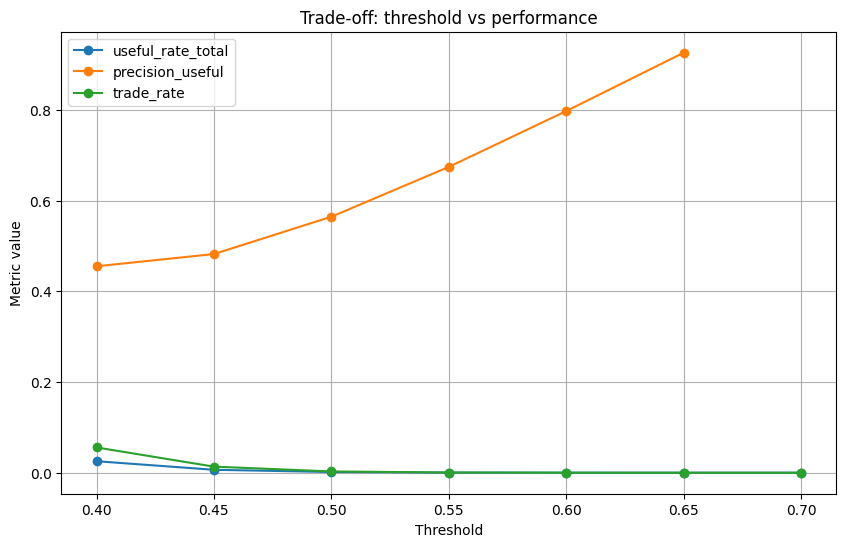

In [71]:
import matplotlib.pyplot as plt

df_plot = df_threshold_eval_global.sort_values("threshold_long")

x = df_plot["threshold_long"]

plt.figure(figsize=(10, 6))

plt.plot(x, df_plot["useful_rate_total"], marker="o", label="useful_rate_total")
plt.plot(x, df_plot["precision_useful"], marker="o", label="precision_useful")
plt.plot(x, df_plot["trade_rate"], marker="o", label="trade_rate")

plt.xlabel("Threshold")
plt.ylabel("Metric value")
plt.title("Trade-off: threshold vs performance")
plt.legend()
plt.grid(True)

plt.show()

### **Observaciones del gráfico**


El gráfico muestra de forma clara el trade-off entre cantidad de operaciones y calidad de señal al variar el threshold de decisión.

---

**1. Comportamiento general del sistema**

Se observa que:

- `trade_rate` disminuye de forma muy pronunciada a medida que aumenta el threshold  
- `precision_useful` crece de manera monotónica  
- `useful_rate_total` alcanza un máximo en valores bajos de threshold  

Este comportamiento confirma que la lógica basada en probabilidades está funcionando correctamente.

---

**2. Máximo de desempeño en thresholds bajos**

El mayor valor de `useful_rate_total` se alcanza en:

- threshold ≈ 0.40  

A partir de ese punto:

- la métrica cae de forma sostenida  

Esto indica que:

- el aumento en precisión no compensa la pérdida de volumen de operaciones  

---

**3. Rango operativo relevante**

El intervalo entre **0.40 y 0.50** concentra el mejor equilibrio entre:

- cantidad de trades  
- calidad de las señales  

Dentro de este rango:

- el sistema sigue siendo activo  
- la precisión mejora progresivamente  
- el impacto total se mantiene razonable  

---

**4. Pérdida de operatividad en thresholds altos**

Para valores de threshold superiores a ~0.55:

- `trade_rate` se aproxima a cero  
- el sistema prácticamente deja de operar  

Aunque la precisión sea elevada en estos casos:

- el volumen es demasiado bajo para ser útil  

---

**5. Interpretación del comportamiento del modelo**

El modelo es capaz de asignar alta probabilidad a señales correctas, pero:

- estos casos de alta convicción son poco frecuentes  

Esto explica por qué:

- aumentar el threshold reduce drásticamente la cantidad de operaciones  

---

**Conclusión**

El gráfico indica que:

- el mejor punto operativo se encuentra cerca de threshold ≈ 0.40  
- el rango útil se sitúa aproximadamente entre 0.40 y 0.45  
- valores superiores reducen excesivamente la actividad del sistema  

En consecuencia, el modelo requiere operar en un régimen de baja exigencia para mantener un nivel adecuado de señal.

## **Análisis de estabilidad de la señal en el rango óptimo de thresholds**

Habiendo identificado que el rango de thresholds entre 0.40 y 0.45 ofrece el mejor equilibrio entre cantidad de operaciones y calidad de señal, el siguiente paso consiste en evaluar la estabilidad de este comportamiento.

El objetivo es verificar si la señal generada es consistente en el tiempo y no depende de un subconjunto reducido de días o condiciones específicas del mercado.

Para ello, se analizará el desempeño del modelo a nivel temporal, evaluando métricas clave por día y, opcionalmente, por régimen de mercado.

In [72]:
import numpy as np
import pandas as pd


# ============================================================
# 1. Función: aplicar nueva regla de decisión probabilística
# ============================================================
def apply_probability_decision_rule(
    df_pred: pd.DataFrame,
    threshold_long: float,
    threshold_short: float | None = None,
) -> pd.DataFrame:
    """
    Aplica una regla de decisión basada en probabilidades.

    Regla:
    - si proba_1 >= threshold_long  -> señal long (+1)
    - si proba_-1 >= threshold_short -> señal short (-1)
    - en otro caso -> no trade (0)

    Si ambas probabilidades superan el umbral al mismo tiempo,
    se elige la clase con mayor probabilidad.

    Parámetros
    ----------
    df_pred : pd.DataFrame
        DataFrame con columnas:
        - y_true
        - proba_-1
        - proba_0
        - proba_1
        - date
        - target
        - window_size
    threshold_long : float
        Umbral mínimo para generar señal long.
    threshold_short : float | None
        Umbral mínimo para generar señal short.
        Si es None, se usa el mismo valor de threshold_long.

    Retorna
    -------
    pd.DataFrame
        DataFrame con nuevas columnas de decisión.
    """

    if threshold_short is None:
        threshold_short = threshold_long

    df = df_pred.copy()

    # --------------------------------------------------------
    # Máscaras lógicas para detectar señales long y short
    # --------------------------------------------------------
    long_mask = df["proba_1"] >= threshold_long
    short_mask = df["proba_-1"] >= threshold_short

    # --------------------------------------------------------
    # Inicialmente, todas las decisiones son 0 = no trade
    # --------------------------------------------------------
    y_decision = np.zeros(len(df), dtype=int)

    # --------------------------------------------------------
    # Casos exclusivos:
    # solo long o solo short
    # --------------------------------------------------------
    y_decision[long_mask & ~short_mask] = 1
    y_decision[short_mask & ~long_mask] = -1

    # --------------------------------------------------------
    # Caso ambiguo:
    # ambas probabilidades superan umbral
    # se elige la de mayor valor
    # --------------------------------------------------------
    both_mask = long_mask & short_mask
    y_decision[both_mask] = np.where(
        df.loc[both_mask, "proba_1"].values >= df.loc[both_mask, "proba_-1"].values,
        1,
        -1,
    )

    df["y_decision"] = y_decision

    # --------------------------------------------------------
    # Confidence de la decisión:
    # - si decidió long, usar proba_1
    # - si decidió short, usar proba_-1
    # - si no opera, dejar NaN
    # --------------------------------------------------------
    df["decision_confidence"] = np.where(
        df["y_decision"] == 1,
        df["proba_1"],
        np.where(
            df["y_decision"] == -1,
            df["proba_-1"],
            np.nan
        )
    )

    # --------------------------------------------------------
    # Variables operativas derivadas
    # --------------------------------------------------------
    df["is_trade"] = df["y_decision"] != 0
    df["is_correct"] = df["y_decision"] == df["y_true"]
    df["is_useful_signal"] = df["is_trade"] & df["is_correct"]

    return df


# ============================================================
# 2. Función: resumen por día
# ============================================================
def summarize_daily_performance(
    df_decision: pd.DataFrame,
    *,
    date_col: str = "date",
) -> pd.DataFrame:
    """
    Resume el desempeño diario de la regla de decisión.

    Métricas calculadas por día:
    - n_total
    - n_trades
    - n_useful
    - trade_rate
    - useful_rate_total
    - precision_useful
    - distribución de señales short / flat / long

    Parámetros
    ----------
    df_decision : pd.DataFrame
        DataFrame ya procesado con apply_probability_decision_rule().
    date_col : str
        Nombre de la columna de fecha.

    Retorna
    -------
    pd.DataFrame
        Resumen diario.
    """

    def _daily_metrics(g: pd.DataFrame) -> pd.Series:
        n_total = len(g)
        n_trades = int(g["is_trade"].sum())
        n_useful = int(g["is_useful_signal"].sum())

        n_short = int((g["y_decision"] == -1).sum())
        n_flat = int((g["y_decision"] == 0).sum())
        n_long = int((g["y_decision"] == 1).sum())

        trade_rate = n_trades / n_total if n_total > 0 else np.nan
        useful_rate_total = n_useful / n_total if n_total > 0 else np.nan
        precision_useful = n_useful / n_trades if n_trades > 0 else np.nan

        return pd.Series({
            "n_total": n_total,
            "n_trades": n_trades,
            "n_useful": n_useful,
            "trade_rate": trade_rate,
            "useful_rate_total": useful_rate_total,
            "precision_useful": precision_useful,
            "n_short": n_short,
            "n_flat": n_flat,
            "n_long": n_long,
            "pct_short": n_short / n_total if n_total > 0 else np.nan,
            "pct_flat": n_flat / n_total if n_total > 0 else np.nan,
            "pct_long": n_long / n_total if n_total > 0 else np.nan,
        })

    df_daily = (
        df_decision
        .groupby(date_col, dropna=False)
        .apply(_daily_metrics)
        .reset_index()
        .sort_values(date_col)
        .reset_index(drop=True)
    )

    return df_daily


# ============================================================
# 3. Función opcional: resumen por día y por configuración
# ============================================================
def summarize_daily_performance_by_config(
    df_decision: pd.DataFrame,
    *,
    group_cols: list[str] | None = None,
    date_col: str = "date",
) -> pd.DataFrame:
    """
    Resume el desempeño diario, separado por configuración.

    Por defecto agrupa por:
    - target
    - window_size
    - date

    Esto permite analizar estabilidad temporal para cada setup.

    Parámetros
    ----------
    df_decision : pd.DataFrame
        DataFrame ya procesado con decisiones.
    group_cols : list[str] | None
        Columnas adicionales de agrupación.
    date_col : str
        Columna temporal.

    Retorna
    -------
    pd.DataFrame
        Resumen diario por configuración.
    """

    if group_cols is None:
        group_cols = ["target", "window_size"]

    full_group_cols = group_cols + [date_col]

    def _metrics(g: pd.DataFrame) -> pd.Series:
        n_total = len(g)
        n_trades = int(g["is_trade"].sum())
        n_useful = int(g["is_useful_signal"].sum())

        n_short = int((g["y_decision"] == -1).sum())
        n_flat = int((g["y_decision"] == 0).sum())
        n_long = int((g["y_decision"] == 1).sum())

        trade_rate = n_trades / n_total if n_total > 0 else np.nan
        useful_rate_total = n_useful / n_total if n_total > 0 else np.nan
        precision_useful = n_useful / n_trades if n_trades > 0 else np.nan

        return pd.Series({
            "n_total": n_total,
            "n_trades": n_trades,
            "n_useful": n_useful,
            "trade_rate": trade_rate,
            "useful_rate_total": useful_rate_total,
            "precision_useful": precision_useful,
            "n_short": n_short,
            "n_flat": n_flat,
            "n_long": n_long,
        })

    df_daily_cfg = (
        df_decision
        .groupby(full_group_cols, dropna=False)
        .apply(_metrics)
        .reset_index()
        .sort_values(full_group_cols)
        .reset_index(drop=True)
    )

    return df_daily_cfg


# ============================================================
# 4. EJECUCIÓN PRINCIPAL
# ============================================================

# ------------------------------------------------------------
# Elegir threshold dentro del rango identificado como útil
# Puedes probar 0.40 y luego comparar con 0.45
# ------------------------------------------------------------
THRESHOLD = 0.40

# ------------------------------------------------------------
# Aplicar nueva regla de decisión probabilística
# sobre todo el dataset de predicciones
# ------------------------------------------------------------
df_decision_thr = apply_probability_decision_rule(
    df_pred=df_pred_all,
    threshold_long=THRESHOLD,
    threshold_short=THRESHOLD,
)

# ------------------------------------------------------------
# Resumen global por día
# Sirve para evaluar estabilidad temporal total del sistema
# ------------------------------------------------------------
df_daily_global = summarize_daily_performance(
    df_decision=df_decision_thr,
    date_col="date",
)

# ------------------------------------------------------------
# Resumen por día y por configuración
# Sirve para ver qué target + window_size es más estable
# ------------------------------------------------------------
df_daily_by_config = summarize_daily_performance_by_config(
    df_decision=df_decision_thr,
    group_cols=["target", "window_size"],
    date_col="date",
)

# ============================================================
# 5. RESULTADOS BÁSICOS
# ============================================================

print("=" * 100)
print(f"RESUMEN DIARIO GLOBAL | threshold = {THRESHOLD}")
print("=" * 100)
print(df_daily_global.head(10))
print()

print("=" * 100)
print(f"RESUMEN DIARIO POR CONFIGURACIÓN | threshold = {THRESHOLD}")
print("=" * 100)
print(df_daily_by_config.head(10))
print()


# ============================================================
# 6. ESTADÍSTICAS DE ESTABILIDAD
# ============================================================

# ------------------------------------------------------------
# Estas estadísticas ayudan a responder:
# - qué tan variable es el sistema día a día
# - si depende de pocos días buenos
# - si la señal es consistente o errática
# ------------------------------------------------------------
stability_summary = pd.DataFrame({
    "metric": [
        "trade_rate_mean",
        "trade_rate_std",
        "useful_rate_total_mean",
        "useful_rate_total_std",
        "precision_useful_mean",
        "precision_useful_std",
        "days_with_trades",
        "days_without_trades",
    ],
    "value": [
        df_daily_global["trade_rate"].mean(),
        df_daily_global["trade_rate"].std(),
        df_daily_global["useful_rate_total"].mean(),
        df_daily_global["useful_rate_total"].std(),
        df_daily_global["precision_useful"].mean(),
        df_daily_global["precision_useful"].std(),
        int((df_daily_global["n_trades"] > 0).sum()),
        int((df_daily_global["n_trades"] == 0).sum()),
    ]
})

print("=" * 100)
print(f"ESTABILIDAD GLOBAL | threshold = {THRESHOLD}")
print("=" * 100)
print(stability_summary)
print()


# ============================================================
# 7. DÍAS EXTREMOS
# ============================================================

# ------------------------------------------------------------
# Mejores días según useful_rate_total
# ------------------------------------------------------------
best_days = (
    df_daily_global
    .sort_values("useful_rate_total", ascending=False)
    .head(10)
)

# ------------------------------------------------------------
# Peores días según useful_rate_total
# ------------------------------------------------------------
worst_days = (
    df_daily_global
    .sort_values("useful_rate_total", ascending=True)
    .head(10)
)

print("=" * 100)
print("TOP 10 MEJORES DÍAS | useful_rate_total")
print("=" * 100)
print(best_days)
print()

print("=" * 100)
print("TOP 10 PEORES DÍAS | useful_rate_total")
print("=" * 100)
print(worst_days)
print()


# ============================================================
# 8. RESUMEN POR CONFIGURACIÓN
# ============================================================

# ------------------------------------------------------------
# Ahora resumimos la estabilidad de cada target + window_size
# ------------------------------------------------------------
df_config_stability = (
    df_daily_by_config
    .groupby(["target", "window_size"], dropna=False)
    .agg(
        trade_rate_mean=("trade_rate", "mean"),
        trade_rate_std=("trade_rate", "std"),
        useful_rate_mean=("useful_rate_total", "mean"),
        useful_rate_std=("useful_rate_total", "std"),
        precision_useful_mean=("precision_useful", "mean"),
        precision_useful_std=("precision_useful", "std"),
        n_days=("date", "count"),
        days_with_trades=("n_trades", lambda s: int((s > 0).sum())),
    )
    .reset_index()
    .sort_values(
        ["useful_rate_mean", "precision_useful_mean"],
        ascending=[False, False]
    )
    .reset_index(drop=True)
)

print("=" * 100)
print(f"ESTABILIDAD POR CONFIGURACIÓN | threshold = {THRESHOLD}")
print("=" * 100)
print(df_config_stability.head(20))

RESUMEN DIARIO GLOBAL | threshold = 0.4
        date  n_total  n_trades  n_useful  trade_rate  useful_rate_total  \
0 2024-05-14  18432.0      61.0      58.0    0.003309           0.003147   
1 2024-05-15  18432.0     471.0     227.0    0.025553           0.012316   
2 2024-05-16  18432.0       0.0       0.0    0.000000           0.000000   
3 2024-05-17  18432.0       0.0       0.0    0.000000           0.000000   
4 2024-05-20  18432.0       5.0       1.0    0.000271           0.000054   
5 2024-05-21  18432.0       5.0       5.0    0.000271           0.000271   
6 2024-05-22  18432.0       2.0       0.0    0.000109           0.000000   
7 2024-05-23  18432.0      17.0       0.0    0.000922           0.000000   
8 2024-05-24  18432.0      31.0      28.0    0.001682           0.001519   
9 2024-05-28  18432.0       4.0       0.0    0.000217           0.000000   

   precision_useful  n_short   n_flat  n_long  pct_short  pct_flat  pct_long  
0          0.950820      0.0  18371.0    61.

### **Observaciones sobre la estabilidad temporal de la señal (threshold = 0.40)**


**Observaciones sobre la estabilidad temporal de la señal (threshold = 0.40)**

El análisis diario permite evaluar si la señal detectada por el modelo es consistente en el tiempo o si depende de eventos aislados.

---

**1. Alta variabilidad en la actividad diaria**

Se observa una gran dispersión en:

- `trade_rate_std ≈ 0.12`
- `useful_rate_total_std ≈ 0.058`

Esto indica que:

- hay días con mucha actividad  
- y días con actividad prácticamente nula  

El comportamiento no es homogéneo.

---

**2. Existencia de días sin operaciones**

- `days_without_trades = 9`

Además, en varios días:

- `n_trades = 0`
- `useful_rate_total = 0`

Esto implica que:

- el modelo no siempre encuentra oportunidades  
- la señal no está presente de forma continua  

---

**3. Dependencia fuerte de pocos días muy buenos**

En los mejores días:

- `trade_rate` extremadamente alto (hasta ~95%)
- `useful_rate_total` muy elevado (hasta ~0.51)

Ejemplo:
- más de 9,000 señales útiles en un solo día

Esto muestra que:

- gran parte del desempeño global proviene de pocos días excepcionales  

---

**4. Presencia de muchos días sin señal útil**

En los peores días:

- `n_useful = 0`
- incluso con algunos trades  

Esto implica:

- existen múltiples jornadas donde el modelo no aporta valor  

---

**5. Inestabilidad en la precisión**

- `precision_useful_std ≈ 0.29`

Se observan días con:

- precisión cercana a 1.0  
- y otros con precisión 0  

Esto indica que:

- la calidad de la señal varía significativamente día a día  

---

**6. Consistencia parcial en la operatividad**

- `days_with_trades = 213` sobre 222 días  

Esto sugiere que:

- el modelo es mayormente activo  
- pero la calidad de esa actividad no es consistente  

---

**7. Diferencias claras entre configuraciones**

En el análisis por configuración:

- p40 domina en:
  - `useful_rate_mean`
  - `trade_rate_mean`
- p50 y superiores muestran:
  - menor actividad  
  - menor señal útil  

Además:

- alta desviación estándar en todas las configuraciones  
→ indica inestabilidad general del sistema  

---

**8. Insight clave**

El modelo sí captura señal, pero:

- esta señal es altamente dependiente del contexto temporal  
- no se distribuye de forma uniforme en el tiempo  

---

**Conclusión**

El sistema presenta:

- capacidad de generar señales de alta calidad  
- pero de forma inconsistente  

Esto implica que:

- el desempeño global está impulsado por pocos días muy favorables  
- mientras que una proporción importante de días aporta poco o ningún valor  

En consecuencia, la robustez temporal de la señal es limitada y requiere un análisis adicional para identificar en qué condiciones el modelo funciona mejor.

## **Análisis de explotabilidad del target T2 por régimen de mercado**

Antes de concluir sobre la explotabilidad del target T2, es necesario analizar si la señal detectada se distribuye de forma homogénea o si se concentra en determinados regímenes de mercado.

Dado que el comportamiento del mercado intradía no es uniforme, es posible que el target sea explotable únicamente bajo ciertas condiciones específicas (por ejemplo: apertura, premarket, etc.).

Por lo tanto, en este paso se evaluará el desempeño del target segmentado por régimen, con el objetivo de identificar en qué contextos el modelo logra generar señales útiles de forma consistente.

Para poder analizar el target por régimen de mercado, primero es necesario incorporar la columna `regime_id` al dataset de decisiones.

Dado que `df_decision_thr` no contiene esa información, pero `df_t2_grid_ind` sí la tiene, la forma correcta de resolverlo es unir ambos datasets usando las claves temporales comunes:

- `date`
- `minute_of_day`

De esta manera, cada predicción queda asociada al régimen de mercado correspondiente, permitiendo luego calcular métricas de explotabilidad segmentadas por régimen.

In [76]:
import pandas as pd


# ============================================================
# 1. Preparar tabla auxiliar con información temporal + régimen
# ============================================================
df_regime_map = (
    df_t2_grid_ind[["date", "minute_of_day", "regime_id"]]
    .copy()
)

# Asegurar tipos consistentes
df_regime_map["date"] = pd.to_datetime(df_regime_map["date"])
df_decision_thr["date"] = pd.to_datetime(df_decision_thr["date"])

# Eliminar duplicados por seguridad
df_regime_map = df_regime_map.drop_duplicates(
    subset=["date", "minute_of_day"]
).copy()


# ============================================================
# 2. Merge para agregar regime_id a las decisiones
# ============================================================
df_decision_thr_regime = df_decision_thr.merge(
    df_regime_map,
    on=["date", "minute_of_day"],
    how="left",
    validate="many_to_one",
)

print(df_decision_thr_regime[["date", "minute_of_day", "regime_id"]].head())
print(df_decision_thr_regime["regime_id"].isna().sum())

        date  minute_of_day  regime_id
0 2024-05-14            359          0
1 2024-05-14            360          0
2 2024-05-14            361          0
3 2024-05-14            362          0
4 2024-05-14            363          0
0


In [78]:
import numpy as np
import pandas as pd


def summarize_by_regime(df_decision: pd.DataFrame) -> pd.DataFrame:

    def _metrics(g: pd.DataFrame) -> pd.Series:
        n_total = len(g)
        n_trades = int(g["is_trade"].sum())
        n_useful = int(g["is_useful_signal"].sum())

        trade_rate = n_trades / n_total if n_total > 0 else np.nan
        useful_rate_total = n_useful / n_total if n_total > 0 else np.nan
        precision_useful = n_useful / n_trades if n_trades > 0 else np.nan

        return pd.Series({
            "n_total": n_total,
            "n_trades": n_trades,
            "n_useful": n_useful,
            "trade_rate": trade_rate,
            "useful_rate_total": useful_rate_total,
            "precision_useful": precision_useful,
        })

    df_regime = (
        df_decision
        .groupby("regime_id", dropna=False)
        .apply(_metrics)
        .reset_index()
        .sort_values("useful_rate_total", ascending=False)
        .reset_index(drop=True)
    )

    return df_regime


df_regime_summary = summarize_by_regime(df_decision_thr_regime)
print(df_regime_summary)

   regime_id    n_total  n_trades  n_useful  trade_rate  useful_rate_total  \
0          2   479520.0   81675.0   38051.0    0.170327           0.079352   
1          1   479520.0   41865.0   19849.0    0.087306           0.041393   
2          4     2664.0     134.0      59.0    0.050300           0.022147   
3          3  2163168.0   94671.0   41982.0    0.043765           0.019408   
4          0   967032.0    9701.0    3851.0    0.010032           0.003982   

   precision_useful  
0          0.465883  
1          0.474119  
2          0.440299  
3          0.443452  
4          0.396969  


**Observaciones sobre la explotabilidad del target T2 por régimen de mercado**

El análisis segmentado por régimen muestra que la señal del target T2 no se distribuye de forma uniforme, sino que presenta una fuerte dependencia del contexto de mercado.

---

**1. Alta concentración de señal en el régimen de apertura (regime_id = 2)**

El régimen de apertura presenta:

- mayor `trade_rate` (~17%)
- mayor `useful_rate_total` (~7.9%)
- alta cantidad de señales útiles (~38k)

Esto indica que:

- la mayor parte de la señal explotable se genera durante la apertura  
- el target T2 es especialmente sensible a este régimen  

---

**2. Buen desempeño en premarket (regime_id = 1)**

El premarket muestra:

- `useful_rate_total` ~4.1%  
- `precision_useful` ~47%  

Aunque inferior a apertura:

- sigue siendo un régimen con señal relevante  
- aporta una fracción importante del total  

---

**3. Desempeño moderado en sesión regular (regime_id = 3)**

En el régimen regular:

- `useful_rate_total` ~1.9%  
- `trade_rate` más bajo (~4.3%)  

Esto sugiere que:

- la señal existe, pero es más débil  
- el mercado es menos predecible en este tramo  

---

**4. Baja señal en overnight (regime_id = 0)**

El régimen overnight presenta:

- `useful_rate_total` muy bajo (~0.4%)  
- menor `precision_useful` (~39%)  

Esto indica que:

- el target T2 es poco explotable en este régimen  
- la señal es prácticamente marginal  

---

**5. Régimen de cierre con baja representatividad (regime_id = 4)**

El régimen de cierre muestra:

- resultados moderados  
- pero con muy bajo volumen de datos  

Por lo tanto:

- no es concluyente  
- su impacto en el total es limitado  

---

**6. Estabilidad relativa de la precisión**

Se observa que:

- `precision_useful` se mantiene relativamente estable (~44%–47%)  
- excepto en overnight, donde disminuye  

Esto indica que:

- la calidad relativa de las señales no cambia drásticamente  
- pero la frecuencia de oportunidades sí  

---

**Insight clave**

El target T2 no es globalmente explotable de manera uniforme.

Su capacidad de generar señales útiles está fuertemente concentrada en:

- apertura (principalmente)  
- premarket (secundariamente)  

---

**Conclusión**

El target T2 es **condicionalmente explotable**:

- altamente explotable en apertura  
- moderadamente explotable en premarket  
- débil en sesión regular  
- prácticamente no explotable en overnight  

Esto confirma que la señal depende del régimen de mercado y no es homogénea en el tiempo.

## **Filtrar regímenes explotables (regime_id = 1 y 2)**

In [79]:
# ============================================================
# 1. Filtrar solo regímenes explotables
# ============================================================

df_decision_filtered = df_decision_thr_regime[
    df_decision_thr_regime["regime_id"].isin([1, 2])
].copy()

print(f"Filas originales: {len(df_decision_thr_regime)}")
print(f"Filas filtradas : {len(df_decision_filtered)}")
print()


# ============================================================
# 2. Recalcular métricas globales
# ============================================================

def summarize_global(df):

    n_total = len(df)
    n_trades = int(df["is_trade"].sum())
    n_useful = int(df["is_useful_signal"].sum())

    trade_rate = n_trades / n_total if n_total > 0 else np.nan
    useful_rate_total = n_useful / n_total if n_total > 0 else np.nan
    precision_useful = n_useful / n_trades if n_trades > 0 else np.nan

    return pd.DataFrame([{
        "n_total": n_total,
        "n_trades": n_trades,
        "n_useful": n_useful,
        "trade_rate": trade_rate,
        "useful_rate_total": useful_rate_total,
        "precision_useful": precision_useful,
    }])


df_summary_filtered = summarize_global(df_decision_filtered)

print("=" * 100)
print("RESUMEN GLOBAL (SOLO REGIMES 1 Y 2)")
print("=" * 100)
print(df_summary_filtered)
print()


# ============================================================
# 3. Resumen por régimen (solo para validar distribución)
# ============================================================

df_regime_filtered = summarize_by_regime(df_decision_filtered)

print("=" * 100)
print("RESUMEN POR REGIME (FILTRADO)")
print("=" * 100)
print(df_regime_filtered)
print()


# ============================================================
# 4. (Opcional) Resumen por día
# ============================================================

df_daily_filtered = summarize_daily_performance(df_decision_filtered)

print("=" * 100)
print("RESUMEN DIARIO (FILTRADO)")
print("=" * 100)
print(df_daily_filtered.head(10))
print()


# ============================================================
# 5. Comparación directa (ANTES vs DESPUÉS)
# ============================================================

df_summary_original = summarize_global(df_decision_thr_regime)

comparison = pd.concat([
    df_summary_original.assign(dataset="original"),
    df_summary_filtered.assign(dataset="filtered_regime_1_2")
])

print("=" * 100)
print("COMPARACIÓN")
print("=" * 100)
print(comparison)

Filas originales: 4091904
Filas filtradas : 959040

RESUMEN GLOBAL (SOLO REGIMES 1 Y 2)
   n_total  n_trades  n_useful  trade_rate  useful_rate_total  \
0   959040    123540     57900    0.128816           0.060373   

   precision_useful  
0          0.468674  

RESUMEN POR REGIME (FILTRADO)
   regime_id   n_total  n_trades  n_useful  trade_rate  useful_rate_total  \
0          2  479520.0   81675.0   38051.0    0.170327           0.079352   
1          1  479520.0   41865.0   19849.0    0.087306           0.041393   

   precision_useful  
0          0.465883  
1          0.474119  

RESUMEN DIARIO (FILTRADO)
        date  n_total  n_trades  n_useful  trade_rate  useful_rate_total  \
0 2024-05-14   4320.0      57.0      54.0    0.013194           0.012500   
1 2024-05-15   4320.0     471.0     227.0    0.109028           0.052546   
2 2024-05-16   4320.0       0.0       0.0    0.000000           0.000000   
3 2024-05-17   4320.0       0.0       0.0    0.000000           0.000000   
4

### **Observaciones tras filtrar regímenes explotables (regime_id = 1 y 2)**



El filtrado por regímenes de mercado produce una mejora clara y consistente en todas las métricas relevantes, lo que confirma que la señal del target T2 está altamente concentrada en estos contextos.

---

**1. Mejora significativa en la explotabilidad global**

Comparando antes vs después:

- `useful_rate_total`:  
  - 0.025 → 0.060  
  → más del doble  

- `trade_rate`:  
  - 0.055 → 0.128  
  → incremento fuerte en actividad  

- `precision_useful`:  
  - 0.455 → 0.468  
  → mejora leve pero consistente  

Esto indica que:

- se elimina una gran cantidad de ruido  
- se concentra la señal útil  

---

**2. Alta eficiencia en régimen de apertura**

El régimen 2 (opening) presenta:

- `useful_rate_total` ~0.079  
- `trade_rate` ~0.17  

Esto implica:

- alta densidad de oportunidades  
- principal fuente de señal explotable  

---

**3. Contribución relevante del premarket**

El régimen 1 muestra:

- `useful_rate_total` ~0.041  
- `precision_useful` ligeramente superior al opening  

Esto sugiere que:

- el premarket complementa la señal  
- aporta estabilidad adicional  

---

**4. Reducción efectiva del ruido**

Al eliminar otros regímenes:

- se reduce el volumen total (~4M → ~1M filas)  
- pero se mantiene más del 50% de señales útiles  

Esto confirma que:

- gran parte del dataset original no aportaba valor  

---

**5. Persistencia de variabilidad diaria**

A nivel diario:

- siguen existiendo días sin operaciones  
- y días con alta señal  

Esto indica que:

- la señal sigue siendo dependiente del contexto  
- pero ahora está mejor concentrada  

---

**6. Insight clave**

El target T2 no es uniformemente explotable, pero:

- sí es fuertemente explotable bajo condiciones específicas  

En particular:

- apertura  
- premarket  

---

**Conclusión final del stage**

El target T2 es **explotable bajo condiciones de mercado específicas**.

En términos prácticos:

- no debe utilizarse de forma global  
- debe restringirse a los regímenes:
  - premarket (1)
  - opening (2)

Bajo estas condiciones:

- la densidad de señal aumenta significativamente  
- la operatividad mejora de forma clara  
- el sistema se vuelve viable como generador de señales de trading

### **Medición de robustez en regimes 1 y 2**

Queremos validar:

- Estabilidad diaria
- Dependencia de pocos días extremos
- Consistencia del edge

In [80]:
import numpy as np
import pandas as pd


# ============================================================
# 1. YA TIENES ESTO (df_daily_filtered)
# ============================================================

df_daily = df_daily_filtered.copy()


# ============================================================
# 2. ESTADÍSTICAS DE ESTABILIDAD
# ============================================================

stability = pd.DataFrame({
    "metric": [
        "trade_rate_mean",
        "trade_rate_std",
        "useful_rate_mean",
        "useful_rate_std",
        "precision_mean",
        "precision_std",
        "coef_var_useful_rate",
    ],
    "value": [
        df_daily["trade_rate"].mean(),
        df_daily["trade_rate"].std(),
        df_daily["useful_rate_total"].mean(),
        df_daily["useful_rate_total"].std(),
        df_daily["precision_useful"].mean(),
        df_daily["precision_useful"].std(),
        df_daily["useful_rate_total"].std() / df_daily["useful_rate_total"].mean()
    ]
})

print("="*80)
print("ESTABILIDAD")
print("="*80)
print(stability)


# ============================================================
# 3. ¿DEPENDE DE POCOS DÍAS?
# ============================================================

# Ordenar por desempeño
df_sorted = df_daily.sort_values("useful_rate_total", ascending=False)

# Top 10% de días
top_10pct = int(len(df_sorted) * 0.1)

df_top = df_sorted.head(top_10pct)

# Contribución de esos días
total_useful = df_daily["n_useful"].sum()
top_useful = df_top["n_useful"].sum()

concentration = top_useful / total_useful

print("\n" + "="*80)
print("CONCENTRACIÓN DE SEÑAL")
print("="*80)
print(f"Top 10% días explican: {concentration:.2%} de señales útiles")


# ============================================================
# 4. CONSISTENCIA: % DE DÍAS CON SEÑAL
# ============================================================

days_with_signal = (df_daily["n_useful"] > 0).mean()
days_with_trades = (df_daily["n_trades"] > 0).mean()

print("\n" + "="*80)
print("CONSISTENCIA")
print("="*80)
print(f"Días con trades : {days_with_trades:.2%}")
print(f"Días con señal  : {days_with_signal:.2%}")


# ============================================================
# 5. DISTRIBUCIÓN (para ver estabilidad visualmente)
# ============================================================

print("\n" + "="*80)
print("DISTRIBUCIÓN useful_rate_total")
print("="*80)

print(df_daily["useful_rate_total"].describe())


# ============================================================
# 6. CUANTILES (muy importante)
# ============================================================

quantiles = df_daily["useful_rate_total"].quantile([0.1, 0.25, 0.5, 0.75, 0.9])

print("\n" + "="*80)
print("CUANTILES useful_rate_total")
print("="*80)
print(quantiles)

ESTABILIDAD
                 metric     value
0       trade_rate_mean  0.128816
1        trade_rate_std  0.180064
2      useful_rate_mean  0.060373
3       useful_rate_std  0.100270
4        precision_mean  0.455429
5         precision_std  0.326099
6  coef_var_useful_rate  1.660840

CONCENTRACIÓN DE SEÑAL
Top 10% días explican: 49.87% de señales útiles

CONSISTENCIA
Días con trades : 95.05%
Días con señal  : 87.84%

DISTRIBUCIÓN useful_rate_total
count    222.000000
mean       0.060373
std        0.100270
min        0.000000
25%        0.002373
50%        0.021759
75%        0.068866
max        0.619213
Name: useful_rate_total, dtype: float64

CUANTILES useful_rate_total
0.10    0.000000
0.25    0.002373
0.50    0.021759
0.75    0.068866
0.90    0.163843
Name: useful_rate_total, dtype: float64


**Evaluación de robustez del target T2 en regímenes 1 y 2**

El análisis de estabilidad temporal permite evaluar si la señal detectada es consistente o si depende de condiciones específicas.

---

**1. Alta variabilidad en la señal**

- `coef_var_useful_rate ≈ 1.66`
- `useful_rate_std > useful_rate_mean`

Esto indica que:

- la señal presenta alta dispersión  
- existen días con muy buen desempeño y otros con desempeño cercano a cero  

---

**2. Dependencia moderada de días favorables**

- El top 10% de días explica ~50% de las señales útiles  

Esto implica que:

- una fracción importante del desempeño proviene de días particularmente buenos  
- pero no es un caso extremo de dependencia total  

---

**3. Buena consistencia operativa**

- Días con trades: ~95%  
- Días con señal útil: ~88%  

Esto indica que:

- el sistema es activo de forma sostenida  
- la señal está presente en la mayoría de los días  

---

**4. Distribución de la señal**

- Mediana (`p50`) ≈ 0.022  
- `p25` cercano a cero (~0.002)  
- `p75` ≈ 0.069  
- Máximo ≈ 0.62  

Esto muestra que:

- la mayoría de los días tienen señal baja a moderada  
- existen outliers con señal muy alta  
- la distribución es asimétrica  

---

**5. Interpretación general**

El target T2 en regímenes 1 y 2 presenta:

- señal frecuente  
- pero con intensidad variable  

Esto implica que:

- no es completamente estable  
- pero tampoco es esporádico  

---

**Conclusión final**

El target T2 es **explotable bajo los regímenes de premarket y apertura**, con las siguientes características:

- genera señal de forma consistente en el tiempo  
- presenta variabilidad significativa en su desempeño  
- depende parcialmente de días favorables, pero no de forma extrema  

En consecuencia, el target puede considerarse **operativamente viable**, siempre que:

- se restrinja a los regímenes identificados  
- se gestione adecuadamente la variabilidad del desempeño  

Esto valida el uso del target T2 como base para etapas posteriores de modelado.

In [84]:
print(df_daily_filtered["date"].min())
print(df_daily_filtered["date"].max())

2024-05-14 00:00:00
2025-05-06 00:00:00


In [81]:
# ============================================================
# 1. Agregar columna año
# ============================================================

df_daily = df_daily_filtered.copy()

df_daily["year"] = pd.to_datetime(df_daily["date"]).dt.year


# ============================================================
# 2. Métricas por año
# ============================================================

df_yearly = (
    df_daily
    .groupby("year")
    .agg(
        n_days=("date", "count"),
        trade_rate_mean=("trade_rate", "mean"),
        useful_rate_mean=("useful_rate_total", "mean"),
        useful_rate_std=("useful_rate_total", "std"),
        precision_mean=("precision_useful", "mean"),
        precision_std=("precision_useful", "std"),
        days_with_signal=("n_useful", lambda s: (s > 0).mean()),
    )
    .reset_index()
    .sort_values("year")
)

print("="*80)
print("MÉTRICAS POR AÑO")
print("="*80)
print(df_yearly)

MÉTRICAS POR AÑO
   year  n_days  trade_rate_mean  useful_rate_mean  useful_rate_std  \
0  2024     148         0.069699          0.036249         0.075357   
1  2025      74         0.247050          0.108621         0.124348   

   precision_mean  precision_std  days_with_signal  
0        0.446783       0.343272          0.831081  
1        0.471436       0.293227          0.972973  


In [82]:
# ============================================================
# 3. Concentración por año
# ============================================================

def concentration_by_year(df):

    results = []

    for year, g in df.groupby("year"):

        g_sorted = g.sort_values("useful_rate_total", ascending=False)

        top_n = int(len(g_sorted) * 0.1)
        g_top = g_sorted.head(top_n)

        total_useful = g["n_useful"].sum()
        top_useful = g_top["n_useful"].sum()

        concentration = top_useful / total_useful if total_useful > 0 else np.nan

        results.append({
            "year": year,
            "concentration_top10": concentration
        })

    return pd.DataFrame(results)


df_concentration_year = concentration_by_year(df_daily)

print("="*80)
print("CONCENTRACIÓN POR AÑO")
print("="*80)
print(df_concentration_year)

CONCENTRACIÓN POR AÑO
   year  concentration_top10
0  2024             0.553115
1  2025             0.362228


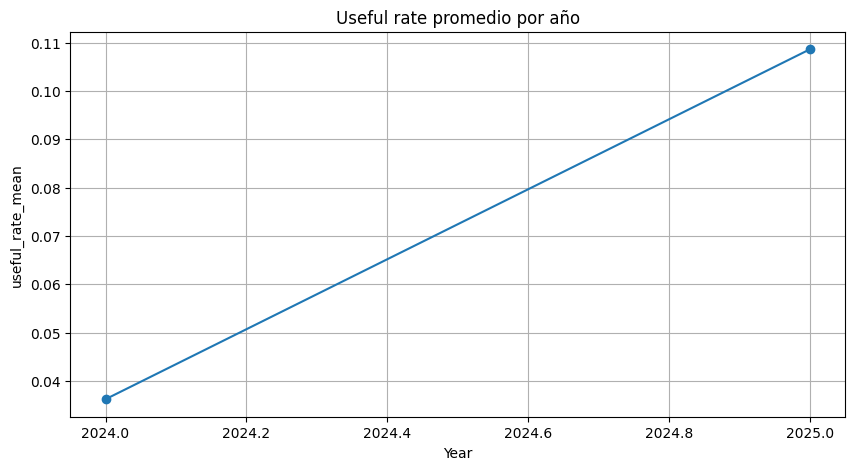

In [83]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(df_yearly["year"], df_yearly["useful_rate_mean"], marker="o")
plt.title("Useful rate promedio por año")
plt.xlabel("Year")
plt.ylabel("useful_rate_mean")
plt.grid(True)

plt.show()

# **FULL**

In [89]:
import time
import numpy as np
import pandas as pd

from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score


# ============================================================
# 1. Función general: entrena con train y predice sobre el split indicado
# ============================================================
def run_xgb_one_target_one_eval_split(
    *,
    target_col: str,
    window_size: int,
    eval_split_name: str,   # "train", "valid" o "test"
    df_train_f: pd.DataFrame,
    df_valid_f: pd.DataFrame,
    df_test_f: pd.DataFrame,
    train_bundles: dict,
    valid_bundles: dict,
    test_bundles: dict,
    confidence_threshold: float = 0.50,
    use_gpu: bool = True,
    xgb_params_base: dict | None = None,
    verbose: bool = False,
):
    """
    Entrena XGBoost usando TRAIN y evalúa sobre el split indicado:
    - train
    - valid
    - test

    Devuelve:
    - df_pred_eval
    - metrics_row
    """

    if xgb_params_base is None:
        xgb_params_base = {
            "n_estimators": 200,
            "max_depth": 3,
            "learning_rate": 0.03,
            "subsample": 0.8,
            "colsample_bytree": 0.8,
            "reg_lambda": 10.0,
            "reg_alpha": 0.0,
            "min_child_weight": 1,
            "gamma": 0.0,
            "objective": "multi:softprob",
            "num_class": 3,
            "eval_metric": "mlogloss",
            "tree_method": "hist",
            "random_state": 42,
            "n_jobs": -1,
        }

    xgb_params = xgb_params_base.copy()
    xgb_params["device"] = "cuda" if use_gpu else "cpu"

    # ============================================================
    # 1) Extraer TRAIN (siempre se entrena con train)
    # ============================================================
    train_xy = extract_xy_from_bundle(
        df_train_f,
        train_bundles[window_size],
        target_col=target_col,
        verbose=False,
    )

    X_train = train_xy["X"]
    y_train_raw = train_xy["y"]

    # ============================================================
    # 2) Elegir split de evaluación
    # ============================================================
    if eval_split_name == "train":
        eval_df = df_train_f
        eval_bundles = train_bundles
    elif eval_split_name == "valid":
        eval_df = df_valid_f
        eval_bundles = valid_bundles
    elif eval_split_name == "test":
        eval_df = df_test_f
        eval_bundles = test_bundles
    else:
        raise ValueError(f"Split no válido: {eval_split_name}")

    eval_xy = extract_xy_from_bundle(
        eval_df,
        eval_bundles[window_size],
        target_col=target_col,
        verbose=False,
    )

    X_eval = eval_xy["X"]
    y_eval_raw = eval_xy["y"]

    # ============================================================
    # 3) Mapear clases {-1, 0, 1} -> {0, 1, 2}
    # ============================================================
    class_to_int = {-1: 0, 0: 1, 1: 2}
    int_to_class = {0: -1, 1: 0, 2: 1}

    y_train = np.vectorize(class_to_int.get)(y_train_raw)
    y_eval = np.vectorize(class_to_int.get)(y_eval_raw)

    # ============================================================
    # 4) Entrenamiento
    # ============================================================
    model = XGBClassifier(**xgb_params)
    model.fit(X_train, y_train)

    # ============================================================
    # 5) Predicción
    # ============================================================
    y_pred_int = model.predict(X_eval)
    y_proba = model.predict_proba(X_eval)

    y_pred = np.vectorize(int_to_class.get)(y_pred_int)
    y_true = y_eval_raw.copy()
    confidence = y_proba.max(axis=1)

    # ============================================================
    # 6) Baseline naive
    # ============================================================
    majority_class_int = pd.Series(y_eval).value_counts().idxmax()
    y_naive_int = np.full_like(y_eval, fill_value=majority_class_int)

    balanced_accuracy_naive = balanced_accuracy_score(y_eval, y_naive_int)

    # ============================================================
    # 7) Métricas
    # ============================================================
    balanced_accuracy = balanced_accuracy_score(y_eval, y_pred_int)
    f1_macro = f1_score(y_eval, y_pred_int, average="macro")
    f1_weighted = f1_score(y_eval, y_pred_int, average="weighted")
    accuracy = accuracy_score(y_eval, y_pred_int)

    bal_acc_gain_vs_naive = balanced_accuracy - balanced_accuracy_naive

    # ============================================================
    # 8) Dataset fila a fila
    # ============================================================
    df_pred_eval = pd.DataFrame({
        "split": eval_split_name,
        "date": eval_xy["date"],
        "minute_of_day": eval_xy["minute_of_day"],
        "target": target_col,
        "window_size": window_size,
        "y_true": y_true,
        "y_pred": y_pred,
        "confidence": confidence,
        "proba_-1": y_proba[:, 0],
        "proba_0": y_proba[:, 1],
        "proba_1": y_proba[:, 2],
    })

    df_pred_eval["is_trade"] = df_pred_eval["y_pred"] != 0
    df_pred_eval["is_correct"] = df_pred_eval["y_pred"] == df_pred_eval["y_true"]
    df_pred_eval["is_confident"] = df_pred_eval["confidence"] >= confidence_threshold
    df_pred_eval["is_useful_signal"] = (
        df_pred_eval["is_trade"]
        & df_pred_eval["is_correct"]
        & df_pred_eval["is_confident"]
    )

    # ============================================================
    # 9) Operatividad básica
    # ============================================================
    trade_rate = df_pred_eval["is_trade"].mean()
    n_trades = int(df_pred_eval["is_trade"].sum())

    n_useful = int(df_pred_eval["is_useful_signal"].sum())
    useful_rate_total = df_pred_eval["is_useful_signal"].mean()

    pred_dist = pd.Series(y_pred).value_counts(normalize=True).to_dict()

    # ============================================================
    # 10) Resumen
    # ============================================================
    metrics_row = {
        "split": eval_split_name,
        "target": target_col,
        "window_size": window_size,
        "device": xgb_params["device"],
        "n_train": len(y_train),
        "n_eval": len(y_eval),
        "balanced_accuracy": balanced_accuracy,
        "f1_macro": f1_macro,
        "f1_weighted": f1_weighted,
        "accuracy": accuracy,
        "balanced_accuracy_naive": balanced_accuracy_naive,
        "bal_acc_gain_vs_naive": bal_acc_gain_vs_naive,
        "trade_rate": trade_rate,
        "n_trades": n_trades,
        "n_useful": n_useful,
        "useful_rate_total": useful_rate_total,
        "pred_pct_-1": pred_dist.get(-1, 0.0),
        "pred_pct_0": pred_dist.get(0, 0.0),
        "pred_pct_1": pred_dist.get(1, 0.0),
    }

    if verbose:
        print("=" * 100)
        print(f"XGBOOST | split={eval_split_name} | target={target_col} | L={window_size}")
        print(pd.DataFrame([metrics_row]).round(6))

    return df_pred_eval, metrics_row

In [ ]:
import time
import pandas as pd

targets = [
    "t2_p40_h30", "t2_p40_h60", "t2_p40_h90",
    "t2_p50_h30", "t2_p50_h60", "t2_p50_h90",
    "t2_p55_h30", "t2_p55_h60", "t2_p55_h90",
    "t2_p60_h30", "t2_p60_h60", "t2_p60_h90",
]

window_sizes = [30, 60, 90]
eval_splits = ["train", "valid", "test"]

all_preds_full = []
all_metrics_full = []
errors_full = []

total_runs = len(targets) * len(window_sizes) * len(eval_splits)
run_id = 0

t_global_start = time.time()

print("=" * 100)
print(f"INICIO LOOP XGBOOST FULL | total runs = {total_runs}")
print("=" * 100)

for split_name in eval_splits:
    for L in window_sizes:
        for target in targets:

            run_id += 1
            t0 = time.time()

            print(f"[{run_id}/{total_runs}] split={split_name} | target={target} | L={L} ...", end=" ")

            try:
                df_pred_one, metrics_one = run_xgb_one_target_one_eval_split(
                    target_col=target,
                    window_size=L,
                    eval_split_name=split_name,
                    df_train_f=df_train,
                    df_valid_f=df_valid,
                    df_test_f=df_test,
                    train_bundles=train_bundles,
                    valid_bundles=valid_bundles,
                    test_bundles=test_bundles,
                    confidence_threshold=0.50,
                    use_gpu=True,
                    verbose=False,
                )

                elapsed = time.time() - t0
                metrics_one["elapsed_sec"] = elapsed

                all_preds_full.append(df_pred_one)
                all_metrics_full.append(metrics_one)

                print(f"OK ({elapsed:.1f}s)")

            except Exception as e:
                print(f"ERROR: {e}")
                errors_full.append({
                    "split": split_name,
                    "target": target,
                    "window_size": L,
                    "error": str(e),
                })

t_total = time.time() - t_global_start

print("=" * 100)
print(f"FIN LOOP FULL | tiempo total = {t_total/60:.2f} min")
print(f"Errores: {len(errors_full)}")
print("=" * 100)

# ============================================================
# Construcción final
# ============================================================
df_pred_all_full = pd.concat(all_preds_full, ignore_index=True)
df_metrics_all_full = pd.DataFrame(all_metrics_full)
df_errors_full = pd.DataFrame(errors_full) if errors_full else pd.DataFrame()

print("\nResumen final:")
print(f"df_pred_all_full   : {df_pred_all_full.shape}")
print(f"df_metrics_all_full: {df_metrics_all_full.shape}")
print(f"df_errors_full     : {df_errors_full.shape}")

INICIO LOOP XGBOOST FULL | total runs = 108
[1/108] split=train | target=t2_p40_h30 | L=30 ... OK (18.6s)
[2/108] split=train | target=t2_p40_h60 | L=30 ... OK (17.6s)
[3/108] split=train | target=t2_p40_h90 | L=30 ... 